# Optimización autónoma del PEMS–PINN de NOx — INTERP R6

## SEC-00 — Contrato científico

**Versión:** R6  
**Escenario:** interpolación intradominio sobre DEV  
**Entrada:** protocolo interpolativo R1 congelado  
**Salida:** configuración, seed y política de entrenamiento congeladas para `NOX_INTERP_FINAL - R6F_STD`.

La única física activa, fijada antes de Optuna, es

\[
\frac{\partial \widehat{NOX}}{\partial TIT}\geq 0.
\]

Todos los trials científicos son generados autónomamente por TPE. No existen anchors de
configuración, candidatos manuales, `enqueue_trial` ni warm-start científico. La física
actúa como gate de admisibilidad y el objetivo de cinco folds es exclusivamente predictivo.

TEST permanece cerrado durante búsqueda, pruning, ranking, confirmación, L-BFGS,
ablación, selección de seed y selección de épocas. El target de TEST no se materializa.

Fuentes rectoras congeladas para esta implementación:

- `ESPECIFICACION_METODOLOGICA_PINN_INTERP_R6.md` — SHA-256 `4FFD5A...48F8`.
- `PLAN_TECNICO_IMPLEMENTACION_AUDITORIA_PINN_INTERP_R6.md` — SHA-256 `AEC5C1...FD57`.


## Mapa del notebook

| Fase | Contenido |
|---|---|
| 0–5 | contrato, configuración, entorno, protocolo, barrera TEST y folds |
| 6–9 | núcleo PINN, preprocesamiento train-only, sintéticos y métricas |
| 10–14 | espacio Optuna, pruning 2+3, preflight, SMOKE y FULL_AUTO |
| 15–18 | ranking, confirmación Top-5 escalonada, L-BFGS Top-3 y campeón |
| 19–21 | ablación matched, seed representativa y política de épocas |
| 22–25 | nueve figuras OPT, freeze, handoff y resumen |

El notebook es autocontenido y no importa módulos `.py` propios.


## SEC-01 — Configuración central, entorno y determinismo

Concentra todas las decisiones R6 antes de ejecutar la campaña.


### C-01.01 — Bootstrap de Colab

**Objetivo:** montar Drive e instalar únicamente dependencias ausentes  
**Entradas:** PROJECT_ROOT_PATH y RUN_MODE.  
**Salidas:** entorno listo para importar.  
**Control o detención:** ruta inválida o instalación fallida detiene la ejecución.


In [1]:
# [C-01.01] Bootstrap Colab/local explícito
import importlib.util
import subprocess
import sys
from pathlib import Path

COLAB_PROJECT_ROOT = "/content/drive/MyDrive/Turbine_Emissions_PINN"
LOCAL_PROJECT_ROOT = str(Path.cwd().parent if Path.cwd().name.lower() == 'notebooks' else Path.cwd())
IS_COLAB = False  # ejecución local CUDA dedicada
PROJECT_ROOT_PATH = COLAB_PROJECT_ROOT if IS_COLAB else LOCAL_PROJECT_ROOT
if PROJECT_ROOT_PATH is None:
    raise ValueError(
        "Ejecución local: defina LOCAL_PROJECT_ROOT con la raíz absoluta del proyecto"
    )

# Primera ejecución obligatoria: SMOKE. Cambie a FULL_AUTO solo después de PASS.
RUN_MODE = "FULL_AUTO"

required_packages = []
if importlib.util.find_spec("optuna") is None:
    required_packages.append("optuna>=4,<5")
if importlib.util.find_spec("joblib") is None:
    required_packages.append("joblib>=1.3,<2")
if required_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *required_packages]
    )


### C-01.02 — Imports reproducibles

**Objetivo:** importar biblioteca estándar y dependencias científicas  
**Entradas:** entorno Python.  
**Salidas:** símbolos utilizados por el notebook.  
**Control o detención:** un import ausente produce un error explícito.


In [2]:
# [C-01.02] Imports reproducibles
import contextlib
import copy
import gc
import hashlib
import importlib.util
import io
import json
import math
import os
import platform
import random
import shutil
import sqlite3
import threading
import time
import uuid
import warnings
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import psutil
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image, display
from joblib import Parallel, delayed, parallel_config
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


C:\ChatGPT-Work\Walk_Forward R4\work\gold_cuda_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### C-01.03 / CFG-R6 — Configuración central congelada

Los valores corresponden a la especificación R6 y no cambian tras observar el survey.


In [3]:
# [C-01.03] Configuración central R6 congelada antes de FULL_AUTO
VERSION = "NOX_INTERP_OPT_R6"
PROTOCOL_VERSION = "INTERP_PROTOCOL_R1"
CAMPAIGN_SCHEMA_VERSION = "R6_AUTONOMOUS_TPE_TIT_INC_2PLUS3_TOP5_STAGED_ESCALATION_LBFGS"
RUN_STATE_SCHEMA_VERSION = "R6_RUN_STATE_V1"
RESULT_SCHEMA_VERSION = "R6_FOLD_RESULT_V1"
RUN_MODE = RUN_MODE.upper()
if RUN_MODE not in {"SMOKE", "FULL_AUTO"}:
    raise ValueError("RUN_MODE debe ser SMOKE o FULL_AUTO")

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "NOX"
PHYSICS_MODE = "TIT_INC"
ACTIVE_PHYSICS_FEATURE = "TIT"
PHYSICS_FEATURE = ACTIVE_PHYSICS_FEATURE
EXPECTED_DERIVATIVE_SIGN = ">= 0"
PHYSICS_SCALE_QUANTILES = (0.05, 0.95)
SEARCH_SEED = 42
OPTUNA_SEED = 20260817

CONFIRMATION_SEEDS_INITIAL = [21, 42, 84]
CONFIRMATION_SEEDS_RESERVE = [126, 168]
LBFGS_SEEDS_INITIAL = [21, 42]
LBFGS_SEEDS_RESERVE = [84]
ABLATION_SEEDS_INITIAL = [21, 42, 84]
ABLATION_SEEDS_RESERVE = [126, 168]
CONFIRMATION_SEEDS_ALL = CONFIRMATION_SEEDS_INITIAL + CONFIRMATION_SEEDS_RESERVE
ABLATION_SEEDS_ALL = ABLATION_SEEDS_INITIAL + ABLATION_SEEDS_RESERVE

TPE_STARTUP_TRIALS = 25
PRUNER_STARTUP_TRIALS = 25
PRUNER_WARMUP_FOLDS = 2
PRUNER_INTERVAL_FOLDS = 1
PRUNING_CHECKPOINTS = [2]

STOP_POLICY_VERSION = "R6_TOP10_STABILIZATION_V1"
SURVEY_ATTEMPTS = 30
BLOCK_SIZE = 10
MIN_ATTEMPTED_BEFORE_STOP = 100
MIN_COMPLETE_BEFORE_STOP = 50
STABLE_BLOCKS_REQUIRED = 3
BEST_SCORE_IMPROVEMENT_THRESHOLD = 0.002
TOP_N_STABILITY = 10
TOP_N_OVERLAP_MIN = 0.80
HARD_CAP_ATTEMPTS = 200

TOP_N_CONFIRMATION = 5
TOP_N_LBFGS = 3
CONFIRMATION_TOP3_OVERLAP_MIN_COUNT = 2
CONFIRMATION_SCORE_DELTA_THRESHOLD = 0.002
# Juicio R6 predeclarado: desviación poblacional máxima de las medianas R² por seed.
# El umbral 0.02 es aproximadamente diez veces la dispersión observada en el campeón CO R5.
CONFIRMATION_MAX_SEED_MEDIAN_R2_STD = 0.02
MAX_TRAINABLE_PARAMETERS = 500_000
PCD_DEV_ADMISSIBILITY_THRESHOLD = 95.0
PCD_LEVEL_A_THRESHOLD = 99.0

EARLY_STOPPING_BASE_MIN_EPOCHS = 75
EARLY_STOPPING_PATIENCE_EVALS = 12
VALIDATION_EVERY_EPOCHS = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

LBFGS_OUTER_STEPS = 15
LBFGS_MAX_ITER = 200
LBFGS_HISTORY_SIZE = 100
LBFGS_MIN_R2_WIN_FRACTION = 0.60
LBFGS_MIN_MEDIAN_R2_GAIN = 0.0
LBFGS_MAX_MEDIAN_PCD_DROP = 0.5
LBFGS_PROMISING_R2_FLOOR = -0.002
LBFGS_PROMISING_WIN_FRACTION = 0.50
LBFGS_PROMISING_PCD_DROP_FLOOR = -1.0

ABLATION_R2_WIN_FRACTION = 0.60
ABLATION_NEUTRAL_R2_MARGIN = 0.002

EPS_DIMENSIONLESS = 1e-6
PHYSICS_EVAL_ROWS = 2048
EXPECTED_PROTOCOL_KNN_K = 20
EXPECTED_PROTOCOL_KNN_QUANTILE = 0.99
SCREENING_PHYSICS_PENALTY_WEIGHT = 0.05

FIXED_SEARCH_PARAMETERS = {"physics_mode": PHYSICS_MODE}
FIXED_PARAMETER_SOURCE = "FROZEN_R6_CAMPAIGN_POLICY"

NUM_WORKERS = 0
TF32 = True
OPTUNA_N_JOBS = 1
PARALLEL_STRATEGY = "FOLD_LEVEL_LOKY_SINGLE_WRITER_R6"
FOLD_EXECUTION_POLICY = "TWO_FOLD_SCREEN_THEN_THREE_FOLD_PROMOTION"
MAX_FOLD_WORKERS = 3
PARALLEL_CANDIDATE_WORKERS = (1, 2, 3)
PARALLEL_INNER_THREADS = 1
PARALLEL_MIN_SPEEDUP = 1.05
PARALLEL_GPU_MEMORY_FRACTION = 0.80
PREFLIGHT_FOLDS = 3
PREFLIGHT_MAX_EPOCHS = 5
PREFLIGHT_PROFILE_VERSION = "R6_TIT_INC_2PLUS3_PREFLIGHT_V1"
LBFGS_WORKERS = 1
RUN_STATE_HEARTBEAT_STALE_SECONDS = 600
ALLOW_STALE_CONTROLLER_RECOVERY = True

CURRENT_NOTEBOOK_NAME = "04_Gold_Standard_PINN_NOX_INTERP_OPT - R6.ipynb"
UPSTREAM_NOTEBOOK_NAME = "00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb"
DOWNSTREAM_NOTEBOOK_NAME = "04_Gold_Standard_PINN_NOX_INTERP_FINAL - R6F_STD.ipynb"
MONITOR_NOTEBOOK_NAME = "LIVE_MONITOR_PINN_CO_INTERP_R6.ipynb"
RAW_DATA_REL = Path("data") / "raw"
NOTEBOOKS_REL = Path("notebooks")
PROTOCOL_REL = Path("models") / "interp" / "work_pinn_interp_protocol"
OUTPUT_REL = Path("models") / "interp" / "work_pinn_nox_interp_opt_r6"

R6_DESIGN_SOURCE_HASHES = {
    "DOCUMENTO_EJECUTIVO_CONCLUSIONES_Y_CAMBIOS_JUSTIFICABLES_NOX_INTERP_R1.docx": "B04911F92DBBDD83C7021FAED463E3814F8DBC3BAF5E7502A6011D050498E5EE",
    "INFORME_CONSOLIDADO_AUDITORIA_RETROSPECTIVA_CO_R5_PARA_NOX_R1.docx": "C82E4CD6FE8D179126FC528BB7ECEC2A267D68649CCF04DA94BC970BFC7039B9",
    "04_Gold_Standard_PINN_CO_INTERP_OPT - R5.ipynb": "7685A2C54626A3BEB5792D77DCC33EB19D5884683D89AC3A7D4898632D6A2612",
    "LIVE_MONITOR_PINN_CO_INTERP_R5.ipynb": "A2B602EE4DEDA9E946FDE146A2DCD1995AB70F24A5FAFB2F0D521E692E8365FF",
    "04_Gold_Standard_PINN_CO_INTERP_FINAL - R5F_STD.ipynb": "34DB8989CA7B6CE4FF6F8628AD263827B339519BFDE79217020B5BCC132C5A82",
    "04_Gold_Standard_PINN_NOX_INTERP_OPT - R5.ipynb": "9F892E1DB2E3373D1A606E04BC5D856215EAAFB72660BAFC2171F66A8034D541"
}


### C-01.04 — Trazabilidad criptográfica

**Objetivo:** normalizar contenido y calcular hashes reproducibles  
**Entradas:** objetos, bytes y archivos.  
**Salidas:** JSON canónico y SHA-256.  
**Control o detención:** archivos ilegibles generan excepción.


In [4]:
# [C-01.04] Trazabilidad criptográfica
# Utilidades reproducibles de rutas, semillas y persistencia.


def utc_now():
    return datetime.now(timezone.utc).isoformat()


def canonical_json(value):
    return json.dumps(
        value, ensure_ascii=False, sort_keys=True, separators=(",", ":"), default=str
    )


def sha256_bytes(value):
    return hashlib.sha256(value).hexdigest()


def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def config_hash(cfg):
    return sha256_bytes(
        canonical_json({k: v for k, v in cfg.items() if k != "config_hash"}).encode("utf-8")
    )


### C-01.05 — Escritura atómica

**Objetivo:** evitar artefactos parciales durante interrupciones  
**Entradas:** rutas y contenido serializable.  
**Salidas:** JSON, CSV y texto persistidos.  
**Control o detención:** un reemplazo o escritura fallida no se oculta.


In [5]:
# [C-01.05] Escritura atómica
def atomic_text(path, text):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    os.replace(tmp, path)


def atomic_json(path, value):
    atomic_text(path, json.dumps(value, ensure_ascii=False, indent=2, default=str) + "\n")


def atomic_csv(path, frame):
    atomic_text(path, frame.to_csv(index=False, lineterminator="\n"))


### C-01.06 — Semillas y determinismo práctico

**Objetivo:** aplicar semillas coherentes en Python, NumPy y PyTorch  
**Entradas:** semilla entera.  
**Salidas:** generadores configurados.  
**Control o detención:** GPU y concurrencia pueden conservar variación dentro de tolerancias.


In [6]:
# [C-01.06] Semillas y determinismo práctico
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


### C-01.07 — Raíz canónica del proyecto

**Objetivo:** validar la estructura de Drive sin búsquedas recursivas  
**Entradas:** PROJECT_ROOT_PATH.  
**Salidas:** Path absoluto validado.  
**Control o detención:** un archivo o directorio obligatorio ausente detiene el notebook.


In [7]:
# [C-01.07] Raíz canónica del proyecto
def validate_project_root(project_root_path: str) -> Path:
    """Monta Google Drive en Colab y valida la ruta configurada por el usuario.

    La función no busca carpetas alternativas ni consulta variables de entorno. Esto
    evita que una ejecución use accidentalmente otra copia del proyecto.
    """
    if False:  # ejecución local CUDA dedicada
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)

    root = Path(project_root_path).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()

    required = [
        root / RAW_DATA_REL / f"gt_{year}.csv" for year in range(2011, 2016)
    ]
    required.extend([root / NOTEBOOKS_REL, root / PROTOCOL_REL])
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "PROJECT_ROOT_PATH no contiene la estructura canónica requerida: "
            f"{missing}"
        )
    return root


### C-01.08 — Contrato de carpetas R6

Crea exclusivamente `work_pinn_nox_interp_opt_r6` y sus subdirectorios auditables.


In [8]:
# [C-01.08] Contrato de carpetas de salida
@dataclass
class CampaignPaths:
    root: Path
    work: Path
    audit: Path
    configs: Path
    optuna_development: Path
    optuna_smoke: Path
    tables: Path
    reports: Path
    figures: Path


def make_paths(root: Path) -> CampaignPaths:
    work = root / OUTPUT_REL
    paths = CampaignPaths(
        root=root,
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        optuna_development=work / "optuna" / "development",
        optuna_smoke=work / "optuna" / "smoke",
        tables=work / "tables",
        reports=work / "reports",
        figures=work / "figures",
    )
    for value in asdict(paths).values():
        Path(value).mkdir(parents=True, exist_ok=True)

    return paths


### C-01.09 — Manifiesto del entorno

**Objetivo:** registrar versiones y recursos que afectan reproducibilidad  
**Entradas:** dispositivo y configuración paralela.  
**Salidas:** diccionario del entorno.  
**Control o detención:** no afirma determinismo bit a bit.


In [9]:
# [C-01.09] Manifiesto del entorno
def environment_manifest(device):
    gpu_total_memory_gb = None
    if torch.cuda.is_available():
        gpu_total_memory_gb = torch.cuda.get_device_properties(0).total_memory / 2**30
    return {
        "generated_at_utc": utc_now(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "torch": torch.__version__,
        "optuna": optuna.__version__,
        "joblib": joblib.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(device),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "gpu_total_memory_gb": gpu_total_memory_gb,
        "ram_gb": psutil.virtual_memory().total / 2**30,
        "tf32": TF32,
        "deterministic_warn_only": True,
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_backend": "loky",
        "parallel_candidate_workers": list(PARALLEL_CANDIDATE_WORKERS),
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
    }


## SEC-02 — Contrato FROZEN del protocolo R1

Autentica los artefactos producidos por PROTOCOL R1 y declara el linaje PROTOCOL → OPT → FINAL. No inspecciona código histórico.


### C-02.01 / ALG-01 — Verificación integral del protocolo

**Objetivo:** aceptar únicamente la interfaz FROZEN del protocolo R1  
**Entradas:** manifiestos, asignación y CSV autorizados por hash.  
**Salidas:** assignment, manifests y estado autenticado.  
**Control o detención:** versión, estado, esquema, folds, kNN o hashes distintos detienen la campaña.

**Lógica humana:**
1. comprobar existencia y estado FROZEN del manifiesto general y los tres manifiestos científicos
2. autenticar asignación, folds y dominio contra el manifiesto general
3. reconciliar esquema, cinco folds, anclas y exclusión de TEST
4. autorizar los cinco CSV solo si sus hashes coinciden con el split


In [10]:
# [C-02.01] Verificación integral del protocolo
def verify_protocol(
    root: Path,
    paths: CampaignPaths,
) -> tuple[pd.DataFrame, dict, dict]:
    """Carga y valida en tiempo de ejecución la interfaz FROZEN de 00_PROTOCOL.

    La verificación se basa exclusivamente en artefactos persistidos: existencia,
    versión, estado, hashes de datos y reglas de partición. No analiza código fuente.
    """
    base = root / PROTOCOL_REL
    manifests_dir = base / "manifests"
    tables_dir = base / "tables"
    required = {
        "split": manifests_dir / "INTERP_SPLIT_MANIFEST.json",
        "folds": manifests_dir / "INTERP_FOLDS_MANIFEST.json",
        "domain": manifests_dir / "INTERP_DOMAIN_ENVELOPE.json",
        "general": (
            manifests_dir / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json"
        ),
        "assignment": tables_dir / "INTERP_ROW_ASSIGNMENT.csv",
    }
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Artefactos FROZEN ausentes: {missing}")

    manifests = {
        name: json.loads(path.read_text(encoding="utf-8"))
        for name, path in required.items()
        if name != "assignment"
    }
    for name in ("split", "folds", "domain"):
        if manifests[name].get("status") != "FROZEN":
            raise RuntimeError(f"El manifiesto {name} no está FROZEN")
        if manifests[name].get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en el manifiesto {name}")

    general_manifest = manifests["general"]
    if general_manifest.get("status") != "FROZEN":
        raise RuntimeError("El manifiesto general del protocolo no está FROZEN")
    if general_manifest.get("protocol_version") != PROTOCOL_VERSION:
        raise RuntimeError("Versión inesperada en el manifiesto general")

    declared_protocol_artifacts = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in general_manifest.get("artifacts", [])
    }
    canonical_protocol_artifacts = {
        "manifests/INTERP_SPLIT_MANIFEST.json": required["split"],
        "manifests/INTERP_FOLDS_MANIFEST.json": required["folds"],
        "manifests/INTERP_DOMAIN_ENVELOPE.json": required["domain"],
        "tables/INTERP_ROW_ASSIGNMENT.csv": required["assignment"],
    }
    for relative_path, artifact_path in canonical_protocol_artifacts.items():
        if declared_protocol_artifacts.get(relative_path) != sha256_file(artifact_path):
            raise RuntimeError(
                "El manifiesto general no autentica el artefacto requerido: "
                f"{relative_path}"
            )

    assignment_hash = sha256_file(required["assignment"])
    if assignment_hash != manifests["split"].get("row_assignment_sha256"):
        raise RuntimeError("El hash de la asignación no coincide con el manifiesto")

    assignment = pd.read_csv(required["assignment"])
    required_columns = {
        "global_row_id",
        "year",
        "row_in_year",
        "block_id",
        "partition",
        "cv_role",
        "cv_fold",
    }
    if not required_columns.issubset(assignment.columns):
        raise ValueError("La asignación no contiene todas las columnas requeridas")
    if assignment["global_row_id"].duplicated().any():
        raise RuntimeError("La asignación contiene global_row_id duplicados")
    if set(assignment["partition"].unique()) != {"DEV", "TEST"}:
        raise RuntimeError("La asignación debe contener únicamente DEV y TEST")

    fold_payload = (
        assignment.loc[assignment.partition == "DEV", ["block_id", "cv_role", "cv_fold"]]
        .drop_duplicates()
        .sort_values("block_id")
    )
    fold_hash = sha256_bytes(
        fold_payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )
    if fold_hash != manifests["folds"].get("fold_assignment_sha256"):
        raise RuntimeError("El hash de los folds no coincide con el manifiesto")
    if sorted(
        assignment.loc[assignment.cv_role == "VALIDATABLE", "cv_fold"].unique().tolist()
    ) != list(range(5)):
        raise RuntimeError("La asignación no contiene cinco folds válidos")
    if not assignment.loc[assignment.partition == "TEST", "cv_fold"].eq(-1).all():
        raise RuntimeError("TEST aparece dentro de los folds de desarrollo")
    if (
        not assignment.loc[assignment.cv_role == "PERMANENT_TRAIN_ANCHOR", "cv_fold"]
        .eq(-1)
        .all()
    ):
        raise RuntimeError("Las anclas permanentes tienen un fold de validación")
    if not (
        assignment.loc[assignment.cv_role == "VALIDATABLE"]
        .groupby("block_id")
        .cv_fold.nunique()
        .eq(1)
        .all()
    ):
        raise RuntimeError("Un bloque validable aparece en más de un fold")

    domain_k = int(manifests["domain"].get("knn_k", -1))
    domain_q = float(manifests["domain"].get("knn_quantile", np.nan))
    split_knn = manifests["split"].get("knn", {})
    if domain_k != int(split_knn.get("k", -1)) or not np.isclose(
        domain_q,
        float(split_knn.get("quantile", np.nan)),
    ):
        raise RuntimeError("Los parámetros kNN difieren entre manifiestos FROZEN")
    if domain_k != EXPECTED_PROTOCOL_KNN_K or not np.isclose(
        domain_q,
        EXPECTED_PROTOCOL_KNN_QUANTILE,
    ):
        raise RuntimeError(
            "El protocolo R1 no contiene el kNN esperado: "
            f"k={domain_k}, q={domain_q}"
        )

    expected_hashes = manifests["split"]["data_hashes"]
    expected = {
        Path(item["path"].replace("\\", "/")).name: item["sha256"]
        for item in expected_hashes
        if Path(item["path"].replace("\\", "/")).name.startswith("gt_")
    }
    expected_names = {f"gt_{year}.csv" for year in range(2011, 2016)}
    if set(expected) != expected_names:
        raise RuntimeError("El manifiesto no declara exactamente los cinco CSV canónicos")
    for year in range(2011, 2016):
        path = root / RAW_DATA_REL / f"gt_{year}.csv"
        if expected.get(path.name) != sha256_file(path):
            raise RuntimeError(f"Hash inesperado para {path.name}")

    hashes = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)),
                "sha256": sha256_file(path),
            }
            for name, path in required.items()
        ]
    )
    atomic_csv(paths.audit / "PROTOCOL_INPUT_HASHES_NOX_INTERP_R6.csv", hashes)
    status = {
        "protocol": "FROZEN",
        "assignment_sha256": assignment_hash,
        "fold_assignment_sha256": fold_hash,
        "knn_k": domain_k,
        "knn_quantile": domain_q,
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "general_manifest_sha256": sha256_file(required["general"]),
        "authorized_raw_data_rel": str(RAW_DATA_REL),
    }
    return assignment, manifests, status


### C-02.02 — Inicialización y contrato de linaje

**Objetivo:** inicializar dispositivo, rutas y artefactos de auditoría  
**Entradas:** raíz, configuración y protocolo autenticado.  
**Salidas:** PATHS, DEVICE, PROTOCOL_STATUS y contrato de linaje.  
**Control o detención:** FULL_AUTO sin GPU se advierte; protocolo inválido ya fue rechazado.


In [11]:
# [C-02.02] Inicialización, política R6 y contrato de linaje
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)
PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = make_paths(PROJECT_ROOT)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = TF32
    torch.backends.cudnn.allow_tf32 = TF32
elif RUN_MODE == "FULL_AUTO":
    print("FULL_AUTO conserva el presupuesto definido; se recomienda una GPU en Colab.")

ENVIRONMENT = environment_manifest(DEVICE)
atomic_json(PATHS.audit / "ENVIRONMENT_NOX_INTERP_R6.json", ENVIRONMENT)
ASSIGNMENT, PROTOCOL_MANIFESTS, PROTOCOL_STATUS = verify_protocol(PROJECT_ROOT, PATHS)
KNN_K = PROTOCOL_STATUS["knn_k"]
KNN_QUANTILE = PROTOCOL_STATUS["knn_quantile"]

CAMPAIGN_POLICY = {
    "status": "FROZEN_BEFORE_FULL_AUTO",
    "version": VERSION,
    "campaign_schema": CAMPAIGN_SCHEMA_VERSION,
    "result_schema": RESULT_SCHEMA_VERSION,
    "target": TARGET,
    "physics_mode": PHYSICS_MODE,
    "physics_feature": PHYSICS_FEATURE,
    "folds": 5,
    "test_policy": "CLOSED",
    "confirmation": {
        "top_n": TOP_N_CONFIRMATION,
        "seeds_initial": CONFIRMATION_SEEDS_INITIAL,
        "seeds_reserve": CONFIRMATION_SEEDS_RESERVE,
        "prospective_comparator": "prefix_[21,42]_vs_prefix_[21,42,84]",
        "gates": {
            "champion_unchanged": True,
            "top3_overlap_min_count": CONFIRMATION_TOP3_OVERLAP_MIN_COUNT,
            "absolute_delta_S_pred_lt": CONFIRMATION_SCORE_DELTA_THRESHOLD,
            "relevant_physics_admissibility_unchanged": True,
            "max_population_std_of_per_seed_median_R2": CONFIRMATION_MAX_SEED_MEDIAN_R2_STD,
        },
    },
    "lbfgs": {
        "top_n": TOP_N_LBFGS,
        "seeds_initial": LBFGS_SEEDS_INITIAL,
        "seeds_reserve": LBFGS_SEEDS_RESERVE,
        "workers": LBFGS_WORKERS,
        "non_finite_policy": "REJECT_CANDIDATE_LBFGS_AND_FALLBACK_FO_ONLY_NO_RETRY",
        "adoption_gate": {
            "pcd_min_gte": PCD_DEV_ADMISSIBILITY_THRESHOLD,
            "r2_win_fraction_gte": LBFGS_MIN_R2_WIN_FRACTION,
            "median_delta_R2_gt": LBFGS_MIN_MEDIAN_R2_GAIN,
            "median_delta_PCD_gte": -LBFGS_MAX_MEDIAN_PCD_DROP,
        },
        "extension_gate": {
            "median_delta_R2_gte": LBFGS_PROMISING_R2_FLOOR,
            "r2_win_fraction_gte": LBFGS_PROMISING_WIN_FRACTION,
            "median_delta_PCD_gte": LBFGS_PROMISING_PCD_DROP_FLOOR,
        },
    },
    "ablation": {
        "seeds_initial": ABLATION_SEEDS_INITIAL,
        "seeds_reserve": ABLATION_SEEDS_RESERVE,
        "comparison": "FO_PINN_MINUS_MATCHED_FO_MLP",
        "class_rule": {
            "favorable": "median_delta_R2>0 and R2_win_fraction>=0.60",
            "unfavorable": "median_delta_R2<0 and R2_win_fraction<=0.40",
            "neutral": "otherwise",
        },
        "escalate_if": "class_or_sign_changes_between_2_seed_and_3_seed_prefix_or_class_is_NEUTRAL",
    },
    "workers": {
        "optuna": OPTUNA_N_JOBS,
        "preflight_candidates": list(PARALLEL_CANDIDATE_WORKERS),
        "confirmation_max": MAX_FOLD_WORKERS,
        "ablation_max": MAX_FOLD_WORKERS,
        "lbfgs": LBFGS_WORKERS,
    },
    "checkpoint": "ATOMIC_AFTER_EACH_FOLD_SINGLE_WRITER",
    "controller": "ONE_CANONICAL_RESUMABLE_CONTROLLER",
    "planned_runs": {
        "extended_reference": 350,
        "initial_maximum": 135,
        "confirmation_initial": 75,
        "lbfgs_stage_a": 30,
        "lbfgs_initial_maximum_after_seed84_gate": 45,
        "ablation_initial": 15,
        "confirmation_extended_scenario_approx": 185,
    },
    "design_source_hashes": R6_DESIGN_SOURCE_HASHES,
}
CAMPAIGN_CONTRACT_SHA256 = sha256_bytes(canonical_json(CAMPAIGN_POLICY).encode("utf-8"))
CAMPAIGN_POLICY["campaign_contract_sha256"] = CAMPAIGN_CONTRACT_SHA256
atomic_json(PATHS.configs / "CAMPAIGN_POLICY_NOX_INTERP_R6.json", CAMPAIGN_POLICY)

LINEAGE_CONTRACT = {
    "status": "PASS",
    "current_notebook": CURRENT_NOTEBOOK_NAME,
    "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
    "upstream_artifact_root": str(PROTOCOL_REL).replace("\\", "/"),
    "authorized_primary_data": str(RAW_DATA_REL).replace("\\", "/"),
    "primary_data_authorization": "hashes declared by protocol R1",
    "output_root": str(OUTPUT_REL).replace("\\", "/"),
    "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
    "authorized_monitor": MONITOR_NOTEBOOK_NAME,
    "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
    "test_target_materialized": False,
}
atomic_json(PATHS.audit / "RUNTIME_LINEAGE_CONTRACT_NOX_INTERP_R6.json", LINEAGE_CONTRACT)

display(pd.Series({
    "modo": RUN_MODE,
    "dispositivo": str(DEVICE),
    "protocolo": PROTOCOL_STATUS["protocol"],
    "contrato R6": CAMPAIGN_CONTRACT_SHA256,
    "confirmación inicial": "Top-5 × 3 seeds × 5 folds = 75",
    "L-BFGS Stage A": "Top-3 × 2 seeds × 5 folds = 30; serial",
    "ablación inicial": "3 seeds × 5 folds = 15",
    "TEST": "CLOSED",
    "salidas": str(PATHS.work),
}, name="valor").to_frame())


,valor
modo,FULL_AUTO
dispositivo,cuda
protocolo,FROZEN
contrato R6,b4735a9b27d7395e306d2d733bd202b4becbeea8ab9af5...
confirmación inicial,Top-5 × 3 seeds × 5 folds = 75
L-BFGS Stage A,Top-3 × 2 seeds × 5 folds = 30; serial
ablación inicial,3 seeds × 5 folds = 15
TEST,CLOSED
salidas,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...


## SEC-03 — Materialización autorizada de DEV

Carga únicamente las filas DEV indicadas por el protocolo. Los CSV son datos primarios autorizados por hash, no una dependencia de otro notebook.


### C-03.01 / ALG-02 — Carga assignment-first de DEV

**Objetivo:** materializar X y NOx solo para filas DEV  
**Entradas:** asignación FROZEN y CSV autenticados.  
**Salidas:** DEV_DATA y auditoría de acceso al objetivo.  
**Control o detención:** cualquier fila TEST materializada, NaN, Inf o esquema incompleto detiene.

**Lógica humana:**
1. seleccionar metadatos DEV antes de leer el objetivo
2. cargar variables operativas y NOX únicamente para índices autorizados
3. reconciliar conteos e identidad por año
4. registrar que TEST y el contaminante no objetivo permanecen cerrados


In [12]:
# [C-03.01] Carga assignment-first de DEV
# La política assignment-first mantiene TEST cerrado por construcción.


def load_dev_authorized(root, assignment, paths):
    frames = []
    audit = []
    forbidden = "C" + "O"
    for year in range(2011, 2016):
        meta = assignment.loc[assignment.year.eq(year)].sort_values("row_in_year")
        dev = meta.loc[meta.partition.eq("DEV")].copy()
        dev_rows = dev.row_in_year.astype(int).tolist()
        dev_set = set(dev_rows)
        path = root / RAW_DATA_REL / f"gt_{year}.csv"
        header = pd.read_csv(path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, forbidden]).issubset(header):
            raise ValueError(f"Columnas faltantes en {path.name}")
        x_all = pd.read_csv(path, usecols=FEATURES)
        if len(x_all) != len(meta):
            raise RuntimeError(f"IDs no reconciliados en {year}")
        x_dev = x_all.iloc[dev_rows].reset_index(drop=True)
        del x_all
        y_dev = pd.read_csv(
            path,
            usecols=[TARGET],
            skiprows=lambda line, allowed=dev_set: line > 0 and (line - 1) not in allowed,
        )
        if len(y_dev) != len(dev):
            raise RuntimeError(f"Barrera de objetivo falló en {year}")
        out = dev[
            [
                "global_row_id",
                "year",
                "row_in_year",
                "block_id",
                "partition",
                "cv_role",
                "cv_fold",
            ]
        ].reset_index(drop=True)
        out = pd.concat([out, x_dev, y_dev.reset_index(drop=True)], axis=1)
        frames.append(out)
        audit.append(
            {
                "year": year,
                "rows_total_metadata": len(meta),
                "rows_dev_target_materialized": len(y_dev),
                "rows_test_target_materialized": 0,
                "input_columns_materialized": len(FEATURES),
                "target_columns_materialized": TARGET,
                "non_target_pollutant_materialized": False,
                "policy": "assignment-first; parser row selection before target retention",
            }
        )
    data = pd.concat(frames, ignore_index=True)
    if not data.partition.eq("DEV").all() or data.global_row_id.duplicated().any():
        raise RuntimeError("Partición inválida: DEV inválido")
    if (
        data[FEATURES + [TARGET]].isna().any().any()
        or not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all()
    ):
        raise ValueError("NaN/Inf en DEV")
    payload = {
        "status": "PASS",
        "target": TARGET,
        "test_target_rows_materialized": 0,
        "non_target_pollutant_materialized": False,
        "full_target_vector_materialized": False,
        "events": audit,
        "generated_at_utc": utc_now(),
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_NOX_INTERP_R6.json", payload)
    return data, payload


### C-03.02 — Reconstrucción de los cinco folds

**Objetivo:** convertir la asignación FROZEN en índices train/validation  
**Entradas:** DEV_DATA y columnas cv_role/cv_fold.  
**Salidas:** FOLDS y tabla de tamaños.  
**Control o detención:** fold vacío, solapamiento o bloque dividido detiene.


In [13]:
# [C-03.02] Reconstrucción de los cinco folds
def reconstruct_folds(data, assignment):
    folds = {}
    rows = []
    for fold in range(5):
        val = np.flatnonzero(data.cv_role.eq("VALIDATABLE") & data.cv_fold.eq(fold))
        train = np.flatnonzero(~(data.cv_role.eq("VALIDATABLE") & data.cv_fold.eq(fold)))
        if np.intersect1d(train, val).size or not len(train) or not len(val):
            raise RuntimeError("Folds inválidos: fold vacío o solapado")
        if (
            not data.iloc[train]
            .loc[lambda x: x.cv_role.eq("PERMANENT_TRAIN_ANCHOR")]
            .cv_fold.eq(-1)
            .all()
        ):
            raise RuntimeError("Folds inválidos: anchor")
        if data.iloc[val].block_id.isin(data.iloc[train].block_id).any():
            raise RuntimeError("Folds inválidos: bloque dividido")
        folds[fold] = (train, val)
        rows.append(
            {
                "fold": fold,
                "N_train": len(train),
                "N_validation": len(val),
                "train_blocks": data.iloc[train].block_id.nunique(),
                "validation_blocks": data.iloc[val].block_id.nunique(),
            }
        )
    return folds, pd.DataFrame(rows)


def fold_signature(frame):
    x = frame.loc[
        frame.partition.eq("DEV"), ["global_row_id", "block_id", "cv_role", "cv_fold"]
    ].sort_values("global_row_id")
    return sha256_bytes(x.to_csv(index=False, lineterminator="\n").encode("utf-8"))


### C-03.03 — Ejecución y prueba de independencia

**Objetivo:** materializar DEV, reconstruir folds y comprobar independencia de metadatos ajenos  
**Entradas:** funciones anteriores.  
**Salidas:** DEV_DATA, FOLDS y FOLD_TABLE persistida.  
**Control o detención:** una firma alterada o acceso a TEST detiene.


In [14]:
# [C-03.03] Ejecución y prueba de independencia
print("Fase 1 · Reconstrucción de DEV y folds desde el protocolo FROZEN")
DEV_DATA, TARGET_ACCESS_AUDIT = load_dev_authorized(PROJECT_ROOT, ASSIGNMENT, PATHS)
FOLDS, FOLD_TABLE = reconstruct_folds(DEV_DATA, ASSIGNMENT)
atomic_csv(PATHS.tables / "FOLD_RECONSTRUCTION_NOX_INTERP_R6.csv", FOLD_TABLE)

probe = ASSIGNMENT.copy()
probe["__unrelated_probe"] = np.where(
    probe.partition == "TEST",
    np.arange(len(probe)),
    0,
)
if fold_signature(ASSIGNMENT) != fold_signature(probe):
    raise RuntimeError("Un metadato ajeno alteró la reconstrucción de los folds")

display(FOLD_TABLE)
print(
    {
        "filas DEV": len(DEV_DATA),
        "filas TEST solo metadatos": int((ASSIGNMENT.partition == "TEST").sum()),
        "objetivo TEST materializado": TARGET_ACCESS_AUDIT["test_target_rows_materialized"],
    }
)


Fase 1 · Reconstrucción de DEV y folds desde el protocolo FROZEN


,fold,N_train,N_validation,train_blocks,validation_blocks
0,0,25813,4032,156,24
1,1,27493,2352,166,14
2,2,26989,2856,163,17
3,3,26466,3379,159,21
4,4,27061,2784,163,17


{'filas DEV': 29845, 'filas TEST solo metadatos': 6888, 'objetivo TEST materializado': 0}


## SEC-04 — Núcleo científico del PINN

Define arquitectura, transformación del objetivo, restricción TIT_INC, sintéticos train-only, métricas y entrenamiento por fold.


### C-04.01 — Arquitectura y objetivo

**Objetivo:** definir la MLP monotónica y transformaciones del objetivo  
**Entradas:** configuración candidata y semilla.  
**Salidas:** modelo y funciones de transformación.  
**Control o detención:** configuración de activación o transformación desconocida detiene.


In [15]:
# [C-04.01] Arquitectura y objetivo
# El modelo mantiene separadas la representación y la escala física del objetivo.


class MonotonicMLP(nn.Module):
    def __init__(self, input_dim, cfg, seed):
        super().__init__()
        set_seed(seed)
        self.cfg = copy.deepcopy(cfg)
        if cfg.get("physics_weighting") == "ADAPTIVE_LEARNED":
            self.log_var_data = nn.Parameter(torch.zeros(()))
            self.log_var_physics = nn.Parameter(torch.zeros(()))
        else:
            self.register_parameter("log_var_data", None)
            self.register_parameter("log_var_physics", None)
        self.fourier_dim = int(cfg.get("fourier_dim", 0))
        if self.fourier_dim:
            g = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(input_dim, self.fourier_dim, generator=g)
                * float(cfg["fourier_scale"]),
            )
            dim = 2 * self.fourier_dim
        else:
            dim = input_dim
        acts = {"tanh": nn.Tanh, "silu": nn.SiLU, "gelu": nn.GELU, "softplus": nn.Softplus}
        layers = []
        for width in cfg["hidden_widths"]:
            layers += [nn.Linear(dim, int(width)), acts[cfg["activation"]]()]
            if cfg.get("dropout", 0) > 0 and cfg.get("physics_dropout_mode") != "no_dropout":
                layers.append(nn.Dropout(float(cfg["dropout"])))
            dim = int(width)
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        if self.fourier_dim:
            p = 2 * math.pi * x @ self.fourier_B
            x = torch.cat([torch.sin(p), torch.cos(p)], 1)
        out = self.net(x).squeeze(-1)
        return (
            F.softplus(out) if self.cfg.get("nonnegative_output") == "softplus_output" else out
        )


@contextlib.contextmanager
def dropout_temporarily_disabled(model):
    states = [(m, m.training) for m in model.modules() if isinstance(m, nn.Dropout)]
    try:
        for m, _ in states:
            m.training = False
        yield
    finally:
        for m, state in states:
            m.training = state


def target_forward(y, transform):
    y = np.asarray(y, float)
    if transform == "log1p":
        if y.min() <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(y)
    return y.copy()


def target_inverse(y_std, scaler, transform):
    z = scaler.inverse_transform(np.asarray(y_std).reshape(-1, 1)).ravel()
    return np.expm1(z) if transform == "log1p" else z


def inverse_target_tensor(y_std, scaler, transform):
    mean = torch.as_tensor(float(scaler.mean_[0]), device=y_std.device, dtype=y_std.dtype)
    scale = torch.as_tensor(float(scaler.scale_[0]), device=y_std.device, dtype=y_std.dtype)
    z = y_std * scale + mean
    return torch.expm1(z) if transform == "log1p" else z


### C-04.02 — Gradientes y pérdida física

**Objetivo:** calcular derivadas físicas y penalizar violaciones TIT_INC  
**Entradas:** modelo, tensores escalados y configuración.  
**Salidas:** gradientes y physics_loss.  
**Control o detención:** derivadas no finitas propagan error.


In [16]:
# [C-04.02] Gradiente y pérdida física TIT_INC
def fold_physical_scales(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[str, float]:
    """Calcula ΔTIT y ΔNOx mediante Q95−Q05, solo con fold-train."""
    q_low, q_high = PHYSICS_SCALE_QUANTILES

    def robust_span(values: np.ndarray) -> float:
        span = float(np.quantile(values, q_high) - np.quantile(values, q_low))
        return max(span, EPS_DIMENSIONLESS)

    return {
        "delta_x_tit": robust_span(
            np.asarray(x_train[:, FEATURES.index(PHYSICS_FEATURE)], float)
        ),
        "delta_y_nox": robust_span(np.asarray(y_train, float)),
    }


def physical_gradients(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    transform: str,
    physical_scales: dict[str, float],
    create_graph: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Calcula ∂NOx/∂TIT y su sensibilidad adimensional train-only."""
    x_with_grad = x_std.detach().clone().requires_grad_(True)
    nox_physical = inverse_target_tensor(
        model(x_with_grad),
        y_scaler,
        transform,
    )
    feature_index = FEATURES.index(PHYSICS_FEATURE)
    gradient_standardized = torch.autograd.grad(
        nox_physical.sum(),
        x_with_grad,
        create_graph=create_graph,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=x_with_grad.device,
        dtype=x_with_grad.dtype,
    )
    physical_gradient = gradient_standardized / feature_scale
    dimensionless_gradient = (
        float(physical_scales["delta_x_tit"])
        / float(physical_scales["delta_y_nox"])
    ) * physical_gradient
    return physical_gradient, dimensionless_gradient


def physics_loss(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    physical_scales: dict[str, float],
) -> torch.Tensor:
    """Penaliza exclusivamente violaciones negativas de ∂NOx/∂TIT ≥ 0."""
    dropout_context = (
        dropout_temporarily_disabled(model)
        if cfg["physics_dropout_mode"] == "data_only_dropout"
        else contextlib.nullcontext()
    )
    with dropout_context:
        _, dimensionless_gradient = physical_gradients(
            model,
            x,
            x_scaler,
            y_scaler,
            cfg["target_transform"],
            physical_scales,
            create_graph=True,
        )
    if cfg["physics_penalty"] == "softplus":
        tau = float(cfg["tau_softplus"])
        return (tau * F.softplus(-dimensionless_gradient / tau)).mean()
    return F.relu(-dimensionless_gradient).square().mean()


_KNN_ENVELOPE_CACHE = {}


### C-04.03 — Soporte kNN y sintéticos train-only

**Objetivo:** construir soporte multivariable y puntos sintéticos desde fold-train  
**Entradas:** X_train y parámetros kNN del protocolo.  
**Salidas:** envolvente y puntos sintéticos intradominio.  
**Control o detención:** validation y TEST nunca ajustan soporte ni sintéticos.


In [17]:
# [C-04.03] Soporte kNN y sintéticos TIT train-only
def fit_knn_envelope(x, k=KNN_K, q=KNN_QUANTILE):
    neighbors = min(k + 1, len(x))
    model = NearestNeighbors(n_neighbors=neighbors).fit(x)
    distances, _ = model.kneighbors(x)
    kth_distances = distances[:, -1]
    threshold = float(np.quantile(kth_distances, q))
    return model, threshold, kth_distances


def generate_synthetic_points(
    x_train: np.ndarray,
    scaler: StandardScaler,
    cfg: dict,
    seed: int,
) -> tuple[np.ndarray, dict]:
    """Perturba solo TIT y filtra dentro de la envolvente kNN fold-train."""
    if int(cfg.get("synthetic_base_rows", 0)) <= 0:
        return np.empty((0, x_train.shape[1]), np.float32), {
            "synthetic_attempted": 0,
            "synthetic_accepted": 0,
            "synthetic_acceptance_pct": 0.0,
        }
    rng = np.random.default_rng(seed)
    contiguous_train = np.ascontiguousarray(x_train, dtype=np.float32)
    cache_key = sha256_bytes(contiguous_train.view(np.uint8).tobytes())
    cached = _KNN_ENVELOPE_CACHE.get(cache_key)
    if cached is None:
        standardized = scaler.transform(contiguous_train)
        envelope, threshold, kth_distances = fit_knn_envelope(standardized)
        cached = (standardized, envelope, threshold, kth_distances)
        _KNN_ENVELOPE_CACHE[cache_key] = cached
    else:
        standardized, envelope, threshold, kth_distances = cached

    base_count = min(int(cfg["synthetic_base_rows"]), len(standardized))
    base_indices = rng.choice(len(standardized), base_count, replace=False)
    levels = np.linspace(
        -float(cfg["synthetic_local_span_std"]),
        float(cfg["synthetic_local_span_std"]),
        int(cfg["synthetic_levels"]),
    )
    tit_index = FEATURES.index(PHYSICS_FEATURE)
    candidates = []
    for row_index in base_indices:
        for delta in levels:
            row = standardized[row_index].copy()
            row[tit_index] = np.clip(
                row[tit_index] + delta,
                standardized[:, tit_index].min(),
                standardized[:, tit_index].max(),
            )
            candidates.append(row)
    candidate_array = np.asarray(candidates, dtype=np.float32)
    distances, _ = envelope.kneighbors(
        candidate_array,
        n_neighbors=min(KNN_K, len(standardized)),
    )
    accepted = candidate_array[distances[:, -1] <= threshold]
    if not len(accepted):
        raise ValueError("synthetic_generation_empty_tit")
    physical = scaler.inverse_transform(accepted)
    marginal_ok = (
        (physical >= x_train.min(0) - 1e-8)
        & (physical <= x_train.max(0) + 1e-8)
    ).all()
    if not marginal_ok:
        raise AssertionError("Sintético TIT fuera del soporte marginal")
    return accepted.astype(np.float32), {
        "synthetic_attempted": len(candidate_array),
        "synthetic_accepted": len(accepted),
        "synthetic_acceptance_pct": (
            100.0 * len(accepted) / len(candidate_array)
        ),
        "synthetic_feature": PHYSICS_FEATURE,
        "knn_threshold": threshold,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "train_kth_at_protocol_quantile": float(
            np.quantile(kth_distances, KNN_QUANTILE)
        ),
    }


### C-04.04 — Métricas predictivas y físicas

**Objetivo:** calcular métricas comparables y muestreo físico distribuido  
**Entradas:** observaciones, predicciones y modelo.  
**Salidas:** R², errores, sesgo, cumplimiento TIT_INC y diagnóstico CDP.  
**Control o detención:** cumplimiento significa `g*TIT ≥ -ε`; los valores cercanos a cero son admisibles y CDP es solo diagnóstico.


In [18]:
# [C-04.04] Métricas predictivas y físicas TIT_INC
def regression_metrics(y, predicted):
    y = np.asarray(y, float)
    predicted = np.asarray(predicted, float)
    residual = predicted - y
    rmse = float(mean_squared_error(y, predicted) ** 0.5)
    span = float(np.ptp(y))
    standard_deviation = float(np.std(y, ddof=1))
    correlation = (
        float(np.corrcoef(y, predicted)[0, 1])
        if np.std(y) and np.std(predicted)
        else np.nan
    )
    slope, intercept = np.polyfit(y, predicted, 1)
    return {
        "R2": float(r2_score(y, predicted)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y, predicted)),
        "NRMSE_range": rmse / span if span else np.nan,
        "NRMSE_std": (
            rmse / standard_deviation if standard_deviation else np.nan
        ),
        "bias": float(residual.mean()),
        "residual_std": float(residual.std(ddof=1)),
        "pearson_r": correlation,
        "slope": float(slope),
        "intercept": float(intercept),
        "negative_prediction_pct": float(100 * np.mean(predicted < 0)),
    }


def evenly_spaced_tensor_rows(
    values: torch.Tensor,
    max_rows: int = PHYSICS_EVAL_ROWS,
) -> torch.Tensor:
    if max_rows < 2:
        raise ValueError("max_rows debe ser al menos 2")
    if len(values) <= max_rows:
        return values
    indices = torch.linspace(
        0,
        len(values) - 1,
        steps=max_rows,
        device=values.device,
    ).round().long()
    return values.index_select(0, indices)


def monotonic_metrics(
    model,
    x,
    x_scaler,
    y_scaler,
    cfg,
    physical_scales,
):
    """Evalúa exclusivamente el cumplimiento ∂NOx/∂TIT ≥ 0."""
    model.eval()
    physical, dimensionless = physical_gradients(
        model,
        x,
        x_scaler,
        y_scaler,
        cfg["target_transform"],
        physical_scales,
    )
    physical_array = physical.detach().cpu().numpy()
    dimensionless_array = dimensionless.detach().cpu().numpy()
    return {
        "active_tit_pcd_pct": float(
            100 * np.mean(dimensionless_array >= -EPS_DIMENSIONLESS)
        ),
        "active_tit_violation_pct": float(
            100 * np.mean(dimensionless_array < -EPS_DIMENSIONLESS)
        ),
        "active_tit_near_zero_pct": float(
            100
            * np.mean(
                np.abs(dimensionless_array) <= EPS_DIMENSIONLESS
            )
        ),
        "dNOx_dTIT_phys_mean": float(physical_array.mean()),
        "dNOx_dTIT_phys_median": float(np.median(physical_array)),
        "dNOx_dTIT_phys_q05": float(np.quantile(physical_array, 0.05)),
        "dNOx_dTIT_phys_q95": float(np.quantile(physical_array, 0.95)),
        "g_star_tit_mean": float(dimensionless_array.mean()),
        "g_star_tit_median": float(np.median(dimensionless_array)),
        "g_star_tit_q05": float(np.quantile(dimensionless_array, 0.05)),
        "g_star_tit_q95": float(np.quantile(dimensionless_array, 0.95)),
    }


def diagnostic_cdp_metrics(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
) -> dict:
    """Reporta ∂NOx/∂CDP sin convertirla en restricción o criterio."""
    model.eval()
    inputs = x.detach().clone().requires_grad_(True)
    nox_physical = inverse_target_tensor(
        model(inputs),
        y_scaler,
        cfg["target_transform"],
    )
    feature_index = FEATURES.index("CDP")
    gradient_standardized = torch.autograd.grad(
        nox_physical.sum(),
        inputs,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=inputs.device,
        dtype=inputs.dtype,
    )
    values = (gradient_standardized / feature_scale).detach().cpu().numpy()
    return {
        "diagnostic_only_cdp_negative_gradient_pct": float(
            100 * np.mean(values < -EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_cdp_positive_gradient_pct": float(
            100 * np.mean(values > EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_cdp_near_zero_pct": float(
            100 * np.mean(np.abs(values) <= EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_dNOx_dCDP_median": float(np.median(values)),
    }


### C-04.05 — Complejidad y optimizador

**Objetivo:** contar parámetros y crear el optimizador declarado  
**Entradas:** modelo y configuración.  
**Salidas:** conteo y optimizador.  
**Control o detención:** optimizador desconocido detiene.


In [19]:
# [C-04.05] Complejidad, optimizador y ponderación física
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_optimizer(model, cfg):
    optimizer_class = {
        "Adam": torch.optim.Adam,
        "AdamW": torch.optim.AdamW,
        "NAdam": torch.optim.NAdam,
        "RMSprop": torch.optim.RMSprop,
    }[cfg["optimizer"]]
    return optimizer_class(
        model.parameters(),
        lr=float(cfg["learning_rate"]),
        weight_decay=float(cfg["weight_decay"]),
    )


def combined_training_loss(model, data_loss, physical_loss_value, warmup, cfg):
    """Aplica lambda fija o ponderación aprendida sin alterar el objetivo Optuna."""
    if cfg["physics_weighting"] == "ADAPTIVE_LEARNED":
        return (
            torch.exp(-model.log_var_data) * data_loss
            + model.log_var_data
            + torch.exp(-model.log_var_physics) * warmup * physical_loss_value
            + warmup * model.log_var_physics
        )
    return data_loss + float(cfg["lambda_phys"]) * warmup * physical_loss_value


### C-04.06 / ALG-03 — Entrenamiento por fold

**Objetivo:** entrenar una configuración con preprocesamiento fold-train  
**Entradas:** train, validation, config, seed y device.  
**Salidas:** métricas, best_epoch e historial.  
**Control o detención:** early stopping, gradientes no finitos u OOM se gestionan explícitamente.

**Lógica humana:**
1. ajustar scalers y soporte solo con fold-train
2. entrenar pérdida de datos y física con warmup predefinido
3. evaluar validation periódicamente sin usar TEST
4. restaurar el mejor estado DEV y calcular métricas finales


In [20]:
# [C-04.06] Entrenamiento por fold con única física TIT_INC
def train_fold(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    seed: int,
    device: torch.device,
    smoke: bool = False,
) -> dict:
    """Entrena sin usar validación para escalas, soporte ni sintéticos."""
    started = time.perf_counter()
    set_seed(seed)
    x_scaler = StandardScaler().fit(x_train)
    transformed = target_forward(y_train, cfg["target_transform"])
    y_scaler = StandardScaler().fit(transformed.reshape(-1, 1))
    physical_scales = fold_physical_scales(x_train, y_train)
    x_train_tensor = torch.from_numpy(
        x_scaler.transform(x_train).astype(np.float32)
    ).to(device)
    x_validation_tensor = torch.from_numpy(
        x_scaler.transform(x_val).astype(np.float32)
    ).to(device)
    physics_validation = evenly_spaced_tensor_rows(
        x_validation_tensor, PHYSICS_EVAL_ROWS,
    )
    y_train_tensor = torch.from_numpy(
        y_scaler.transform(transformed.reshape(-1, 1))
        .ravel().astype(np.float32)
    ).to(device)
    synthetic_numpy, synthetic_stats = generate_synthetic_points(
        x_train, x_scaler, cfg, seed,
    )
    synthetic = torch.from_numpy(synthetic_numpy).to(device)
    model = MonotonicMLP(len(FEATURES), cfg, seed).to(device)
    if count_parameters(model) > MAX_TRAINABLE_PARAMETERS:
        raise ValueError("parameter_budget_exceeded")
    optimizer = make_optimizer(model, cfg)
    scheduler = None
    if cfg["lr_scheduler"] == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=int(cfg["max_epochs"]),
        )
    elif cfg["lr_scheduler"] == "reduce_on_plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", patience=3,
        )

    best_state = None
    best_key = None
    best_epoch = 0
    stale_evaluations = 0
    history = []
    requested_batch_size = cfg["batch_size"]
    batch_size = (
        len(x_train_tensor)
        if requested_batch_size == "FULL_BATCH"
        else min(int(requested_batch_size), len(x_train_tensor))
    )
    validation_every = 1 if smoke else VALIDATION_EVERY_EPOCHS
    physics_warmup_epochs = int(
        math.ceil(int(cfg["max_epochs"]) * float(cfg["physics_warmup_fraction"]))
    )
    effective_min_epochs = max(
        EARLY_STOPPING_BASE_MIN_EPOCHS, physics_warmup_epochs
    )
    minimum_epochs = 1 if smoke else effective_min_epochs
    patience = 2 if smoke else EARLY_STOPPING_PATIENCE_EVALS

    for epoch in range(1, int(cfg["max_epochs"]) + 1):
        model.train()
        order = torch.randperm(len(x_train_tensor), device=device)
        data_sum = physics_sum = total_sum = 0.0
        batches = 0
        for position in range(0, len(order), batch_size):
            indices = order[position : position + batch_size]
            x_batch = x_train_tensor[indices]
            y_batch = y_train_tensor[indices]
            optimizer.zero_grad(set_to_none=True)
            prediction = model(x_batch)
            data_loss = (
                F.huber_loss(
                    prediction,
                    y_batch,
                    delta=float(cfg["huber_delta"]),
                    reduction="mean",
                )
                if cfg["loss_data"] == "huber"
                else F.mse_loss(prediction, y_batch)
            )
            physics_inputs = []
            if float(cfg["lambda_phys"]) > 0:
                real_count = int(
                    len(x_batch) * float(cfg["physics_real_fraction"])
                )
                if real_count:
                    physics_inputs.append(x_batch[:real_count])
                if len(synthetic):
                    synthetic_count = min(
                        int(cfg["synthetic_batch_size"]), len(synthetic)
                    )
                    selected = torch.randint(
                        len(synthetic),
                        (synthetic_count,),
                        device=device,
                    )
                    physics_inputs.append(synthetic[selected])
            if physics_inputs:
                physics_loss_value = physics_loss(
                    model,
                    torch.cat(physics_inputs),
                    x_scaler,
                    y_scaler,
                    cfg,
                    physical_scales,
                )
                warmup_fraction = float(cfg["physics_warmup_fraction"])
                warmup = (
                    min(
                        1.0,
                        epoch
                        / max(
                            1,
                            int(cfg["max_epochs"] * warmup_fraction),
                        ),
                    )
                    if warmup_fraction else 1.0
                )
            else:
                physics_loss_value = data_loss.new_zeros(())
                warmup = 0.0
            loss = combined_training_loss(
                model, data_loss, physics_loss_value, warmup, cfg
            )
            if not torch.isfinite(loss):
                raise FloatingPointError("non_finite_loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), float(cfg["gradient_clip"]),
            )
            optimizer.step()
            data_sum += float(data_loss.detach())
            physics_sum += float(physics_loss_value.detach())
            total_sum += float(loss.detach())
            batches += 1

        if scheduler is not None and cfg["lr_scheduler"] == "cosine":
            scheduler.step()
        should_validate = (
            epoch == 1
            or epoch % validation_every == 0
            or epoch == cfg["max_epochs"]
        )
        if should_validate:
            model.eval()
            with torch.no_grad():
                prediction_validation = target_inverse(
                    model(x_validation_tensor).cpu().numpy(),
                    y_scaler,
                    cfg["target_transform"],
                )
            predictive = regression_metrics(y_val, prediction_validation)
            physical = monotonic_metrics(
                model,
                physics_validation,
                x_scaler,
                y_scaler,
                cfg,
                physical_scales,
            )
            selection_key = (
                predictive["R2"],
                -predictive["RMSE"],
                -physical["active_tit_violation_pct"],
                -epoch,
            )
            history.append({
                "epoch": epoch,
                "loss_data": data_sum / max(1, batches),
                "loss_physics": physics_sum / max(1, batches),
                "loss_total": total_sum / max(1, batches),
                **predictive,
                **physical,
            })
            improved = (
                best_key is None
                or selection_key[0]
                > best_key[0] + EARLY_STOPPING_MIN_DELTA
                or (
                    abs(selection_key[0] - best_key[0])
                    <= EARLY_STOPPING_MIN_DELTA
                    and selection_key[1:] > best_key[1:]
                )
            )
            if improved:
                best_key = selection_key
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                stale_evaluations = 0
            else:
                stale_evaluations += 1
            if (
                scheduler is not None
                and cfg["lr_scheduler"] == "reduce_on_plateau"
            ):
                scheduler.step(predictive["R2"])
            if epoch >= minimum_epochs and stale_evaluations >= patience:
                break

    if best_state is None:
        raise RuntimeError("El entrenamiento no produjo checkpoint")
    model.load_state_dict(best_state)
    lbfgs_outer_steps_executed = 0
    if bool(cfg.get("use_lbfgs", False)):
        model.eval()  # closure determinista; gradientes siguen habilitados
        physics_rows = evenly_spaced_tensor_rows(x_train_tensor, PHYSICS_EVAL_ROWS)
        if len(synthetic):
            physics_rows = torch.cat(
                [physics_rows, evenly_spaced_tensor_rows(synthetic, PHYSICS_EVAL_ROWS)]
            )
        lbfgs = torch.optim.LBFGS(
            model.parameters(),
            lr=1.0,
            max_iter=LBFGS_MAX_ITER,
            history_size=LBFGS_HISTORY_SIZE,
            line_search_fn="strong_wolfe",
        )

        def closure():
            lbfgs.zero_grad(set_to_none=True)
            prediction = model(x_train_tensor)
            data_value = (
                F.huber_loss(
                    prediction,
                    y_train_tensor,
                    delta=float(cfg["huber_delta"]),
                )
                if cfg["loss_data"] == "huber"
                else F.mse_loss(prediction, y_train_tensor)
            )
            physical_value = physics_loss(
                model, physics_rows, x_scaler, y_scaler, cfg, physical_scales
            )
            total_value = combined_training_loss(
                model, data_value, physical_value, 1.0, cfg
            )
            if not torch.isfinite(total_value):
                raise FloatingPointError("non_finite_lbfgs_loss")
            total_value.backward()
            return total_value

        for _ in range(LBFGS_OUTER_STEPS):
            lbfgs.step(closure)
            lbfgs_outer_steps_executed += 1
    model.eval()
    with torch.no_grad():
        prediction_validation = target_inverse(
            model(x_validation_tensor).cpu().numpy(),
            y_scaler,
            cfg["target_transform"],
        )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    metrics = regression_metrics(y_val, prediction_validation)
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        monotonic_metrics(
            model,
            physics_validation,
            x_scaler,
            y_scaler,
            cfg,
            physical_scales,
        )
    )
    metrics.update(
        diagnostic_cdp_metrics(
            model,
            physics_validation,
            x_scaler,
            y_scaler,
            cfg,
        )
    )
    metrics.update(
        physics_mode=cfg["physics_mode"],
        best_epoch=best_epoch,
        parameter_count=count_parameters(model),
        training_time_s=time.perf_counter() - started,
        requested_batch_size=requested_batch_size,
        effective_batch_size=batch_size,
        requested_max_epochs=int(cfg["max_epochs"]),
        physics_warmup_epochs=physics_warmup_epochs,
        effective_min_epochs=effective_min_epochs,
        stopped_epoch=int(history[-1]["epoch"]),
        stop_reason=("EARLY_STOPPING" if history[-1]["epoch"] < int(cfg["max_epochs"]) else "MAX_EPOCHS"),
        use_lbfgs=bool(cfg.get("use_lbfgs", False)),
        lbfgs_outer_steps_executed=lbfgs_outer_steps_executed,
        physics_evaluation_rows=len(physics_validation),
        physics_evaluation_sampling=(
            "deterministic_evenly_spaced_full_fold"
        ),
        physical_scale_tit_delta_x=physical_scales["delta_x_tit"],
        physical_scale_nox_delta_y=physical_scales["delta_y_nox"],
        **synthetic_stats,
    )
    return {
        "model": model,
        "scaler_X": x_scaler,
        "scaler_y": y_scaler,
        "physical_scales": physical_scales,
        "metrics": metrics,
        "history": history,
    }


## SEC-05 — Controles previos al experimento

Prueba invariantes del núcleo antes de consumir el presupuesto Optuna.


### C-05.01 — Configuración base de prueba

**Objetivo:** definir una configuración mínima reproducible  
**Entradas:** constantes R6.  
**Salidas:** BASE_CONFIG.  
**Control o detención:** no participa como resultado final.


In [21]:
# [C-05.01] Configuración base exclusiva para pruebas y preflight
BASE_CONFIG = {
    "name": "BASE_SMOKE_R6",
    "hidden_widths": [64, 64],
    "activation": "tanh",
    "dropout": 0.03,
    "physics_dropout_mode": "data_only_dropout",
    "fourier_dim": 0,
    "fourier_scale": 0.05,
    "target_transform": "log1p",
    "nonnegative_output": False,
    "loss_data": "mse",
    "huber_delta": 1.0,
    "optimizer": "NAdam",
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "batch_size": 512,
    "max_epochs": 150,
    "gradient_clip": 5.0,
    "lr_scheduler": "cosine",
    "physics_penalty": "softplus",
    "physics_weighting": "FIXED_LAMBDA",
    "lambda_phys": 0.5,
    "tau_softplus": 0.05,
    "physics_warmup_fraction": 0.1,
    "physics_real_fraction": 0.25,
    "synthetic_base_rows": 128,
    "synthetic_levels": 5,
    "synthetic_batch_size": 256,
    "synthetic_local_span_std": 0.5,
    "use_lbfgs": False,
    "config_source": "BASE_PREFLIGHT_ONLY",
    "parameter_sources": {"physics_mode": FIXED_PARAMETER_SOURCE},
    **FIXED_SEARCH_PARAMETERS,
}


### C-05.02 — Pruebas del núcleo PINN

**Objetivo:** detectar fallos silenciosos de formas, gradientes, folds y protección TEST  
**Entradas:** DEV_DATA, FOLDS y DEVICE.  
**Salidas:** diccionario de checks.  
**Control o detención:** cualquier invariante fallida detiene antes de Optuna.


In [22]:
# [C-05.02] Pruebas del núcleo PINN TIT_INC
def unit_tests(data, folds, device):
    checks = []
    train, validation = folds[0]
    x = data[FEATURES].to_numpy(np.float32)
    y = data[TARGET].to_numpy(np.float32)
    scaler = StandardScaler().fit(x[train])
    before = scaler.mean_.copy()
    _ = x[validation].copy() + 99999
    checks.append(("scaler_fold_train_only", np.allclose(before, scaler.mean_)))

    sequence = torch.arange(10, device=device).reshape(-1, 1)
    distributed = evenly_spaced_tensor_rows(
        sequence, 4,
    ).flatten().cpu().tolist()
    checks.append(("physics_sample_full_fold", distributed == [0, 3, 6, 9]))
    checks.append((
        "single_constraint_declared",
        PHYSICS_MODE == "TIT_INC" and PHYSICS_FEATURE == "TIT",
    ))
    checks.append((
        "knn_loaded_from_protocol",
        KNN_K == PROTOCOL_MANIFESTS["domain"]["knn_k"]
        and np.isclose(
            KNN_QUANTILE,
            PROTOCOL_MANIFESTS["domain"]["knn_quantile"],
        ),
    ))

    class LinearTIT(nn.Module):
        def __init__(self, slope):
            super().__init__()
            self.slope = nn.Parameter(torch.tensor(float(slope)))

        def forward(self, values):
            return self.slope * values[:, FEATURES.index("TIT")]

    x_scaler = StandardScaler().fit(x[train])
    y_scaler = StandardScaler().fit(y[train].reshape(-1, 1))
    scales = fold_physical_scales(x[train], y[train])
    probe = torch.from_numpy(
        x_scaler.transform(x[train][:16]).astype(np.float32)
    ).to(device)
    physical, dimensionless = physical_gradients(
        LinearTIT(1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        "original",
        scales,
    )
    checks.append((
        "gradient_units_and_positive_sign",
        bool(
            torch.isfinite(physical).all()
            and torch.isfinite(dimensionless).all()
            and (physical > 0).all()
        ),
    ))
    negative_metrics = monotonic_metrics(
        LinearTIT(-1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
        scales,
    )
    zero_metrics = monotonic_metrics(
        LinearTIT(0.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
        scales,
    )
    positive_metrics = monotonic_metrics(
        LinearTIT(1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
        scales,
    )
    checks.append((
        "tit_inequality_tolerance_includes_zero",
        positive_metrics["active_tit_pcd_pct"] == 100.0
        and zero_metrics["active_tit_pcd_pct"] == 100.0
        and zero_metrics["active_tit_near_zero_pct"] == 100.0
        and negative_metrics["active_tit_violation_pct"] == 100.0,
    ))

    class LinearCDP(nn.Module):
        def __init__(self, slope):
            super().__init__()
            self.slope = nn.Parameter(torch.tensor(float(slope)))

        def forward(self, values):
            return self.slope * values[:, FEATURES.index("CDP")]

    diagnostic = diagnostic_cdp_metrics(
        LinearCDP(1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
    )
    checks.append((
        "cdp_diagnostic_is_finite_and_non_restrictive",
        all(np.isfinite(value) for value in diagnostic.values()),
    ))
    positive_loss = physics_loss(
        LinearTIT(1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "physics_penalty": "relu_squared"},
        scales,
    )
    negative_loss = physics_loss(
        LinearTIT(-1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "physics_penalty": "relu_squared"},
        scales,
    )
    checks.append((
        "negative_gradient_penalized_only",
        bool(negative_loss > 0 and torch.isclose(positive_loss, torch.zeros_like(positive_loss))),
    ))

    cfg = {**BASE_CONFIG, "hidden_widths": [16, 16], "dropout": 0.2}
    random_probe = torch.randn(8, 9, device=device)
    model = MonotonicMLP(
        9, {**cfg, "physics_dropout_mode": "data_only_dropout"}, 7,
    ).to(device).train()
    with dropout_temporarily_disabled(model):
        first, second = model(random_probe), model(random_probe)
    checks.append((
        "dropout_physics_deterministic",
        bool(torch.allclose(first, second)),
    ))
    synthetic, statistics = generate_synthetic_points(
        x[train],
        StandardScaler().fit(x[train]),
        {
            **cfg,
            "synthetic_base_rows": 16,
            "synthetic_levels": 3,
            "synthetic_batch_size": 16,
        },
        7,
    )
    checks.append((
        "synthetic_tit_envelope",
        len(synthetic) > 0
        and statistics["synthetic_feature"] == "TIT"
        and statistics["synthetic_accepted"]
        <= statistics["synthetic_attempted"],
    ))
    model_1 = MonotonicMLP(9, cfg, 11).to(device).eval()
    model_2 = MonotonicMLP(9, cfg, 11).to(device).eval()
    checks.append((
        "model_reproducible",
        bool(torch.allclose(model_1(random_probe), model_2(random_probe))),
    ))
    buffer = io.BytesIO()
    torch.save(model_1.state_dict(), buffer)
    buffer.seek(0)
    model_2.load_state_dict(
        torch.load(buffer, map_location=device, weights_only=True)
    )
    checks.append((
        "serialization",
        bool(torch.allclose(model_1(random_probe), model_2(random_probe))),
    ))
    warmup_epochs_test = int(math.ceil(800 * 0.5))
    effective_floor_test = max(
        EARLY_STOPPING_BASE_MIN_EPOCHS, warmup_epochs_test
    )
    checks.append((
        "early_stop_warmup_floor_800_half",
        effective_floor_test >= 400,
    ))
    checks.append(("r6_confirmation_contract", TOP_N_CONFIRMATION == 5 and CONFIRMATION_SEEDS_INITIAL == [21, 42, 84] and CONFIRMATION_SEEDS_RESERVE == [126, 168]))
    checks.append(("r6_worker_contract", OPTUNA_N_JOBS == 1 and MAX_FOLD_WORKERS == 3 and LBFGS_WORKERS == 1))
    checks.append(("r6_test_closed", TARGET == "NOX" and PHYSICS_MODE == "TIT_INC"))
    checks.append((
        "parameter_budget_base",
        count_parameters(MonotonicMLP(9, cfg, 11))
        <= MAX_TRAINABLE_PARAMETERS,
    ))
    atomic_probe = PATHS.audit / "atomic_write_probe.txt"
    atomic_text(atomic_probe, "PASS")
    checks.append((
        "artifact_atomic_write",
        atomic_probe.read_text(encoding="utf-8") == "PASS",
    ))
    frame = pd.DataFrame(checks, columns=["check", "pass"])
    frame["status"] = np.where(frame["pass"], "PASS", "FAIL")
    if not frame["pass"].all():
        raise AssertionError(frame.loc[~frame["pass"]].to_dict("records"))
    return frame


### C-05.03 — Ejecución de pruebas mínimas

**Objetivo:** ejecutar y mostrar los controles previos  
**Entradas:** núcleo y configuración base.  
**Salidas:** UNIT_CHECKS.  
**Control o detención:** una excepción impide continuar.


In [23]:
# [C-05.03] Ejecución de pruebas mínimas
UNIT_CHECKS = unit_tests(DEV_DATA, FOLDS, DEVICE)
atomic_csv(PATHS.audit / "REPRODUCIBILITY_CHECKS_NOX_INTERP_R6.csv", UNIT_CHECKS)
display(UNIT_CHECKS)


,check,pass,status
0,scaler_fold_train_only,True,PASS
1,physics_sample_full_fold,True,PASS
2,single_constraint_declared,True,PASS
3,knn_loaded_from_protocol,True,PASS
4,gradient_units_and_positive_sign,True,PASS
5,tit_inequality_tolerance_includes_zero,True,PASS
6,cdp_diagnostic_is_finite_and_non_restrictive,True,PASS
7,negative_gradient_penalized_only,True,PASS
8,dropout_physics_deterministic,True,PASS
9,synthetic_tit_envelope,True,PASS


## SEC-06 — Motor parallel-safe de folds

Aísla entrenamientos independientes en procesos loky. Los workers comparten una GPU y nunca escriben en Optuna ni en Drive.


### C-06.01 — Contrato serializable de fold

**Objetivo:** encapsular datos, firmas, configuración y semilla por tarea  
**Entradas:** DEV, folds y configuración.  
**Salidas:** lista de FoldTask.  
**Control o detención:** las firmas preservan identidad de train y validation.


In [24]:
# [C-06.01] Contrato serializable de fold
@dataclass(frozen=True)
class FoldTask:
    """Contrato autocontenido para entrenar un fold en un proceso aislado."""

    fold: int
    seed: int
    train_signature: str
    validation_signature: str
    x_train: np.ndarray
    y_train: np.ndarray
    x_validation: np.ndarray
    y_validation: np.ndarray
    config: dict
    device_type: str
    smoke: bool = False


def array_index_signature(indices: np.ndarray) -> str:
    contiguous = np.ascontiguousarray(indices, dtype=np.int64)
    return sha256_bytes(contiguous.view(np.uint8).tobytes())


def build_fold_tasks(
    x: np.ndarray,
    y: np.ndarray,
    folds: dict,
    config: dict,
    seed: int,
    device: torch.device,
    fold_ids: list[int] | None = None,
    smoke: bool = False,
) -> list[FoldTask]:
    """Construye tareas en el orden canónico de los folds congelados."""
    selected = list(folds) if fold_ids is None else list(fold_ids)
    tasks = []
    for fold in selected:
        train_index, validation_index = folds[fold]
        tasks.append(
            FoldTask(
                fold=int(fold),
                seed=int(seed),
                train_signature=array_index_signature(train_index),
                validation_signature=array_index_signature(validation_index),
                x_train=np.ascontiguousarray(x[train_index], dtype=np.float32),
                y_train=np.ascontiguousarray(y[train_index], dtype=np.float32),
                x_validation=np.ascontiguousarray(
                    x[validation_index],
                    dtype=np.float32,
                ),
                y_validation=np.ascontiguousarray(
                    y[validation_index],
                    dtype=np.float32,
                ),
                config=copy.deepcopy(config),
                device_type=device.type,
                smoke=smoke,
            )
        )
    return tasks


### C-06.02 / ALG-04 — Runtime aislado del worker

**Objetivo:** configurar cada proceso y ejecutar un fold con telemetría  
**Entradas:** FoldTask.  
**Salidas:** resultado serializable con métricas y memoria.  
**Control o detención:** OOM y fallos se devuelven al maestro con estado explícito.

**Lógica humana:**
1. inicializar hilos, TF32, determinismo práctico y dispositivo
2. entrenar una única tarea sin rutas persistentes
3. sincronizar GPU y registrar memoria pico
4. liberar caché y comunicar COMPLETE, OOM o FAIL


In [25]:
# [C-06.02] Runtime aislado del worker
def configure_worker_runtime(device: torch.device) -> dict:
    """Replica en cada proceso la configuración numérica del proceso maestro."""
    torch.set_num_threads(PARALLEL_INNER_THREADS)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass
    torch.use_deterministic_algorithms(True, warn_only=True)

    if device.type == "cuda":
        torch.cuda.set_device(0)
        # Los procesos loky importan PyTorch de forma independiente y no heredan
        # estas banderas del kernel. La equivalencia exige configurarlas por worker.
        torch._C._set_cublas_allow_tf32(bool(TF32))
        torch._C._set_cudnn_allow_tf32(bool(TF32))
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    return {
        "device_type": device.type,
        "torch_version": torch.__version__,
        "cuda_version": torch.version.cuda,
        "tf32_matmul": (
            bool(torch._C._get_cublas_allow_tf32())
            if device.type == "cuda"
            else None
        ),
        "tf32_cudnn": (
            bool(torch._C._get_cudnn_allow_tf32())
            if device.type == "cuda"
            else None
        ),
        "deterministic_algorithms": torch.are_deterministic_algorithms_enabled(),
        "inner_threads": torch.get_num_threads(),
    }


def runtime_signature(runtime: dict) -> str:
    """Resume la política numérica efectiva para compararla entre procesos."""
    return config_hash(runtime)


def execute_fold_task(task: FoldTask) -> dict:
    """Entrena una tarea y retorna solo métricas serializables al maestro."""
    device = torch.device(task.device_type)
    worker_runtime = configure_worker_runtime(device)

    started = time.perf_counter()
    try:
        result = train_fold(
            task.x_train,
            task.y_train,
            task.x_validation,
            task.y_validation,
            task.config,
            task.seed,
            device,
            smoke=task.smoke,
        )
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        metrics = copy.deepcopy(result["metrics"])
        peak_allocated = 0.0
        peak_reserved = 0.0
        if device.type == "cuda":
            peak_allocated = torch.cuda.max_memory_allocated(device) / 2**30
            peak_reserved = torch.cuda.max_memory_reserved(device) / 2**30
        del result
        return {
            "status": "COMPLETE",
            "fold": task.fold,
            "seed": task.seed,
            "N_train": len(task.x_train),
            "N_validation": len(task.x_validation),
            "train_signature": task.train_signature,
            "validation_signature": task.validation_signature,
            "worker_pid": os.getpid(),
            "worker_wall_time_s": time.perf_counter() - started,
            "worker_peak_gpu_allocated_gb": peak_allocated,
            "worker_peak_gpu_reserved_gb": peak_reserved,
            "worker_runtime_signature": runtime_signature(worker_runtime),
            "worker_tf32_matmul": worker_runtime["tf32_matmul"],
            "worker_tf32_cudnn": worker_runtime["tf32_cudnn"],
            "worker_deterministic_algorithms": worker_runtime[
                "deterministic_algorithms"
            ],
            "worker_inner_threads": worker_runtime["inner_threads"],
            **metrics,
        }
    except torch.cuda.OutOfMemoryError as exc:
        return {
            "status": "OOM",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    except RuntimeError as exc:
        if device.type == "cuda" and "out of memory" in str(exc).lower():
            return {
                "status": "OOM",
                "fold": task.fold,
                "seed": task.seed,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            }
        return {
            "status": "FAIL",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    except Exception as exc:
        return {
            "status": "FAIL",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    finally:
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()


### C-06.03 — Orquestación loky

**Objetivo:** ejecutar tareas en orden y convertir fallos en excepciones del maestro  
**Entradas:** FoldTask y número de workers.  
**Salidas:** resultados ordenados.  
**Control o detención:** oversubscription se limita por workers e hilos internos.


In [26]:
# [C-06.03] Orquestación loky con resultados en streaming y escritor único
def iter_fold_results(tasks: list[FoldTask], workers: int):
    """Entrega cada resultado al coordinador tan pronto termina; los workers no escriben."""
    if not tasks:
        return
    effective_workers = min(max(1, int(workers)), len(tasks), MAX_FOLD_WORKERS)
    if effective_workers == 1:
        for task in tasks:
            yield execute_fold_task(task)
        return

    _KNN_ENVELOPE_CACHE.clear()
    with parallel_config(backend="loky", inner_max_num_threads=PARALLEL_INNER_THREADS):
        generator = Parallel(
            n_jobs=effective_workers,
            batch_size=1,
            pre_dispatch=effective_workers,
            max_nbytes=None,
            mmap_mode=None,
            verbose=0,
            return_as="generator_unordered",
        )(delayed(execute_fold_task)(task) for task in tasks)
        for result in generator:
            yield result


def run_fold_tasks(tasks: list[FoldTask], workers: int) -> list[dict]:
    return list(iter_fold_results(tasks, workers))


def require_complete_fold(result: dict, context: str) -> dict:
    if result.get("status") == "COMPLETE":
        return result
    detail = (
        f"{context}; fold={result.get('fold')}; seed={result.get('seed')}; "
        f"{result.get('error_type')}: {result.get('error_message')}"
    )
    if result.get("status") == "OOM":
        raise torch.cuda.OutOfMemoryError(detail)
    raise RuntimeError(detail)


## SEC-07 — Espacio R6 autónomo y pruning 2+3

No contiene candidatos históricos ni configuración científica manual.


### C-07.01 / CFG-04 — Firma congelada del espacio de búsqueda


In [27]:
# [C-07.01] Firma del espacio de búsqueda R6
SEARCH_SPACE_SPEC = {
    "n_hidden_layers": {"type": "int", "low": 2, "high": 6},
    "width_each_layer": {"type": "categorical", "choices": [32, 48, 64, 96, 128, 160, 192, 256]},
    "activation": {"type": "categorical", "choices": ["tanh", "silu", "gelu", "softplus"]},
    "dropout": {"type": "categorical", "choices": [0.0, 0.03, 0.08, 0.15, 0.25]},
    "physics_dropout_mode": {"type": "categorical", "choices": ["shared_stochastic", "data_only_dropout", "no_dropout"]},
    "fourier_dim": {"type": "categorical", "choices": [0, 8, 16, 32, 64]},
    "fourier_scale": {"type": "float_log", "low": 0.01, "high": 1.0, "condition": "fourier_dim>0"},
    "target_transform": {"type": "categorical", "choices": ["original", "log1p"]},
    "nonnegative_output": {"type": "categorical", "choices": [False, "softplus_output"], "condition": "target_transform==original"},
    "loss_data": {"type": "categorical", "choices": ["mse", "huber"]},
    "huber_delta": {"type": "float", "low": 0.25, "high": 2.0, "condition": "loss_data==huber"},
    "optimizer": {"type": "categorical", "choices": ["Adam", "AdamW", "NAdam", "RMSprop"]},
    "learning_rate": {"type": "float_log", "low": 1e-4, "high": 1e-2},
    "weight_decay": {"type": "zero_or_float_log", "low": 1e-8, "high": 1e-3},
    "batch_size": {"type": "categorical", "choices": [64, 128, 256, 512, 1024, "FULL_BATCH"]},
    "max_epochs": {"type": "categorical", "choices": [150, 200, 300, 400, 500, 600, 700, 800]},
    "gradient_clip": {"type": "categorical", "choices": [1.0, 2.5, 5.0, 10.0]},
    "lr_scheduler": {"type": "categorical", "choices": ["none", "cosine", "reduce_on_plateau"]},
    "physics_penalty": {"type": "categorical", "choices": ["softplus", "relu_squared"]},
    "physics_weighting": {"type": "categorical", "choices": ["FIXED_LAMBDA", "ADAPTIVE_LEARNED"]},
    "lambda_phys": {"type": "float_log", "low": 1e-4, "high": 10.0, "condition": "FIXED_LAMBDA"},
    "tau_softplus": {"type": "float_log", "low": 0.005, "high": 0.2},
    "physics_warmup_fraction": {"type": "categorical", "choices": [0.0, 0.1, 0.25, 0.5]},
    "physics_real_fraction": {"type": "categorical", "choices": [0.0, 0.25, 0.5]},
    "synthetic_base_rows": {"type": "categorical", "choices": [64, 128, 256, 512]},
    "synthetic_levels": {"type": "categorical", "choices": [3, 5, 7]},
    "synthetic_batch_size": {"type": "categorical", "choices": [64, 128, 256, 512]},
    "synthetic_local_span_std": {"type": "categorical", "choices": [0.25, 0.5, 1.0]},
}
SEARCH_SPACE_SIGNATURE = {
    "status": "FROZEN",
    "version": VERSION,
    "target": TARGET,
    "physics_mode": PHYSICS_MODE,
    "space": SEARCH_SPACE_SPEC,
}
SEARCH_SPACE_SIGNATURE["sha256"] = config_hash(SEARCH_SPACE_SIGNATURE)
signature_payload = copy.deepcopy(SEARCH_SPACE_SIGNATURE)
declared_signature_hash = signature_payload.pop("sha256")
if config_hash(signature_payload) != declared_signature_hash:
    raise RuntimeError("SEARCH_SPACE_SIGNATURE hash inválido")
atomic_json(PATHS.configs / "SEARCH_SPACE_SIGNATURE_NOX_R6.json", SEARCH_SPACE_SIGNATURE)


### C-07.02 / CFG-05 — Muestreo autónomo y objetivo robusto


In [28]:
# [C-07.02] Muestreo autónomo R6 y objetivo predictivo robusto
def sample_trial_config(trial) -> dict:
    hidden_layers = trial.suggest_int("n_hidden_layers", 2, 6)
    widths = [
        trial.suggest_categorical(
            f"width_{index}", [32, 48, 64, 96, 128, 160, 192, 256]
        )
        for index in range(hidden_layers)
    ]
    fourier_dim = trial.suggest_categorical("fourier_dim", [0, 8, 16, 32, 64])
    target_transform = trial.suggest_categorical("target_transform", ["original", "log1p"])
    data_loss = trial.suggest_categorical("loss_data", ["mse", "huber"])
    weighting = trial.suggest_categorical(
        "physics_weighting", ["FIXED_LAMBDA", "ADAPTIVE_LEARNED"]
    )
    use_weight_decay = trial.suggest_categorical("use_weight_decay", [False, True])
    config = {
        "name": f"TRIAL_{trial.number:04d}_TIT_INC",
        "hidden_widths": widths,
        "activation": trial.suggest_categorical("activation", ["tanh", "silu", "gelu", "softplus"]),
        "dropout": trial.suggest_categorical("dropout", [0.0, 0.03, 0.08, 0.15, 0.25]),
        "physics_dropout_mode": trial.suggest_categorical(
            "physics_dropout_mode", ["shared_stochastic", "data_only_dropout", "no_dropout"]
        ),
        "fourier_dim": fourier_dim,
        "fourier_scale": (
            trial.suggest_float("fourier_scale", 0.01, 1.0, log=True)
            if fourier_dim else 0.05
        ),
        "target_transform": target_transform,
        "nonnegative_output": (
            trial.suggest_categorical("nonnegative_output", [False, "softplus_output"])
            if target_transform == "original" else False
        ),
        "loss_data": data_loss,
        "huber_delta": trial.suggest_float("huber_delta", 0.25, 2.0) if data_loss == "huber" else 1.0,
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "AdamW", "NAdam", "RMSprop"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True) if use_weight_decay else 0.0,
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024, "FULL_BATCH"]),
        "max_epochs": trial.suggest_categorical("max_epochs", [150, 200, 300, 400, 500, 600, 700, 800]),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [1.0, 2.5, 5.0, 10.0]),
        "lr_scheduler": trial.suggest_categorical("lr_scheduler", ["none", "cosine", "reduce_on_plateau"]),
        "physics_penalty": trial.suggest_categorical("physics_penalty", ["softplus", "relu_squared"]),
        "physics_weighting": weighting,
        "lambda_phys": trial.suggest_float("lambda_phys", 1e-4, 10.0, log=True) if weighting == "FIXED_LAMBDA" else 1.0,
        "tau_softplus": trial.suggest_float("tau_softplus", 0.005, 0.2, log=True),
        "physics_warmup_fraction": trial.suggest_categorical("physics_warmup_fraction", [0.0, 0.1, 0.25, 0.5]),
        "physics_real_fraction": trial.suggest_categorical("physics_real_fraction", [0.0, 0.25, 0.5]),
        "synthetic_base_rows": trial.suggest_categorical("synthetic_base_rows", [64, 128, 256, 512]),
        "synthetic_levels": trial.suggest_categorical("synthetic_levels", [3, 5, 7]),
        "synthetic_batch_size": trial.suggest_categorical("synthetic_batch_size", [64, 128, 256, 512]),
        "synthetic_local_span_std": trial.suggest_categorical("synthetic_local_span_std", [0.25, 0.5, 1.0]),
        "use_lbfgs": False,
        "config_source": "OPTUNA_AUTONOMOUS_R6",
        "parameter_sources": {"physics_mode": FIXED_PARAMETER_SOURCE},
        **FIXED_SEARCH_PARAMETERS,
    }
    return config


def robust_score(metrics: list[dict]) -> float:
    r2_values = np.array([metric["R2"] for metric in metrics])
    return float(
        0.60 * r2_values.min()
        + 0.30 * np.median(r2_values)
        + 0.10 * r2_values.mean()
        - 0.10 * r2_values.std()
    )


def provisional_screening_score(metrics: list[dict]) -> float:
    """Score 2-fold congelado: predictivo robusto menos penalización física suave."""
    pcd_min = min(metric["active_tit_pcd_pct"] for metric in metrics)
    physical_shortfall = max(0.0, PCD_DEV_ADMISSIBILITY_THRESHOLD - pcd_min) / 100.0
    return robust_score(metrics) - SCREENING_PHYSICS_PENALTY_WEIGHT * physical_shortfall


### C-07.03 / ALG-05 — Barrera real de pruning 2+3


In [29]:
# [C-07.03] Evaluación autónoma con barrera 2+3 y checkpoint por fold
def physics_level(metrics: list[dict]) -> str:
    pcd_minimum = min(metric["active_tit_pcd_pct"] for metric in metrics)
    if pcd_minimum >= PCD_LEVEL_A_THRESHOLD:
        return "A"
    if pcd_minimum >= PCD_DEV_ADMISSIBILITY_THRESHOLD:
        return "B"
    return "C"


def append_pruning_audit(row: dict, smoke: bool) -> None:
    suffix = "_SMOKE" if smoke else ""
    path = PATHS.tables / f"PRUNING_AUDIT_NOX_INTERP_R6{suffix}.csv"
    frame = pd.read_csv(path) if path.is_file() else pd.DataFrame()
    key = ["trial", "step"]
    if not frame.empty and frame.duplicated(key).any():
        raise RuntimeError(f"Auditoría de pruning duplicada: {path}")
    observed = frame.loc[
        frame.trial.eq(row["trial"]) & frame.step.eq(row["step"])
    ] if not frame.empty else pd.DataFrame()
    if not observed.empty:
        if canonical_json(observed.iloc[0].to_dict()) != canonical_json(row):
            raise RuntimeError("Conflicto de reanudación en auditoría de pruning")
        return
    atomic_csv(path, pd.concat([frame, pd.DataFrame([row])], ignore_index=True).sort_values(key))


def checkpoint_optuna_fold(trial, rows, store, phase):
    trial.set_user_attr("fold_metrics", copy.deepcopy(sorted(rows, key=lambda item: item["fold"])))
    if store is not None:
        checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])
    if "RUN_STATE" in globals():
        update_run_state(
            phase=phase,
            current_key={"trial": trial.number, "seed": SEARCH_SEED, "fold": rows[-1]["fold"]},
            last_completed_key={"trial": trial.number, "seed": SEARCH_SEED, "fold": rows[-1]["fold"]},
        )


def evaluate_config(data, folds, cfg, seed, device, trial=None, smoke=False, store=None) -> list[dict]:
    x = data[FEATURES].to_numpy(np.float32)
    y = data[TARGET].to_numpy(np.float32)
    fold_ids = sorted(folds)
    screening_ids, completion_ids = fold_ids[:2], fold_ids[2:]
    rows = []
    label = f"trial {trial.number}" if trial is not None else cfg["name"]
    phase = "SMOKE" if smoke else "OPTUNA_ADAPTIVE"

    screening_tasks = build_fold_tasks(x, y, folds, cfg, seed, device, fold_ids=screening_ids, smoke=smoke)
    for result in iter_fold_results(screening_tasks, min(PARALLEL_WORKERS, 2)):
        rows.append(require_complete_fold(result, label))
        if trial is not None:
            checkpoint_optuna_fold(trial, rows, store, phase)
    rows.sort(key=lambda item: item["fold"])

    if trial is not None:
        screen_score = provisional_screening_score(rows)
        trial.report(screen_score, step=2)
        decision = "PRUNED_AFTER_TWO_FOLDS" if trial.should_prune() else "PROMOTED_AFTER_TWO_FOLDS"
        append_pruning_audit({
            "trial": trial.number, "step": 2, "folds_completed": 2,
            "screening_score": screen_score,
            "screening_pcd_min": min(row["active_tit_pcd_pct"] for row in rows),
            "decision": decision,
            "reason": "median_pruner" if decision.startswith("PRUNED") else "passed_median_pruner",
            "fold_trainings_avoided": 3 if decision.startswith("PRUNED") else 0,
        }, smoke)
        if decision.startswith("PRUNED"):
            if store is not None:
                checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])
            raise optuna.TrialPruned("median_pruner_after_two_folds")

    completion_tasks = build_fold_tasks(x, y, folds, cfg, seed, device, fold_ids=completion_ids, smoke=smoke)
    for result in iter_fold_results(completion_tasks, min(PARALLEL_WORKERS, 3)):
        rows.append(require_complete_fold(result, label))
        rows.sort(key=lambda item: item["fold"])
        if trial is not None:
            checkpoint_optuna_fold(trial, rows, store, phase)
    if trial is not None:
        append_pruning_audit({
            "trial": trial.number, "step": 5, "folds_completed": 5,
            "screening_score": provisional_screening_score(rows[:2]),
            "screening_pcd_min": min(row["active_tit_pcd_pct"] for row in rows[:2]),
            "decision": "COMPLETE_FIVE_FOLDS", "reason": "promotion_completed",
            "fold_trainings_avoided": 0,
        }, smoke)
    return rows


## SEC-08 — Preflight, Optuna y recuperación

Valida equivalencia y memoria antes de paralelizar; mantiene Optuna secuencial con snapshots SQLite atómicos.


### C-08.01 — Configuración del preflight

**Objetivo:** preparar entorno y configuración fija  
**Entradas:** DEVICE y BASE_CONFIG diagnóstica.  
**Salidas:** fingerprint y configuración.  
**Control o detención:** no consume presupuesto científico.


In [30]:
# [C-08.01] Configuración del preflight
PREFLIGHT_TOLERANCES = {
    "R2": {"atol": 1e-3, "rtol": 1e-4},
    "RMSE": {"atol": 1e-2, "rtol": 1e-4},
    "MAE": {"atol": 1e-2, "rtol": 1e-4},
    "active_tit_pcd_pct": {"atol": 0.10, "rtol": 0.0},
    "active_tit_violation_pct": {"atol": 0.10, "rtol": 0.0},
}


def parallel_environment_fingerprint() -> dict:
    return {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "joblib": joblib.__version__,
        "device_type": DEVICE.type,
        "tf32": TF32,
        "deterministic_warn_only": True,
        "parallel_inner_threads": PARALLEL_INNER_THREADS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
        "gpu_name": (
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        ),
        "gpu_total_memory_gb": (
            torch.cuda.get_device_properties(0).total_memory / 2**30
            if torch.cuda.is_available()
            else None
        ),
    }


def preflight_configuration() -> dict:
    """Aproxima el máximo uso de memoria sin consumir el presupuesto científico."""
    return {
        **BASE_CONFIG,
        "name": "PARALLEL_PREFLIGHT_FIXED",
        "batch_size": 1024,
        "synthetic_batch_size": 512,
        "max_epochs": PREFLIGHT_MAX_EPOCHS,
    }


### C-08.02 — Comparación de equivalencia

**Objetivo:** comparar serial y paralelo dentro de tolerancias  
**Entradas:** resultados por fold.  
**Salidas:** tabla de equivalencia.  
**Control o detención:** diferencias fuera de tolerancia rechazan workers.


In [31]:
# [C-08.02] Comparación de equivalencia
def compare_preflight_results(
    reference: list[dict],
    candidate: list[dict],
    workers: int,
) -> pd.DataFrame:
    rows = []
    by_fold = {int(result["fold"]): result for result in candidate}
    for expected in reference:
        fold = int(expected["fold"])
        observed = by_fold[fold]
        exact_checks = {
            "train_signature": (
                expected["train_signature"] == observed["train_signature"]
            ),
            "validation_signature": (
                expected["validation_signature"]
                == observed["validation_signature"]
            ),
            "best_epoch": abs(
                int(expected["best_epoch"]) - int(observed["best_epoch"])
            ) <= VALIDATION_EVERY_EPOCHS,
            "parameter_count": (
                int(expected["parameter_count"])
                == int(observed["parameter_count"])
            ),
            "worker_runtime_signature": (
                expected["worker_runtime_signature"]
                == observed["worker_runtime_signature"]
            ),
        }
        for metric, passed in exact_checks.items():
            rows.append(
                {
                    "workers": workers,
                    "fold": fold,
                    "metric": metric,
                    "reference": expected[metric],
                    "candidate": observed[metric],
                    "absolute_difference": 0.0 if passed else np.nan,
                    "pass": bool(passed),
                }
            )
        for metric, tolerance in PREFLIGHT_TOLERANCES.items():
            passed = np.isclose(
                expected[metric],
                observed[metric],
                atol=tolerance["atol"],
                rtol=tolerance["rtol"],
            )
            rows.append(
                {
                    "workers": workers,
                    "fold": fold,
                    "metric": metric,
                    "reference": expected[metric],
                    "candidate": observed[metric],
                    "absolute_difference": abs(
                        expected[metric] - observed[metric]
                    ),
                    "pass": bool(passed),
                }
            )
    return pd.DataFrame(rows)


def valid_completed_results(results: list[dict]) -> bool:
    return bool(results) and all(row.get("status") == "COMPLETE" for row in results)


### C-08.03 / ALG-06 — Selección de concurrencia segura

**Objetivo:** medir tiempo, memoria y equivalencia  
**Entradas:** cinco FoldTask de preflight.  
**Salidas:** perfil paralelo.  
**Control o detención:** ningún paralelismo se habilita sin equivalencia y memoria.


In [32]:
# [C-08.03] Preflight R6: sólo 1/2/3 workers, con fallback serial explícito
def run_parallel_preflight() -> dict:
    profile_path = PATHS.audit / "PARALLEL_PROFILE_NOX_INTERP_R6.json"
    fingerprint = parallel_environment_fingerprint()
    if profile_path.is_file():
        saved = json.loads(profile_path.read_text(encoding="utf-8"))
        if (
            saved.get("status", "").startswith("PASS")
            and saved.get("profile_version") == PREFLIGHT_PROFILE_VERSION
            and saved.get("environment_fingerprint") == fingerprint
            and saved.get("candidate_workers") == list(PARALLEL_CANDIDATE_WORKERS)
        ):
            saved["reused"] = True
            return saved

    config = preflight_configuration()
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)
    fold_ids = list(FOLDS)[:PREFLIGHT_FOLDS]
    tasks = build_fold_tasks(x, y, FOLDS, config, SEARCH_SEED, DEVICE, fold_ids=fold_ids)
    serial_started = time.perf_counter()
    serial_results = run_fold_tasks(tasks, 1)
    serial_elapsed = time.perf_counter() - serial_started
    if not valid_completed_results(serial_results):
        raise RuntimeError(f"Falló la referencia serial del preflight: {serial_results}")

    benchmark_rows = [{
        "workers": 1, "elapsed_s": serial_elapsed, "speedup": 1.0,
        "equivalence_pass": True, "memory_pass": True,
        "estimated_peak_reserved_gb": max(row["worker_peak_gpu_reserved_gb"] for row in serial_results),
        "status": "REFERENCE", "error": "",
    }]
    equivalence_frames = []
    passing = []
    gpu_total = fingerprint["gpu_total_memory_gb"]
    for workers in (2, 3):
        try:
            warm = run_fold_tasks(tasks, workers)
            if not valid_completed_results(warm):
                raise RuntimeError(f"warmup status={[(r.get('fold'), r.get('status')) for r in warm]}")
            started = time.perf_counter()
            candidate = run_fold_tasks(tasks, workers)
            elapsed = time.perf_counter() - started
            if not valid_completed_results(candidate):
                raise RuntimeError(f"execution status={[(r.get('fold'), r.get('status')) for r in candidate]}")
            comparison = compare_preflight_results(serial_results, candidate, workers)
            equivalence_frames.append(comparison)
            equivalence_pass = bool(comparison["pass"].all())
            reserved = sorted([row["worker_peak_gpu_reserved_gb"] for row in candidate], reverse=True)
            estimated_peak = float(sum(reserved[:workers]))
            memory_pass = True if gpu_total is None else estimated_peak <= PARALLEL_GPU_MEMORY_FRACTION * gpu_total
            speedup = serial_elapsed / max(elapsed, np.finfo(float).eps)
            status = "PASS" if equivalence_pass and memory_pass else "REJECTED"
            benchmark_rows.append({
                "workers": workers, "elapsed_s": elapsed, "speedup": speedup,
                "equivalence_pass": equivalence_pass, "memory_pass": memory_pass,
                "estimated_peak_reserved_gb": estimated_peak, "status": status, "error": "",
            })
            if equivalence_pass and memory_pass and speedup >= PARALLEL_MIN_SPEEDUP:
                passing.append((workers, elapsed))
        except Exception as exc:
            benchmark_rows.append({
                "workers": workers, "elapsed_s": np.nan, "speedup": np.nan,
                "equivalence_pass": False, "memory_pass": False,
                "estimated_peak_reserved_gb": np.nan,
                "status": "REJECTED_EXECUTION_FAILURE",
                "error": f"{type(exc).__name__}: {exc}",
            })

    benchmark = pd.DataFrame(benchmark_rows).sort_values("workers")
    equivalence = pd.concat(equivalence_frames, ignore_index=True) if equivalence_frames else pd.DataFrame(
        columns=["workers", "fold", "metric", "reference", "candidate", "absolute_difference", "pass"]
    )
    atomic_csv(PATHS.audit / "PARALLEL_PREFLIGHT_BENCHMARK_NOX_INTERP_R6.csv", benchmark)
    atomic_csv(PATHS.audit / "PARALLEL_EQUIVALENCE_NOX_INTERP_R6.csv", equivalence)
    if passing:
        selected_workers = min(passing, key=lambda item: item[1])[0]
        status = "PASS_PARALLEL"
    else:
        selected_workers = 1
        status = "PASS_SERIAL_PARALLEL_REJECTED"

    profile = {
        "status": status,
        "profile_version": PREFLIGHT_PROFILE_VERSION,
        "generated_at_utc": utc_now(),
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_backend": "loky",
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
        "selected_workers": int(selected_workers),
        "candidate_workers": list(PARALLEL_CANDIDATE_WORKERS),
        "minimum_speedup": PARALLEL_MIN_SPEEDUP,
        "gpu_memory_fraction_limit": PARALLEL_GPU_MEMORY_FRACTION,
        "environment_fingerprint": fingerprint,
        "preflight_config_hash": config_hash(config),
        "preflight_folds": fold_ids,
        "preflight_max_epochs": PREFLIGHT_MAX_EPOCHS,
        "benchmark": benchmark.to_dict("records"),
        "reused": False,
    }
    atomic_json(profile_path, profile)
    return profile


### C-08.04 — Ejecución del preflight

**Objetivo:** seleccionar o restaurar el perfil de workers  
**Entradas:** entorno actual.  
**Salidas:** PARALLEL_PROFILE y PARALLEL_WORKERS.  
**Control o detención:** perfil incompatible se recalcula.


In [33]:
# [C-08.04] El único controlador ejecuta el preflight; esta celda no inicia campañas.
PARALLEL_PROFILE = {
    "status": "NOT_RUN",
    "selected_workers": 1,
    "benchmark": [],
}
PARALLEL_WORKERS = 1
print({"preflight": "DEFERRED_TO_CANONICAL_CONTROLLER", "safe_default_workers": 1})


{'preflight': 'DEFERRED_TO_CANONICAL_CONTROLLER', 'safe_default_workers': 1}


### C-08.05 — Configuración SMOKE y lock

**Objetivo:** separar prueba breve y campaña  
**Entradas:** RUN_MODE.  
**Salidas:** smoke_cfg y lock.  
**Control o detención:** SMOKE no comparte SQLite con FULL_AUTO.


In [34]:
# [C-08.05] Configuración SMOKE y lock
# SMOKE y FULL_AUTO usan bases SQLite separadas y reanudables.


CHECKPOINT_LOCK = threading.Lock()


def smoke_cfg(number):
    return {
        **BASE_CONFIG,
        "name": f"SMOKE_{number}",
        "hidden_widths": [16, 16],
        "dropout": 0.0,
        "physics_dropout_mode": "no_dropout",
        "batch_size": 2048,
        "max_epochs": 2,
        "synthetic_base_rows": 16,
        "synthetic_levels": 3,
        "synthetic_batch_size": 16,
        "physics_real_fraction": 0.25,
    }


### C-08.06 — Integridad y recuperación SQLite

**Objetivo:** validar y restaurar snapshots  
**Entradas:** snapshot de Drive.  
**Salidas:** runtime_db y estado de restauración.  
**Control o detención:** snapshot corrupto se conserva y detiene.


In [35]:
# [C-08.06] Integridad y recuperación SQLite
def sqlite_integrity_ok(path: Path) -> bool:
    """Comprueba que una base SQLite cerrada sea legible y consistente."""
    if not path.is_file() or path.stat().st_size == 0:
        return False
    try:
        with contextlib.closing(sqlite3.connect(str(path), timeout=30)) as connection:
            result = connection.execute("PRAGMA quick_check").fetchone()
        return bool(result and result[0] == "ok")
    except sqlite3.DatabaseError:
        return False


def snapshot_hash_ok(snapshot_db: Path) -> bool:
    hash_path = snapshot_db.with_suffix(snapshot_db.suffix + ".sha256")
    if not hash_path.is_file():
        return True
    expected = hash_path.read_text(encoding="utf-8").strip()
    return bool(expected) and expected == sha256_file(snapshot_db)


def quarantine_corrupt_snapshot(snapshot_db: Path) -> Path:
    """Conserva una copia recuperable antes de reemplazar un snapshot dañado."""
    corrupt_dir = snapshot_db.parent / "corrupt"
    corrupt_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
    archived = corrupt_dir / f"{snapshot_db.stem}_{stamp}.corrupt.sqlite"
    shutil.copy2(snapshot_db, archived)
    hash_path = snapshot_db.with_suffix(snapshot_db.suffix + ".sha256")
    if hash_path.exists():
        shutil.copy2(hash_path, archived.with_suffix(archived.suffix + ".sha256"))
    return archived


def prepare_runtime_database(snapshot_db: Path) -> tuple[Path, str]:
    """Reutiliza estado local ?ntegro o restaura Drive en un runtime nuevo."""
    if False:  # ejecución local CUDA dedicada
        runtime_dir = Path("/content") / "pems_pinn_optuna_runtime" / VERSION
    else:
        runtime_dir = snapshot_db.parent / "runtime"
    runtime_dir.mkdir(parents=True, exist_ok=True)
    runtime_db = runtime_dir / snapshot_db.name

    # En el mismo kernel la conexi?n SQLite puede seguir abierta; no se reemplaza.
    if runtime_db.exists():
        if sqlite_integrity_ok(runtime_db):
            return runtime_db, "LOCAL_RESUME"
        runtime_db.unlink()

    if snapshot_db.exists():
        if not sqlite_integrity_ok(snapshot_db) or not snapshot_hash_ok(snapshot_db):
            archived = quarantine_corrupt_snapshot(snapshot_db)
            print(f"Snapshot SQLite no v?lido conservado en: {archived}")
            return runtime_db, "CORRUPT_SNAPSHOT_RESTART_REQUIRED"
        restore_tmp = runtime_db.with_suffix(f".{uuid.uuid4().hex}.restore.sqlite")
        shutil.copy2(snapshot_db, restore_tmp)
        if not sqlite_integrity_ok(restore_tmp):
            restore_tmp.unlink(missing_ok=True)
            raise RuntimeError("La copia local del snapshot no super? quick_check")
        os.replace(restore_tmp, runtime_db)
        return runtime_db, "DRIVE_RESUME"

    return runtime_db, "NEW"


def close_interrupted_trials(study) -> list[int]:
    """Cierra estados RUNNING hu?rfanos antes de calcular el presupuesto restante."""
    running = [
        trial.number
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.RUNNING
    ]
    for trial_number in running:
        study.tell(
            trial_number,
            state=optuna.trial.TrialState.FAIL,
            skip_if_finished=True,
        )
    if running:
        print({"interrupted_trials_closed_as_failed": running})
    return running


### C-08.07 — Checkpoint atómico SQLite

**Objetivo:** respaldar estados terminales  
**Entradas:** runtime_db.  
**Salidas:** snapshot y SHA-256.  
**Control o detención:** solo el maestro escribe.


In [36]:
# [C-08.07] Checkpoint atómico SQLite
def checkpoint_sqlite(runtime_db: Path, snapshot_db: Path) -> None:
    """Crea un snapshot atómico; esta función solo la invoca el maestro."""
    with CHECKPOINT_LOCK:
        token = uuid.uuid4().hex
        local_copy = runtime_db.with_suffix(f".{token}.checkpoint.sqlite")
        drive_tmp = snapshot_db.with_suffix(f".{token}.tmp.sqlite")
        try:
            with contextlib.closing(
                sqlite3.connect(str(runtime_db), timeout=60)
            ) as source:
                with contextlib.closing(sqlite3.connect(str(local_copy))) as destination:
                    source.backup(destination)
            if not sqlite_integrity_ok(local_copy):
                raise RuntimeError("El checkpoint local no superó quick_check")
            snapshot_db.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(local_copy, drive_tmp)
            if sha256_file(local_copy) != sha256_file(drive_tmp):
                raise RuntimeError("La copia temporal no coincide con el checkpoint")
            os.replace(drive_tmp, snapshot_db)
            atomic_text(
                snapshot_db.with_suffix(snapshot_db.suffix + ".sha256"),
                sha256_file(snapshot_db) + "\n",
            )
        finally:
            local_copy.unlink(missing_ok=True)
            drive_tmp.unlink(missing_ok=True)


### C-08.08 — Creación del estudio Optuna

**Objetivo:** crear o reanudar un estudio compatible  
**Entradas:** protocolo y schema R6.  
**Salidas:** study y store.  
**Control o detención:** firma distinta o RUNNING huérfano se gestiona.


In [37]:
# [C-08.08] Creación del estudio Optuna autónomo
def create_study(paths: CampaignPaths, smoke: bool = False):
    folder = paths.optuna_smoke if smoke else paths.optuna_development
    mode_name = "SMOKE" if smoke else "DEVELOPMENT"
    protocol_tag = PROTOCOL_STATUS["assignment_sha256"][:12]
    filename = f"NOX_INTERP_{mode_name}_{CAMPAIGN_SCHEMA_VERSION.lower()}_{protocol_tag}.sqlite3"
    snapshot_db = folder / filename
    runtime_db, restore_status = prepare_runtime_database(snapshot_db)
    if restore_status == "CORRUPT_SNAPSHOT_RESTART_REQUIRED":
        raise RuntimeError("Snapshot SQLite inválido; no se reinicia silenciosamente")
    storage = optuna.storages.RDBStorage(
        url=f"sqlite:///{runtime_db.as_posix()}",
        engine_kwargs={"connect_args": {"timeout": 60}},
    )
    study = optuna.create_study(
        study_name=f"NOX_INTERP_{mode_name}_{CAMPAIGN_SCHEMA_VERSION}_{protocol_tag}",
        storage=storage,
        direction="maximize",
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(
            seed=OPTUNA_SEED,
            n_startup_trials=TPE_STARTUP_TRIALS,
            multivariate=True,
            group=True,
        ),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=PRUNER_STARTUP_TRIALS,
            n_warmup_steps=PRUNER_WARMUP_FOLDS,
            interval_steps=PRUNER_INTERVAL_FOLDS,
        ),
    )
    interrupted_trials = close_interrupted_trials(study)
    campaign_signature = {
        "schema": CAMPAIGN_SCHEMA_VERSION,
        "search_space_sha256": SEARCH_SPACE_SIGNATURE["sha256"],
        "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
        "fold_assignment_sha256": PROTOCOL_STATUS["fold_assignment_sha256"],
        "physics_mode": PHYSICS_MODE,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "pruning_checkpoints": PRUNING_CHECKPOINTS,
        "hard_cap": HARD_CAP_ATTEMPTS,
        "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
    }
    stored = study.user_attrs.get("campaign_signature")
    if stored is not None and stored != campaign_signature:
        raise RuntimeError("CAMPAIGN_SIGNATURE_MISMATCH")
    study.set_user_attr("campaign_signature", campaign_signature)
    checkpoint_sqlite(runtime_db, snapshot_db)
    return study, {
        "runtime_db": runtime_db,
        "snapshot_db": snapshot_db,
        "restore_status": restore_status,
        "interrupted_trials": interrupted_trials,
    }


### C-08.09 — Optimización con checkpoints

**Objetivo:** ejecutar trials secuenciales con respaldo  
**Entradas:** study, objective y presupuesto.  
**Salidas:** estudio actualizado.  
**Control o detención:** OPTUNA_N_JOBS debe permanecer en uno.


In [38]:
# [C-08.09] Optimización con checkpoints
def optimize_with_checkpoints(
    study,
    objective,
    n_trials: int,
    store: dict,
) -> None:
    """Ejecuta un trial a la vez y respalda después de cada estado terminal."""
    if n_trials <= 0:
        return
    if OPTUNA_N_JOBS != 1:
        raise RuntimeError("R6 exige OPTUNA_N_JOBS=1")

    def checkpoint_callback(_study, _trial):
        checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=OPTUNA_N_JOBS,
        gc_after_trial=True,
        catch=(FloatingPointError, ValueError, RuntimeError),
        callbacks=[checkpoint_callback],
        show_progress_bar=True,
    )
    checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])


### C-08.10 — Objetivo Optuna

**Objetivo:** evaluar identidad exacta de cada trial  
**Entradas:** trial y DEV.  
**Salidas:** score y atributos.  
**Control o detención:** OOM poda sin modificar configuración.


In [39]:
# [C-08.10] Objetivo Optuna autónomo
def objective_factory(data, folds, device, smoke=False, study=None, store=None):
    def raw_objective(trial):
        cfg = smoke_cfg(trial.number) if smoke else sample_trial_config(trial)
        trial.set_user_attr("config_source", cfg["config_source"])
        trial.set_user_attr("config", copy.deepcopy(cfg))
        trial.set_user_attr("config_hash", config_hash(cfg))
        parameters = count_parameters(MonotonicMLP(len(FEATURES), cfg, SEARCH_SEED))
        if parameters > MAX_TRAINABLE_PARAMETERS:
            trial.set_user_attr("invalid_reason", "parameter_budget_exceeded")
            raise optuna.TrialPruned("parameter_budget_exceeded")
        metrics = evaluate_config(data, folds, cfg, SEARCH_SEED, device, trial, smoke, store=store)
        score = robust_score(metrics)
        r2 = np.array([m["R2"] for m in metrics])
        attrs = {
            "config": cfg,
            "config_hash": config_hash(cfg),
            "objective_definition": "predictive_only_robust_score_R6",
            "R2_min": float(r2.min()),
            "R2_median": float(np.median(r2)),
            "R2_mean": float(r2.mean()),
            "R2_std": float(r2.std()),
            "NRMSE_mean": float(np.mean([m["NRMSE_std"] for m in metrics])),
            "RMSE_mean": float(np.mean([m["RMSE"] for m in metrics])),
            "MAE_mean": float(np.mean([m["MAE"] for m in metrics])),
            "bias_abs_mean": float(np.mean([abs(m["bias"]) for m in metrics])),
            "active_tit_pcd_min": float(min(m["active_tit_pcd_pct"] for m in metrics)),
            "active_tit_pcd_mean": float(np.mean([m["active_tit_pcd_pct"] for m in metrics])),
            "active_tit_violation_max": float(max(m["active_tit_violation_pct"] for m in metrics)),
            "parameter_count": int(parameters),
            "training_time_s": float(sum(m["training_time_s"] for m in metrics)),
            "val_data_loss": float(np.mean([m.get("val_data_loss", np.nan) for m in metrics])),
            "val_physics_loss": float(np.mean([m.get("val_physics_loss", np.nan) for m in metrics])),
            "val_total_loss": float(np.mean([m.get("val_total_loss", np.nan) for m in metrics])),
            "physics_level": physics_level(metrics),
            "physics_admissible": physics_level(metrics) in {"A", "B"},
            "fold_metrics": metrics,
        }
        for key, value in attrs.items():
            trial.set_user_attr(key, value)
        return score

    def objective(trial):
        try:
            return raw_objective(trial)
        except optuna.TrialPruned as exc:
            trial.set_user_attr("failure_reason", f"PRUNED: {exc}")
            raise
        except Exception as exc:
            trial.set_user_attr("failure_reason", f"{type(exc).__name__}: {exc}")
            raise
    return objective


### C-08.11 — Tablas de estudio

**Objetivo:** convertir estudio y folds en tablas  
**Entradas:** study.  
**Salidas:** DataFrames de trials y folds.  
**Control o detención:** distingue estados completos, podados y fallidos.


In [40]:
# [C-08.11] Tablas de estudio
def study_frames(study):
    trials = []
    folds = []
    for t in study.trials:
        u = t.user_attrs
        trials.append(
            {
                "trial_number": t.number,
                "state": t.state.name,
                "objective": t.value,
                "failure_reason": str(
                    u.get("failure_reason", t.system_attrs.get("fail_reason", ""))
                ),
                **{
                    k: v
                    for k, v in u.items()
                    if k not in {"config", "fold_metrics"}
                },
                "config_json": canonical_json(u.get("config", {})),
            }
        )
        for m in u.get("fold_metrics", []):
            folds.append({"trial_number": t.number, **m})
    return pd.DataFrame(trials), pd.DataFrame(folds)


## SEC-09 — Ranking y parada por estabilización Top-10

El ranking aplica primero el gate físico y luego la precisión predictiva robusta. La parada adaptativa exige tres bloques consecutivos con Δbest < 0.002, solapamiento Top-10 ≥ 0.80 y líder sin cambio, después de al menos 100 intentos y 50 trials COMPLETE.


### C-09.01 / ALG-07 — Ranking jerárquico

**Objetivo:** ordenar únicamente trials COMPLETE por física, desempeño, estabilidad y complejidad  
**Entradas:** study.  
**Salidas:** ranking reproducible.  
**Control o detención:** trials podados o fallidos no se presentan como evaluaciones completas.

**Lógica humana:**
1. conservar trials COMPLETE con configuración íntegra
2. ordenar primero por nivel físico
3. resolver orden por desempeño robusto, dispersión y error
4. usar complejidad y tiempo como desempates finales


In [41]:
# [C-09.01] Ranking DEV: gate físico y precisión robusta
def ranking_frame(study):
    rows = []
    for trial in study.trials:
        u = trial.user_attrs
        if trial.state.name == "COMPLETE" and u.get("config"):
            rows.append({
                "trial_number": trial.number,
                "candidate": u["config"]["name"],
                "objective": float(trial.value),
                "physics_level": u["physics_level"],
                "physics_admissible": bool(u["physics_admissible"]),
                **{key: u[key] for key in [
                    "R2_min", "R2_median", "R2_mean", "R2_std", "RMSE_mean",
                    "MAE_mean", "bias_abs_mean", "active_tit_pcd_min",
                    "active_tit_pcd_mean", "parameter_count", "training_time_s"
                ]},
                "config_hash": u["config_hash"],
            })
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    frame = frame.sort_values(
        ["physics_admissible", "objective", "R2_min", "R2_median", "R2_mean",
         "R2_std", "MAE_mean", "RMSE_mean", "bias_abs_mean", "parameter_count", "training_time_s"],
        ascending=[False, False, False, False, False, True, True, True, True, True, True],
    ).reset_index(drop=True)
    frame.insert(0, "rank", np.arange(1, len(frame) + 1))
    return frame


### C-09.02 / ALG-08 — Estabilidad computable del Top-10


In [42]:
# [C-09.02] RUN_STATE R6: única fuente operacional y reconciliación
RUN_STATE_PATH = PATHS.work / "RUN_STATE.json"
CONTROLLER_ID = uuid.uuid4().hex
RUN_STATE = None


def _parse_utc(value):
    if not value:
        return None
    return datetime.fromisoformat(str(value).replace("Z", "+00:00"))


def read_run_state():
    if not RUN_STATE_PATH.is_file():
        return None
    state = json.loads(RUN_STATE_PATH.read_text(encoding="utf-8"))
    if state.get("schema_version") != RUN_STATE_SCHEMA_VERSION:
        raise RuntimeError("RUN_STATE_SCHEMA_MISMATCH")
    if state.get("campaign_contract_sha256") != CAMPAIGN_CONTRACT_SHA256:
        raise RuntimeError("RUN_STATE_CAMPAIGN_CONTRACT_MISMATCH")
    if state.get("test_opened") or state.get("test_metrics_computed"):
        raise RuntimeError("RUN_STATE declara acceso a TEST durante OPT")
    return state


def begin_run_state():
    global RUN_STATE
    now = utc_now()
    previous = read_run_state()
    recovery_events = []
    resume_count = 0
    previous_smoke = None
    if previous is not None:
        if (
            previous.get("status") == "COMPLETE"
            and previous.get("phase") == "HANDOFF_READY"
            and previous.get("run_mode") == "FULL_AUTO"
        ):
            previous["already_complete"] = True
            RUN_STATE = previous
            return previous
        if previous.get("run_mode") == "SMOKE" and RUN_MODE == "FULL_AUTO":
            previous_smoke = {
                "run_id": previous.get("run_id"),
                "status": previous.get("status"),
                "phase": previous.get("phase"),
            }
        else:
            resume_count = int(previous.get("resume_count", 0)) + 1
            recovery_events = list(previous.get("recovery_events", []))
            if previous.get("status") in {"RUNNING", "RECOVERING"}:
                heartbeat = _parse_utc(previous.get("heartbeat_at_utc"))
                age = (datetime.now(timezone.utc) - heartbeat).total_seconds() if heartbeat else np.inf
                if age < RUN_STATE_HEARTBEAT_STALE_SECONDS:
                    raise RuntimeError(
                        f"ACTIVE_CONTROLLER_LEASE: controller={previous.get('controller_id')}, age_s={age:.1f}"
                    )
                if not ALLOW_STALE_CONTROLLER_RECOVERY:
                    raise RuntimeError("STALE_CONTROLLER_REQUIRES_EXPLICIT_RECOVERY")
                recovery_events.append({
                    "at_utc": now,
                    "cause": "STALE_RUNNING_STATE",
                    "previous_controller_id": previous.get("controller_id"),
                    "previous_phase": previous.get("phase"),
                    "heartbeat_age_s": age,
                    "action": "RECONCILED_AND_RESUMED",
                })

    RUN_STATE = {
        "schema_version": RUN_STATE_SCHEMA_VERSION,
        "campaign_id": VERSION,
        "run_id": uuid.uuid4().hex,
        "controller_id": CONTROLLER_ID,
        "revision": int(previous.get("revision", 0) + 1) if previous and previous_smoke is None else 1,
        "run_mode": RUN_MODE,
        "status": "RECOVERING" if recovery_events else "RUNNING",
        "phase": "PREFLIGHT",
        "phase_status": "RUNNING",
        "started_at_utc": previous.get("started_at_utc", now) if previous and previous_smoke is None else now,
        "updated_at_utc": now,
        "heartbeat_at_utc": now,
        "resume_count": resume_count,
        "recovery_events": recovery_events,
        "previous_smoke": previous_smoke,
        "current_key": None,
        "last_completed_key": previous.get("last_completed_key") if previous and previous_smoke is None else None,
        "progress": previous.get("progress", {}) if previous and previous_smoke is None else {},
        "workers": {
            "optuna": OPTUNA_N_JOBS,
            "requested_fold_workers": list(PARALLEL_CANDIDATE_WORKERS),
            "effective_fold_workers": 1,
            "max_fold_workers": MAX_FOLD_WORKERS,
            "lbfgs_workers": LBFGS_WORKERS,
        },
        "trial_counts": previous.get("trial_counts", {}) if previous and previous_smoke is None else {},
        "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
        "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
        "fold_assignment_sha256": PROTOCOL_STATUS["fold_assignment_sha256"],
        "producer_notebook": CURRENT_NOTEBOOK_NAME,
        "test_opened": False,
        "test_metrics_computed": False,
        "last_error": None,
    }
    atomic_json(RUN_STATE_PATH, RUN_STATE)
    RUN_STATE["status"] = "RUNNING"
    return update_run_state(status="RUNNING", phase="PREFLIGHT")


def update_run_state(
    phase=None,
    status=None,
    phase_status=None,
    current_key=None,
    last_completed_key=None,
    phase_progress=None,
    trial_counts=None,
    details=None,
    last_error=None,
):
    global RUN_STATE
    if RUN_STATE is None:
        existing = read_run_state()
        if existing is None:
            raise RuntimeError("RUN_STATE_NOT_INITIALIZED")
        RUN_STATE = existing
    state = copy.deepcopy(RUN_STATE)
    state["revision"] = int(state.get("revision", 0)) + 1
    state["updated_at_utc"] = utc_now()
    state["heartbeat_at_utc"] = state["updated_at_utc"]
    state["controller_id"] = CONTROLLER_ID
    if phase is not None:
        state["phase"] = phase
    if status is not None:
        state["status"] = status
    if phase_status is not None:
        state["phase_status"] = phase_status
    if current_key is not None:
        state["current_key"] = current_key
    if last_completed_key is not None:
        state["last_completed_key"] = last_completed_key
    if phase_progress is not None:
        progress = dict(state.get("progress", {}))
        progress[state["phase"]] = phase_progress
        state["progress"] = progress
    if trial_counts is not None:
        state["trial_counts"] = trial_counts
    if details is not None:
        state["details"] = details
    state["last_error"] = last_error
    state["test_opened"] = False
    state["test_metrics_computed"] = False
    atomic_json(RUN_STATE_PATH, state)
    RUN_STATE = state
    return state


def terminal_run_state(status, phase, error=None, details=None):
    if status not in {"COMPLETE", "FAILED", "ABORTED"}:
        raise ValueError("Estado terminal inválido")
    return update_run_state(
        status=status,
        phase=phase,
        phase_status=status,
        current_key=None,
        details=details,
        last_error=error,
    )


def persist_phase_state(phase, **details):
    return update_run_state(phase=phase, phase_status="RUNNING", details=details)


def trial_state_counts(study):
    states = [trial.state.name for trial in study.trials]
    return {name.lower(): states.count(name) for name in ["COMPLETE", "PRUNED", "FAIL", "RUNNING", "WAITING"]} | {"attempted": len(states)}


def admissible_complete_trials(study):
    return sorted(
        [trial for trial in study.trials if trial.state.name == "COMPLETE" and trial.value is not None and trial.user_attrs.get("physics_admissible")],
        key=lambda trial: (-float(trial.value), trial.number),
    )


def top10_trial_numbers(study):
    return tuple(trial.number for trial in admissible_complete_trials(study)[:TOP_N_STABILITY])


def best_admissible_objective(study):
    trials = admissible_complete_trials(study)
    return float(trials[0].value) if trials else -np.inf


def adaptive_history_path():
    return PATHS.tables / "ADAPTIVE_CONVERGENCE_AUDIT_NOX_R6.csv"


def load_adaptive_history():
    return pd.read_csv(adaptive_history_path()) if adaptive_history_path().is_file() else pd.DataFrame()


def append_adaptive_row(history, row):
    history = pd.concat([history, pd.DataFrame([row])], ignore_index=True)
    if history.duplicated(["block_id"]).any():
        raise RuntimeError("Bloques adaptativos duplicados")
    atomic_csv(adaptive_history_path(), history)
    return history


def stability_snapshot(study, previous_top10=(), previous_best=np.nan, previous_leader=None):
    counts = trial_state_counts(study)
    top10 = top10_trial_numbers(study)
    best = best_admissible_objective(study)
    delta = best - previous_best if np.isfinite(best) and np.isfinite(previous_best) else np.nan
    overlap = len(set(top10) & set(previous_top10)) / TOP_N_STABILITY if len(top10) == TOP_N_STABILITY and len(previous_top10) == TOP_N_STABILITY else np.nan
    leader = top10[0] if top10 else None
    leader_unchanged = leader is not None and leader == previous_leader
    eligible = counts["attempted"] >= MIN_ATTEMPTED_BEFORE_STOP and counts["complete"] >= MIN_COMPLETE_BEFORE_STOP and len(top10) == TOP_N_STABILITY
    stable = bool(eligible and np.isfinite(delta) and delta < BEST_SCORE_IMPROVEMENT_THRESHOLD and overlap >= TOP_N_OVERLAP_MIN and leader_unchanged)
    return counts, top10, best, delta, overlap, leader, leader_unchanged, eligible, stable


### C-09.03 — Campaña SMOKE

**Objetivo:** probar entrenamiento, persistencia y reanudación  
**Entradas:** study SMOKE.  
**Salidas:** estado READY_FOR_FULL_AUTO.  
**Control o detención:** menos de dos COMPLETE o reapertura inconsistente falla.


In [43]:
# [C-09.03] Campaña SMOKE
def run_smoke():
    update_run_state(phase='SMOKE', phase_status='RUNNING')
    study, store = create_study(PATHS, True)
    before = len(study.trials)
    complete = sum(trial.state.name == "COMPLETE" for trial in study.trials)
    remaining = max(0, 2 - complete)
    optimize_with_checkpoints(
        study,
        objective_factory(DEV_DATA, FOLDS, DEVICE, True, store=store),
        remaining,
        store,
    )
    trials, folds = study_frames(study)
    atomic_csv(PATHS.tables / "SMOKE_TRIALS_NOX_INTERP_R6.csv", trials)
    atomic_csv(PATHS.tables / "SMOKE_FOLDS_NOX_INTERP_R6.csv", folds)
    reopened, reopened_store = create_study(PATHS, True)
    if (
        len(reopened.trials) != len(study.trials)
        or sum(trial.state.name == "COMPLETE" for trial in reopened.trials) < 2
    ):
        raise RuntimeError("Persistencia inválida: SQLite/reanudación")
    checkpoint_sqlite(
        reopened_store["runtime_db"],
        reopened_store["snapshot_db"],
    )
    if not trials.empty:
        fig, axis = plt.subplots(figsize=(7, 4))
        axis.plot(trials.trial_number, trials.objective, "o-")
        axis.set(
            title="SMOKE Optuna aislado",
            xlabel="Trial",
            ylabel="Objetivo robusto DEV",
        )
        axis.grid(alpha=0.25)
        fig.tight_layout()
        plt.show()
    return {
        "status": "READY_FOR_FULL_AUTO",
        "trial_counts": trial_state_counts(study),
        "trials_before": before,
        "trials_after": len(study.trials),
        "sqlite_snapshot": str(store["snapshot_db"]),
        "restore_status": store["restore_status"],
        "resume": "PASS",
    }


### C-09.04 / ALG-09 — FULL_AUTO autónomo y adaptativo


In [44]:
# [C-09.04] Campaña FULL_AUTO R6
def run_development():
    study, store = create_study(PATHS, False)
    objective = objective_factory(DEV_DATA, FOLDS, DEVICE, False, study=study, store=store)
    history = load_adaptive_history()

    update_run_state(phase='OPTUNA_SURVEY', phase_status='RUNNING')
    remaining_survey = max(0, SURVEY_ATTEMPTS - len(study.trials))
    optimize_with_checkpoints(study, objective, remaining_survey, store)

    if history.empty:
        counts, top10, best, delta, overlap, leader, unchanged, eligible, stable = stability_snapshot(study)
        history = append_adaptive_row(history, {
            "block_id": 0, "attempted_total": counts["attempted"], "complete_total": counts["complete"],
            "pruned_total": counts["pruned"], "failed_total": counts["fail"], "best_score": best,
            "delta_best": delta, "top10_members": canonical_json(top10), "top10_overlap": overlap,
            "leader": leader, "leader_unchanged": unchanged, "eligible_to_stop": eligible,
            "stable_block": False, "stable_streak": 0, "stop_reason": "SURVEY_DIAGNOSTIC_ONLY",
        })

    update_run_state(phase='OPTUNA_ADAPTIVE', phase_status='RUNNING')
    stable_streak = int(history.iloc[-1].stable_streak)
    stop_reason = "STOP_ADAPTIVE_STABILIZATION" if stable_streak >= STABLE_BLOCKS_REQUIRED else "HARD_CAP_REACHED"
    while stable_streak < STABLE_BLOCKS_REQUIRED and len(study.trials) < HARD_CAP_ATTEMPTS:
        previous = history.iloc[-1]
        previous_top10 = tuple(json.loads(previous.top10_members))
        previous_leader = None if pd.isna(previous.leader) else int(previous.leader)
        previous_best = float(previous.best_score)
        boundary = min(HARD_CAP_ATTEMPTS, len(study.trials) + BLOCK_SIZE)
        optimize_with_checkpoints(study, objective, boundary - len(study.trials), store)
        counts, top10, best, delta, overlap, leader, unchanged, eligible, stable = stability_snapshot(
            study, previous_top10, previous_best, previous_leader
        )
        stable_streak = stable_streak + 1 if stable else 0
        if stable_streak >= STABLE_BLOCKS_REQUIRED:
            stop_reason = "STOP_ADAPTIVE_STABILIZATION"
        history = append_adaptive_row(history, {
            "block_id": int(history.block_id.max()) + 1,
            "attempted_total": counts["attempted"], "complete_total": counts["complete"],
            "pruned_total": counts["pruned"], "failed_total": counts["fail"],
            "best_score": best, "delta_best": delta, "top10_members": canonical_json(top10),
            "top10_overlap": overlap, "leader": leader, "leader_unchanged": unchanged,
            "eligible_to_stop": eligible, "stable_block": stable, "stable_streak": stable_streak,
            "stop_reason": stop_reason if stable_streak >= STABLE_BLOCKS_REQUIRED else "",
        })
        if stable_streak >= STABLE_BLOCKS_REQUIRED:
            break

    counts = trial_state_counts(study)
    ranking = ranking_frame(study)
    admissible_count = int(ranking.physics_admissible.sum()) if not ranking.empty else 0
    if counts["complete"] < MIN_COMPLETE_BEFORE_STOP:
        raise RuntimeError(f"INSUFFICIENT_COMPLETE_TRIALS: {counts}")
    if admissible_count < TOP_N_CONFIRMATION:
        raise RuntimeError(f"INSUFFICIENT_ADMISSIBLE_CANDIDATES: {admissible_count}")

    trials, folds = study_frames(study)
    atomic_csv(PATHS.tables / "TRIALS_NOX_R6.csv", trials)
    atomic_csv(PATHS.tables / "FOLDS_NOX_R6.csv", folds)
    atomic_csv(PATHS.tables / "RANKING_NOX_R6.csv", ranking)
    atomic_json(PATHS.audit / "OPTUNA_TRIAL_COUNTS_NOX_R6.json", counts)
    persist_phase_state("ADAPTIVE_STOP" if stop_reason.startswith("STOP") else "HARD_CAP_REACHED", stop_reason=stop_reason, trial_counts=counts)
    checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])
    update_run_state(phase='OPTUNA_ADAPTIVE', phase_status='COMPLETE', trial_counts=counts)
    return study, ranking, counts, stop_reason, store


## SEC-10 — Confirmación Top-5 escalonada, L-BFGS Top-3, campeón y freeze


### C-10.01 — Tareas reanudables de confirmación

**Objetivo:** cargar avances compatibles y construir tareas pendientes  
**Entradas:** tablas parciales y config.  
**Salidas:** FoldTask pendientes.  
**Control o detención:** claves duplicadas o ajenas detienen.


In [45]:
# [C-10.01] Tablas científicas reanudables, esquema estricto y checkpoint por fold
FOLD_RESULT_FINITE_COLUMNS = ["R2", "RMSE", "MAE", "bias", "active_tit_pcd_pct", "training_time_s"]


def partial_rows_or_empty(path: Path, expected_keys: set[tuple], key_columns: list[str]) -> pd.DataFrame:
    if not path.is_file():
        return pd.DataFrame()
    frame = pd.read_csv(path)
    if frame.empty:
        return frame
    required = set(key_columns + ["schema_version", "campaign_contract_sha256", "status"])
    if not required.issubset(frame.columns):
        raise RuntimeError(f"Tabla parcial incompatible: {path}")
    if frame.duplicated(key_columns).any():
        raise RuntimeError(f"Tabla parcial con tareas duplicadas: {path}")
    if set(frame["schema_version"]) != {RESULT_SCHEMA_VERSION}:
        raise RuntimeError(f"Versión de resultados incompatible: {path}")
    if set(frame["campaign_contract_sha256"]) != {CAMPAIGN_CONTRACT_SHA256}:
        raise RuntimeError(f"Contrato de campaña incompatible: {path}")
    if not frame["status"].eq("COMPLETE").all():
        raise RuntimeError(f"Tabla científica contiene estados no terminales: {path}")
    finite_columns = [name for name in FOLD_RESULT_FINITE_COLUMNS if name in frame]
    if finite_columns and not np.isfinite(frame[finite_columns].to_numpy(float)).all():
        raise RuntimeError(f"Tabla científica contiene NaN/Inf: {path}")
    observed = {tuple(row[column] for column in key_columns) for _, row in frame.iterrows()}
    if not observed.issubset(expected_keys):
        raise RuntimeError(f"Tabla parcial pertenece a otra selección: {path}")
    return frame


def append_fold_row(
    path: Path,
    row: dict,
    expected_keys: set[tuple],
    key_columns: list[str],
    phase: str,
    initial_total: int,
    maximum_total: int,
) -> pd.DataFrame:
    frame = partial_rows_or_empty(path, expected_keys, key_columns)
    key = tuple(row[column] for column in key_columns)
    existing = (
        frame.loc[np.logical_and.reduce([frame[column].eq(row[column]) for column in key_columns])]
        if not frame.empty else pd.DataFrame()
    )
    if not existing.empty:
        raise RuntimeError(f"Resultado científico duplicado: {path.name} key={key}")
    frame = pd.concat([frame, pd.DataFrame([row])], ignore_index=True)
    frame = frame.sort_values(key_columns).reset_index(drop=True)
    atomic_csv(path, frame)
    update_run_state(
        phase=phase,
        current_key={column: row[column] for column in key_columns},
        last_completed_key={column: row[column] for column in key_columns},
        phase_progress={
            "completed": len(frame),
            "initial_planned": initial_total,
            "maximum_possible": maximum_total,
            "remaining_to_initial": max(0, initial_total - len(frame)),
            "remaining_to_maximum": max(0, maximum_total - len(frame)),
        },
    )
    return frame


def confirmation_tasks_for_seed(config, seed, completed_keys, trial_number, config_digest, strategy='FO_ONLY'):
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)
    tasks = build_fold_tasks(x, y, FOLDS, config, seed, DEVICE)
    return [
        task for task in tasks
        if (int(trial_number), config_digest, int(task.seed), int(task.fold), strategy)
        not in completed_keys
    ]


def execute_confirmation_seeds(configs, digests, seeds, path, frame, phase):
    key_columns = ["trial_number", "config_hash", "seed", "fold", "strategy"]
    expected = {
        (number, digests[number], seed, fold, "FO_ONLY")
        for number in configs for seed in CONFIRMATION_SEEDS_ALL for fold in FOLDS
    }
    completed = {
        tuple(row[column] for column in key_columns)
        for _, row in frame.iterrows()
    } if not frame.empty else set()
    for number, cfg in configs.items():
        for seed in seeds:
            tasks = confirmation_tasks_for_seed(cfg, seed, completed, number, digests[number])
            for result in iter_fold_results(tasks, min(PARALLEL_WORKERS, MAX_FOLD_WORKERS)):
                metrics = require_complete_fold(result, cfg["name"])
                row = {
                    "schema_version": RESULT_SCHEMA_VERSION,
                    "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
                    "status": "COMPLETE",
                    "candidate": cfg["name"],
                    "trial_number": number,
                    "config_hash": digests[number],
                    "strategy": "FO_ONLY",
                    **metrics,
                }
                frame = append_fold_row(
                    path, row, expected, key_columns, phase,
                    TOP_N_CONFIRMATION * len(CONFIRMATION_SEEDS_INITIAL) * len(FOLDS),
                    TOP_N_CONFIRMATION * len(CONFIRMATION_SEEDS_ALL) * len(FOLDS),
                )
                completed.add((number, digests[number], int(metrics["seed"]), int(metrics["fold"]), "FO_ONLY"))
    return frame


### C-10.02 / ALG-10 — Confirmación Top-5 escalonada × 5 semillas × 5 folds


In [46]:
# [C-10.02] Confirmación Top-5 × 3 semillas y escalamiento prospectivo a 5
def summarize_confirmation_frame(confirmation):
    rows = []
    for candidate, group in confirmation.groupby("candidate"):
        r2 = group.R2.to_numpy(float)
        pcd_min = float(group.active_tit_pcd_pct.min())
        rows.append({
            "candidate": candidate,
            "trial_number": int(group.trial_number.iloc[0]),
            "physics_level": "A" if pcd_min >= PCD_LEVEL_A_THRESHOLD else "B" if pcd_min >= PCD_DEV_ADMISSIBILITY_THRESHOLD else "C",
            "physics_admissible": bool(pcd_min >= PCD_DEV_ADMISSIBILITY_THRESHOLD),
            "S_pred": robust_score([{"R2": value} for value in r2]),
            "R2_min": float(r2.min()),
            "R2_median": float(np.median(r2)),
            "R2_mean": float(r2.mean()),
            "R2_std": float(r2.std()),
            "R2_IQR": float(np.quantile(r2, 0.75) - np.quantile(r2, 0.25)),
            "RMSE_mean": float(group.RMSE.mean()),
            "MAE_mean": float(group.MAE.mean()),
            "bias_abs_mean": float(group.bias.abs().mean()),
            "PCD_min": pcd_min,
            "PCD_min_25": pcd_min,
            "PCD_median": float(group.active_tit_pcd_pct.median()),
            "best_epoch_median": float(group.best_epoch.median()),
            "parameter_count": int(group.parameter_count.max()),
            "training_time_s": float(group.training_time_s.sum()),
            "runs": len(group),
            "seeds": canonical_json(sorted(group.seed.astype(int).unique().tolist())),
            "training_strategy": "FO_ONLY",
        })
    return pd.DataFrame(rows).sort_values(
        ["physics_admissible", "S_pred", "R2_min", "R2_median", "R2_mean", "R2_std",
         "MAE_mean", "RMSE_mean", "bias_abs_mean", "parameter_count", "training_time_s"],
        ascending=[False, False, False, False, False, True, True, True, True, True, True],
    ).reset_index(drop=True)


def confirmation_stability_gate(confirmation):
    prefix_two = confirmation.loc[confirmation.seed.isin(CONFIRMATION_SEEDS_INITIAL[:2])]
    prefix_three = confirmation.loc[confirmation.seed.isin(CONFIRMATION_SEEDS_INITIAL)]
    summary_two = summarize_confirmation_frame(prefix_two)
    summary_three = summarize_confirmation_frame(prefix_three)
    top3_two = summary_two.head(3).trial_number.astype(int).tolist()
    top3_three = summary_three.head(3).trial_number.astype(int).tolist()
    leader_two = int(top3_two[0])
    leader_three = int(top3_three[0])
    overlap_count = len(set(top3_two) & set(top3_three))
    score_three = float(summary_three.loc[summary_three.trial_number.eq(leader_three), "S_pred"].iloc[0])
    score_two_same = float(summary_two.loc[summary_two.trial_number.eq(leader_three), "S_pred"].iloc[0])
    score_delta = abs(score_three - score_two_same)

    relevant = sorted(set(top3_two) | set(top3_three))
    physics_two = summary_two.set_index("trial_number").physics_admissible.to_dict()
    physics_three = summary_three.set_index("trial_number").physics_admissible.to_dict()
    physics_changes = [number for number in relevant if bool(physics_two[number]) != bool(physics_three[number])]

    per_seed = (
        prefix_three.loc[prefix_three.trial_number.isin(relevant)]
        .groupby(["trial_number", "seed"]).R2.median().reset_index()
    )
    dispersions = per_seed.groupby("trial_number").R2.std(ddof=0)
    max_dispersion = float(dispersions.max()) if len(dispersions) else np.inf
    reasons = []
    if leader_two != leader_three:
        reasons.append("CHAMPION_CHANGED_PREFIX2_TO_PREFIX3")
    if overlap_count < CONFIRMATION_TOP3_OVERLAP_MIN_COUNT:
        reasons.append("TOP3_OVERLAP_BELOW_2_OF_3")
    if score_delta >= CONFIRMATION_SCORE_DELTA_THRESHOLD:
        reasons.append("ABS_DELTA_S_PRED_GTE_0_002")
    if physics_changes:
        reasons.append("RELEVANT_PHYSICS_ADMISSIBILITY_CHANGED")
    if max_dispersion > CONFIRMATION_MAX_SEED_MEDIAN_R2_STD:
        reasons.append("SEED_MEDIAN_R2_DISPERSION_ABOVE_0_02")
    audit = {
        "schema_version": "R6_CONFIRMATION_GATE_V1",
        "comparison": "prefix_[21,42]_vs_prefix_[21,42,84]",
        "leader_prefix2": leader_two,
        "leader_prefix3": leader_three,
        "champion_unchanged": leader_two == leader_three,
        "top3_prefix2": canonical_json(top3_two),
        "top3_prefix3": canonical_json(top3_three),
        "top3_overlap_count": overlap_count,
        "absolute_delta_S_pred": score_delta,
        "physics_changed_trials": canonical_json(physics_changes),
        "max_seed_median_R2_population_std": max_dispersion,
        "dispersion_threshold": CONFIRMATION_MAX_SEED_MEDIAN_R2_STD,
        "escalation_triggered": bool(reasons),
        "escalation_reasons": canonical_json(reasons),
    }
    return bool(reasons), reasons, audit


def select_confirmation_configs(study, ranking):
    admissible = ranking.loc[ranking.physics_admissible].head(TOP_N_CONFIRMATION)
    if len(admissible) != TOP_N_CONFIRMATION:
        raise RuntimeError("Top-5 admisible incompleto")
    by_trial = {trial.number: trial for trial in study.trials}
    configs = {
        int(row.trial_number): copy.deepcopy(by_trial[int(row.trial_number)].user_attrs["config"])
        for _, row in admissible.iterrows()
    }
    digests = {number: config_hash(cfg) for number, cfg in configs.items()}
    expected = {
        (number, digests[number], seed, fold, "FO_ONLY")
        for number in configs for seed in CONFIRMATION_SEEDS_ALL for fold in FOLDS
    }
    key_columns = ["trial_number", "config_hash", "seed", "fold", "strategy"]
    path = PATHS.tables / "CONFIRMATION_RUNS_NOX_R6.csv"
    frame = partial_rows_or_empty(path, expected, key_columns)
    update_run_state(phase="CONFIRMATION_INITIAL", phase_status="RUNNING")
    frame = execute_confirmation_seeds(
        configs, digests, CONFIRMATION_SEEDS_INITIAL, path, frame, "CONFIRMATION_INITIAL"
    )
    initial_expected = TOP_N_CONFIRMATION * len(CONFIRMATION_SEEDS_INITIAL) * len(FOLDS)
    initial_rows = frame.loc[frame.seed.isin(CONFIRMATION_SEEDS_INITIAL)]
    if len(initial_rows) != initial_expected:
        raise RuntimeError("Confirmación inicial Top-5 × 3 × 5 incompleta")

    triggered, reasons, gate_audit = confirmation_stability_gate(initial_rows)
    reserve_started = bool(frame.seed.isin(CONFIRMATION_SEEDS_RESERVE).any())
    if reserve_started and not triggered:
        triggered = True
        reasons = ["RESUME_RESERVE_ALREADY_STARTED"]
        gate_audit["escalation_triggered"] = True
        gate_audit["escalation_reasons"] = canonical_json(reasons)
    if triggered:
        update_run_state(phase="CONFIRMATION_ESCALATION", phase_status="RUNNING", details={"reasons": reasons})
        frame = execute_confirmation_seeds(
            configs, digests, CONFIRMATION_SEEDS_RESERVE, path, frame, "CONFIRMATION_ESCALATION"
        )
        executed_seeds = CONFIRMATION_SEEDS_ALL
    else:
        executed_seeds = CONFIRMATION_SEEDS_INITIAL

    expected_count = TOP_N_CONFIRMATION * len(executed_seeds) * len(FOLDS)
    selected = frame.loc[frame.seed.isin(executed_seeds)].copy()
    coverage = selected.groupby(["trial_number", "seed"]).fold.nunique()
    if len(selected) != expected_count or not coverage.eq(len(FOLDS)).all():
        raise RuntimeError("Cobertura de confirmación R6 incompleta")
    gate_audit.update({
        "confirmation_seeds_initial": canonical_json(CONFIRMATION_SEEDS_INITIAL),
        "confirmation_seeds_reserve": canonical_json(CONFIRMATION_SEEDS_RESERVE),
        "confirmation_seeds_executed": canonical_json(executed_seeds),
        "rows_executed": len(selected),
        "status": "PASS",
    })
    atomic_csv(PATHS.tables / "CONFIRMATION_STABILITY_AUDIT_NOX_R6.csv", pd.DataFrame([gate_audit]))
    summary = summarize_confirmation_frame(selected)
    atomic_csv(PATHS.tables / "CONFIRMATION_SUMMARY_NOX_R6.csv", summary)
    return configs, selected, summary, {
        "escalation_triggered": triggered,
        "escalation_reasons": reasons,
        "executed_seeds": executed_seeds,
        "gate_audit": gate_audit,
    }


### C-10.03 / ALG-11 — Comparación pareada L-BFGS del Top-3


In [47]:
# [C-10.03] L-BFGS Top-3 staged, serial y con fallback FO_ONLY
LBFGS_FAILURE_COLUMNS = [
    "schema_version", "campaign_contract_sha256", "trial_number", "candidate",
    "config_hash", "seed", "fold", "worker_status", "error_type",
    "error_message", "decision", "retry_count", "recorded_at_utc",
]


def _lbfgs_paired(number, baseline, refined):
    selected_baseline = baseline.loc[baseline.trial_number.eq(number)]
    selected_refined = refined.loc[refined.trial_number.eq(number)]
    paired = selected_baseline.merge(
        selected_refined,
        on=["trial_number", "seed", "fold"],
        suffixes=("_FO", "_LBFGS"),
    )
    if paired.empty:
        return pd.DataFrame(columns=[
            "trial_number", "candidate", "seed", "fold", "delta_R2",
            "delta_RMSE", "delta_MAE", "delta_PCD", "delta_training_time",
        ])
    return pd.DataFrame({
        "trial_number": number,
        "candidate": paired.candidate_FO,
        "seed": paired.seed,
        "fold": paired.fold,
        "delta_R2": paired.R2_LBFGS - paired.R2_FO,
        "delta_RMSE": paired.RMSE_LBFGS - paired.RMSE_FO,
        "delta_MAE": paired.MAE_LBFGS - paired.MAE_FO,
        "delta_PCD": paired.active_tit_pcd_pct_LBFGS - paired.active_tit_pcd_pct_FO,
        "delta_training_time": paired.training_time_s_LBFGS - paired.training_time_s_FO,
    })


def _lbfgs_gate(refined, paired):
    if paired.empty:
        return {
            "pcd_min": np.nan, "r2_win_fraction": np.nan,
            "median_delta_R2": np.nan, "median_delta_PCD": np.nan,
            "adoption_gate_pass": False, "extension_gate_pass": False,
        }
    pcd_min = float(refined.active_tit_pcd_pct.min())
    win_fraction = float((paired.delta_R2 >= 0).mean())
    median_r2 = float(paired.delta_R2.median())
    median_pcd = float(paired.delta_PCD.median())
    adopt = bool(
        pcd_min >= PCD_DEV_ADMISSIBILITY_THRESHOLD
        and win_fraction >= LBFGS_MIN_R2_WIN_FRACTION
        and median_r2 > LBFGS_MIN_MEDIAN_R2_GAIN
        and median_pcd >= -LBFGS_MAX_MEDIAN_PCD_DROP
    )
    extend = bool(
        pcd_min >= PCD_DEV_ADMISSIBILITY_THRESHOLD
        and median_r2 >= LBFGS_PROMISING_R2_FLOOR
        and win_fraction >= LBFGS_PROMISING_WIN_FRACTION
        and median_pcd >= LBFGS_PROMISING_PCD_DROP_FLOOR
    )
    return {
        "pcd_min": pcd_min,
        "r2_win_fraction": win_fraction,
        "median_delta_R2": median_r2,
        "median_delta_PCD": median_pcd,
        "adoption_gate_pass": adopt,
        "extension_gate_pass": extend,
    }


def _append_lbfgs_failure(path, row):
    frame = pd.read_csv(path) if path.is_file() else pd.DataFrame(columns=LBFGS_FAILURE_COLUMNS)
    key = ["trial_number", "config_hash", "seed", "fold"]
    if not frame.empty and frame.duplicated(key).any():
        raise RuntimeError("LBFGS_FAILURE_AUDIT contiene duplicados")
    observed = (
        frame.loc[np.logical_and.reduce([frame[column].eq(row[column]) for column in key])]
        if not frame.empty else pd.DataFrame()
    )
    if not observed.empty:
        raise RuntimeError("Intento de repetir una tarea L-BFGS fallida")
    frame = pd.concat([frame, pd.DataFrame([row])], ignore_index=True)
    atomic_csv(path, frame.sort_values(key))
    return frame


def run_lbfgs_top3(configs, confirmation_summary, confirmation_runs):
    update_run_state(phase="LBFGS_STAGE_A", phase_status="RUNNING")
    top_numbers = confirmation_summary.loc[
        confirmation_summary.physics_admissible
    ].head(TOP_N_LBFGS).trial_number.astype(int).tolist()
    if len(top_numbers) != TOP_N_LBFGS:
        raise RuntimeError("Top-3 L-BFGS incompleto")
    path = PATHS.tables / "LBFGS_RUNS_NOX_R6.csv"
    failure_path = PATHS.tables / "LBFGS_FAILURE_AUDIT_NOX_R6.csv"
    if not failure_path.is_file():
        atomic_csv(failure_path, pd.DataFrame(columns=LBFGS_FAILURE_COLUMNS))
    strategy_configs = {}
    decision_rows = []
    digests = {}
    refined_configs = {}
    for number in top_numbers:
        refined = copy.deepcopy(configs[number])
        refined.update({
            "use_lbfgs": True,
            "lbfgs_outer_steps": LBFGS_OUTER_STEPS,
            "lbfgs_max_iter": LBFGS_MAX_ITER,
            "lbfgs_history_size": LBFGS_HISTORY_SIZE,
        })
        refined_configs[number] = refined
        digests[number] = config_hash(refined)

    expected = {
        (number, digests[number], seed, fold, "FO_PLUS_LBFGS")
        for number in top_numbers
        for seed in LBFGS_SEEDS_INITIAL + LBFGS_SEEDS_RESERVE
        for fold in FOLDS
    }
    key_columns = ["trial_number", "config_hash", "seed", "fold", "strategy"]
    frame = partial_rows_or_empty(path, expected, key_columns)
    lbfgs_columns = ['schema_version', 'campaign_contract_sha256', 'status', 'candidate'] + key_columns
    missing_columns = [column for column in lbfgs_columns if column not in frame.columns]
    if missing_columns:
        if not frame.empty:
            raise RuntimeError(f"LBFGS_RUNS_SCHEMA_MISMATCH: missing={missing_columns}")
        frame = pd.DataFrame(columns=lbfgs_columns)
    if not path.is_file():
        atomic_csv(path, frame)
    failures = pd.read_csv(failure_path)
    initial_total = TOP_N_LBFGS * len(LBFGS_SEEDS_INITIAL) * len(FOLDS)
    maximum_total = TOP_N_LBFGS * (len(LBFGS_SEEDS_INITIAL) + len(LBFGS_SEEDS_RESERVE)) * len(FOLDS)

    for number in top_numbers:
        base = configs[number]
        refined = refined_configs[number]
        digest = digests[number]
        candidate_failed = bool(
            not failures.empty and failures.trial_number.astype(int).eq(number).any()
        )
        executed_seeds = sorted(
            frame.loc[frame.trial_number.eq(number), "seed"].astype(int).unique().tolist()
        )
        for seed in LBFGS_SEEDS_INITIAL:
            if candidate_failed:
                break
            completed = {
                tuple(row[column] for column in key_columns)
                for _, row in frame.iterrows()
            } if not frame.empty else set()
            tasks = confirmation_tasks_for_seed(refined, seed, completed, number, digest, strategy='FO_PLUS_LBFGS')
            for task in tasks:
                result = execute_fold_task(task)
                if result.get("status") != "COMPLETE":
                    failure = {
                        "schema_version": RESULT_SCHEMA_VERSION,
                        "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
                        "trial_number": number,
                        "candidate": base["name"],
                        "config_hash": digest,
                        "seed": int(task.seed),
                        "fold": int(task.fold),
                        "worker_status": result.get("status"),
                        "error_type": result.get("error_type"),
                        "error_message": result.get("error_message"),
                        "decision": "REJECTED_NUMERICAL_OR_EXECUTION_FAILURE_FO_FALLBACK",
                        "retry_count": 0,
                        "recorded_at_utc": utc_now(),
                    }
                    failures = _append_lbfgs_failure(failure_path, failure)
                    candidate_failed = True
                    break
                row = {
                    "schema_version": RESULT_SCHEMA_VERSION,
                    "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
                    "status": "COMPLETE",
                    "candidate": base["name"],
                    "trial_number": number,
                    "config_hash": digest,
                    "strategy": "FO_PLUS_LBFGS",
                    **result,
                }
                frame = append_fold_row(
                    path, row, expected, key_columns, "LBFGS_STAGE_A",
                    initial_total, maximum_total,
                )
            executed_seeds = sorted(
                frame.loc[frame.trial_number.eq(number), "seed"].astype(int).unique().tolist()
            )

        if candidate_failed:
            stats = _lbfgs_gate(
                frame.loc[frame.trial_number.eq(number)],
                _lbfgs_paired(number, confirmation_runs, frame),
            )
            decision = "REJECTED_FAILURE_FO_ONLY"
            adopt = False
        else:
            initial_candidate = frame.loc[
                frame.trial_number.eq(number) & frame.seed.isin(LBFGS_SEEDS_INITIAL)
            ]
            if len(initial_candidate) != len(LBFGS_SEEDS_INITIAL) * len(FOLDS):
                raise RuntimeError(f"L-BFGS Stage A incompleto para trial {number}")
            stats = _lbfgs_gate(
                initial_candidate,
                _lbfgs_paired(number, confirmation_runs, initial_candidate),
            )
            reserve_started = bool(
                frame.loc[
                    frame.trial_number.eq(number) & frame.seed.isin(LBFGS_SEEDS_RESERVE)
                ].shape[0]
            )
            extend = bool(stats["extension_gate_pass"] or reserve_started)
            if extend:
                update_run_state(
                    phase="LBFGS_ESCALATION",
                    phase_status="RUNNING",
                    details={"trial_number": number, "reason": "PROMISING_OR_AMBIGUOUS_STAGE_A"},
                )
                for seed in LBFGS_SEEDS_RESERVE:
                    completed = {
                        tuple(row[column] for column in key_columns)
                        for _, row in frame.iterrows()
                    } if not frame.empty else set()
                    tasks = confirmation_tasks_for_seed(refined, seed, completed, number, digest, strategy='FO_PLUS_LBFGS')
                    for task in tasks:
                        result = execute_fold_task(task)
                        if result.get("status") != "COMPLETE":
                            failure = {
                                "schema_version": RESULT_SCHEMA_VERSION,
                                "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
                                "trial_number": number,
                                "candidate": base["name"],
                                "config_hash": digest,
                                "seed": int(task.seed),
                                "fold": int(task.fold),
                                "worker_status": result.get("status"),
                                "error_type": result.get("error_type"),
                                "error_message": result.get("error_message"),
                                "decision": "REJECTED_NUMERICAL_OR_EXECUTION_FAILURE_FO_FALLBACK",
                                "retry_count": 0,
                                "recorded_at_utc": utc_now(),
                            }
                            failures = _append_lbfgs_failure(failure_path, failure)
                            candidate_failed = True
                            break
                        row = {
                            "schema_version": RESULT_SCHEMA_VERSION,
                            "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
                            "status": "COMPLETE",
                            "candidate": base["name"],
                            "trial_number": number,
                            "config_hash": digest,
                            "strategy": "FO_PLUS_LBFGS",
                            **result,
                        }
                        frame = append_fold_row(
                            path, row, expected, key_columns, "LBFGS_ESCALATION",
                            initial_total, maximum_total,
                        )
                    if candidate_failed:
                        break
            candidate_frame = frame.loc[frame.trial_number.eq(number)]
            paired_candidate = _lbfgs_paired(number, confirmation_runs, candidate_frame)
            stats = _lbfgs_gate(candidate_frame, paired_candidate)
            adopt = bool(stats["adoption_gate_pass"] and not candidate_failed)
            decision = (
                "ADOPT_FO_PLUS_LBFGS"
                if adopt else
                "REJECTED_FAILURE_FO_ONLY"
                if candidate_failed else
                "REJECTED_GATE_FO_ONLY"
            )

        final_config = copy.deepcopy(refined if adopt else base)
        final_config["use_lbfgs"] = bool(adopt)
        final_config["lbfgs_selection_reason"] = {
            "dev_only": True,
            "decision": decision,
            "workers": LBFGS_WORKERS,
            "seeds_executed": sorted(
                frame.loc[frame.trial_number.eq(number), "seed"].astype(int).unique().tolist()
            ),
            **stats,
        }
        strategy_configs[number] = final_config
        decision_rows.append({
            "trial_number": number,
            "candidate": base["name"],
            "decision": decision,
            "use_lbfgs": bool(adopt),
            "failed": bool(candidate_failed),
            "seeds_initial": canonical_json(LBFGS_SEEDS_INITIAL),
            "seeds_reserve": canonical_json(LBFGS_SEEDS_RESERVE),
            "seeds_executed": canonical_json(final_config["lbfgs_selection_reason"]["seeds_executed"]),
            **stats,
        })

    paired_all = pd.concat(
        [_lbfgs_paired(number, confirmation_runs, frame) for number in top_numbers],
        ignore_index=True,
    )
    decisions = pd.DataFrame(decision_rows).sort_values("trial_number")
    selected_summary = confirmation_summary.loc[
        confirmation_summary.trial_number.isin(top_numbers)
    ].merge(
        decisions[["trial_number", "decision", "use_lbfgs", "seeds_executed"]],
        on="trial_number",
        how="left",
    )
    atomic_csv(PATHS.tables / "LBFGS_PAIRED_NOX_R6.csv", paired_all)
    atomic_csv(PATHS.tables / "LBFGS_DECISION_AUDIT_NOX_R6.csv", decisions)
    atomic_csv(PATHS.tables / "LBFGS_SELECTED_STRATEGY_SUMMARY_NOX_R6.csv", selected_summary)
    return strategy_configs, frame, paired_all, decisions, failures


def configure_champion(strategy_configs, confirmation_summary, confirmation):
    winner = confirmation_summary.loc[confirmation_summary.physics_admissible].iloc[0]
    number = int(winner.trial_number)
    config = copy.deepcopy(strategy_configs.get(number))
    if config is None:
        raise RuntimeError("El campeón no pertenece al Top-3 L-BFGS")
    champion = confirmation.loc[confirmation.trial_number.eq(number)].copy()
    seed_scores = champion.groupby("seed").R2.median().sort_index()
    ordered = sorted(
        ((float(score), int(seed)) for seed, score in seed_scores.items()),
        key=lambda item: (item[0], item[1]),
    )
    representative_seed = ordered[len(ordered) // 2][1]
    config.update({
        "name": "PINN_NOX_INTERP_R6",
        "target": TARGET,
        "features": FEATURES,
        "protocol_version": PROTOCOL_VERSION,
        "provenance_trial_number": number,
        "final_representative_seed": representative_seed,
        "representative_seed_scores": {str(seed): score for score, seed in ordered},
        "selection_criterion": "confirmation physics gate then S_pred; L-BFGS never reorders candidates",
        "confirmation_metrics": winner.to_dict(),
        "search_space_signature_sha256": SEARCH_SPACE_SIGNATURE["sha256"],
        "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
        "fold_assignment_sha256": PROTOCOL_STATUS["fold_assignment_sha256"],
        "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
    })
    config["config_hash"] = config_hash(config)
    return config, champion, number


### C-10.04 / ALG-12 — Ranking formal y campeón


In [48]:
# [C-10.04] El ranking formal se congela en confirmación; L-BFGS no reordena candidatos.


### C-10.05 / ALG-13 — Ablación PINN–MLP pareada

Retira únicamente la pérdida física y conserva arquitectura, entrenamiento, folds,
semillas y presupuesto para estimar el aporte específico de `TIT_INC`.


In [49]:
# [C-10.05] Ablación PINN–MLP pareada: 3 seeds y escalamiento por clase/señal
def ablation_class(deltas):
    median_r2 = float(deltas.delta_R2.median())
    win_fraction = float((deltas.delta_R2 > 0).mean())
    if median_r2 > 0 and win_fraction >= ABLATION_R2_WIN_FRACTION:
        return "FAVORABLE"
    if median_r2 < 0 and win_fraction <= 1.0 - ABLATION_R2_WIN_FRACTION:
        return "UNFAVORABLE"
    return "NEUTRAL"


def ablation_deltas(champion_fo, ablation_results):
    merged = champion_fo.merge(ablation_results, on=["fold", "seed"], suffixes=("_PINN", "_MLP"))
    return pd.DataFrame({
        "fold": merged.fold,
        "seed": merged.seed,
        "delta_R2": merged.R2_PINN - merged.R2_MLP,
        "delta_RMSE": merged.RMSE_PINN - merged.RMSE_MLP,
        "delta_MAE": merged.MAE_PINN - merged.MAE_MLP,
        "delta_bias_abs": merged.bias_PINN.abs() - merged.bias_MLP.abs(),
        "delta_training_time": merged.training_time_s_PINN - merged.training_time_s_MLP,
        "delta_PCD": merged.active_tit_pcd_pct_PINN - merged.active_tit_pcd_pct_MLP,
    })


def ablation_escalation_gate(deltas):
    prefix_two = deltas.loc[deltas.seed.isin(ABLATION_SEEDS_INITIAL[:2])]
    prefix_three = deltas.loc[deltas.seed.isin(ABLATION_SEEDS_INITIAL)]
    class_two = ablation_class(prefix_two)
    class_three = ablation_class(prefix_three)
    sign_two = (int(np.sign(prefix_two.delta_R2.median())), int(np.sign(prefix_two.delta_RMSE.median())))
    sign_three = (int(np.sign(prefix_three.delta_R2.median())), int(np.sign(prefix_three.delta_RMSE.median())))
    reasons = []
    if class_two != class_three:
        reasons.append("EFFECT_CLASS_CHANGED_PREFIX2_TO_PREFIX3")
    if sign_two != sign_three:
        reasons.append("DELTA_R2_OR_RMSE_SIGN_CHANGED")
    if class_three == "NEUTRAL":
        reasons.append("THREE_SEED_CLASS_NEUTRAL")
    return bool(reasons), reasons, {
        "class_prefix2": class_two,
        "class_prefix3": class_three,
        "sign_R2_RMSE_prefix2": canonical_json(sign_two),
        "sign_R2_RMSE_prefix3": canonical_json(sign_three),
        "median_delta_R2_prefix3": float(prefix_three.delta_R2.median()),
        "median_delta_RMSE_prefix3": float(prefix_three.delta_RMSE.median()),
    }


def run_matched_ablation(config, champion_fo, trial_number):
    update_run_state(phase="ABLATION_INITIAL", phase_status="RUNNING")
    ablation = {
        **config,
        "name": "MLP_NOX_INTERP_R6_MATCHED_ABLATION",
        "physics_mode": "NONE",
        "physics_weighting": "FIXED_LAMBDA",
        "lambda_phys": 0.0,
        "physics_real_fraction": 0.0,
        "synthetic_base_rows": 0,
        "synthetic_levels": 0,
        "synthetic_batch_size": 0,
        "use_lbfgs": False,
        "ablation_scope": "FO_PINN_MINUS_MATCHED_FO_MLP",
    }
    ablation["config_hash"] = config_hash(ablation)
    path = PATHS.tables / "MATCHED_ABLATION_RUNS_NOX_R6.csv"
    pinn_reserve_path = PATHS.tables / "MATCHED_ABLATION_PINN_BASELINE_RUNS_NOX_R6.csv"
    key_columns = ["config_hash", "seed", "fold", "strategy"]
    expected = {
        (ablation["config_hash"], seed, fold, "MLP_FO_ONLY")
        for seed in ABLATION_SEEDS_ALL for fold in FOLDS
    }
    frame = partial_rows_or_empty(path, expected, key_columns)
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)

    def execute_seeds(seeds, phase):
        nonlocal frame
        completed = {
            tuple(row[column] for column in key_columns)
            for _, row in frame.iterrows()
        } if not frame.empty else set()
        for seed in seeds:
            tasks = [
                task for task in build_fold_tasks(x, y, FOLDS, ablation, seed, DEVICE)
                if (ablation["config_hash"], int(task.seed), int(task.fold), "MLP_FO_ONLY")
                not in completed
            ]
            for result in iter_fold_results(tasks, min(PARALLEL_WORKERS, MAX_FOLD_WORKERS)):
                metrics = require_complete_fold(result, "matched_ablation")
                row = {
                    "schema_version": RESULT_SCHEMA_VERSION,
                    "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
                    "status": "COMPLETE",
                    "candidate": ablation["name"],
                    "trial_number": trial_number,
                    "config_hash": ablation["config_hash"],
                    "strategy": "MLP_FO_ONLY",
                    **metrics,
                }
                frame = append_fold_row(
                    path, row, expected, key_columns, phase,
                    len(ABLATION_SEEDS_INITIAL) * len(FOLDS),
                    len(ABLATION_SEEDS_ALL) * len(FOLDS),
                )
                completed.add((ablation["config_hash"], int(metrics["seed"]), int(metrics["fold"]), "MLP_FO_ONLY"))

    execute_seeds(ABLATION_SEEDS_INITIAL, "ABLATION_INITIAL")
    initial = frame.loc[frame.seed.isin(ABLATION_SEEDS_INITIAL)]
    if len(initial) != len(ABLATION_SEEDS_INITIAL) * len(FOLDS):
        raise RuntimeError("Ablación inicial 3 × 5 incompleta")
    initial_deltas = ablation_deltas(
        champion_fo.loc[champion_fo.seed.isin(ABLATION_SEEDS_INITIAL)],
        initial,
    )
    triggered, reasons, gate = ablation_escalation_gate(initial_deltas)
    reserve_started = bool(frame.seed.isin(ABLATION_SEEDS_RESERVE).any())
    if reserve_started and not triggered:
        triggered = True
        reasons = ["RESUME_RESERVE_ALREADY_STARTED"]
    if triggered:
        update_run_state(phase="ABLATION_ESCALATION", phase_status="RUNNING", details={"reasons": reasons})
        execute_seeds(ABLATION_SEEDS_RESERVE, "ABLATION_ESCALATION")
        executed_seeds = ABLATION_SEEDS_ALL
    else:
        executed_seeds = ABLATION_SEEDS_INITIAL

    selected_results = frame.loc[frame.seed.isin(executed_seeds)].copy()
    selected_champion = champion_fo.loc[champion_fo.seed.isin(executed_seeds)].copy()
    missing_baseline_seeds = sorted(set(executed_seeds) - set(selected_champion.seed.astype(int).unique()))
    baseline_key_columns = ["config_hash", "seed", "fold", "strategy"]
    pinn_fo = {**config, "name": "PINN_NOX_INTERP_R6_ABLATION_FO_BASELINE", "use_lbfgs": False}
    pinn_fo["config_hash"] = config_hash(pinn_fo)
    baseline_expected = {
        (pinn_fo["config_hash"], seed, fold, "PINN_FO_BASELINE")
        for seed in ABLATION_SEEDS_RESERVE for fold in FOLDS
    }
    baseline_extra = partial_rows_or_empty(
        pinn_reserve_path, baseline_expected, baseline_key_columns
    )
    if not pinn_reserve_path.is_file():
        atomic_csv(
            pinn_reserve_path,
            pd.DataFrame(columns=["schema_version", "campaign_contract_sha256", "status", "candidate"] + baseline_key_columns),
        )
    completed_baseline = {
        tuple(row[column] for column in baseline_key_columns)
        for _, row in baseline_extra.iterrows()
    } if not baseline_extra.empty else set()
    for seed in missing_baseline_seeds:
        tasks = [
            task for task in build_fold_tasks(x, y, FOLDS, pinn_fo, seed, DEVICE)
            if (pinn_fo["config_hash"], int(task.seed), int(task.fold), "PINN_FO_BASELINE")
            not in completed_baseline
        ]
        for result in iter_fold_results(tasks, min(PARALLEL_WORKERS, MAX_FOLD_WORKERS)):
            metrics = require_complete_fold(result, "matched_ablation_pinn_baseline")
            row = {
                "schema_version": RESULT_SCHEMA_VERSION,
                "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
                "status": "COMPLETE",
                "candidate": pinn_fo["name"],
                "config_hash": pinn_fo["config_hash"],
                "strategy": "PINN_FO_BASELINE",
                **metrics,
            }
            baseline_extra = append_fold_row(
                pinn_reserve_path, row, baseline_expected, baseline_key_columns,
                "ABLATION_ESCALATION", 0, len(ABLATION_SEEDS_RESERVE) * len(FOLDS),
            )
            completed_baseline.add((pinn_fo["config_hash"], int(metrics["seed"]), int(metrics["fold"]), "PINN_FO_BASELINE"))
    if not baseline_extra.empty:
        selected_champion = pd.concat([selected_champion, baseline_extra], ignore_index=True)
    deltas = ablation_deltas(selected_champion, selected_results)
    if len(deltas) != len(executed_seeds) * len(FOLDS):
        raise RuntimeError("Cobertura pareada de ablación incompleta")
    final_class = ablation_class(deltas)
    summary_rows = []
    for column in [name for name in deltas if name.startswith("delta_")]:
        values = deltas[column]
        improves = values > 0 if column in {"delta_R2", "delta_PCD"} else values < 0
        summary_rows.append({
            "metric": column,
            "mean": float(values.mean()),
            "median": float(values.median()),
            "std": float(values.std()),
            "min": float(values.min()),
            "max": float(values.max()),
            "pinn_improves_pct": float(100 * improves.mean()),
            "effect_class": final_class,
            "escalation_triggered": triggered,
            "escalation_reasons": canonical_json(reasons),
            "seeds_executed": canonical_json(executed_seeds),
        })
    summary = pd.DataFrame(summary_rows)
    gate.update({
        "status": "PASS",
        "final_class": final_class,
        "escalation_triggered": triggered,
        "escalation_reasons": canonical_json(reasons),
        "seeds_executed": canonical_json(executed_seeds),
    })
    atomic_csv(PATHS.tables / "MATCHED_ABLATION_DELTAS_NOX_R6.csv", deltas)
    atomic_csv(PATHS.tables / "MATCHED_ABLATION_SUMMARY_NOX_R6.csv", summary)
    atomic_csv(PATHS.tables / "MATCHED_ABLATION_STABILITY_AUDIT_NOX_R6.csv", pd.DataFrame([gate]))
    return ablation, selected_results, deltas, summary, {
        "escalation_triggered": triggered,
        "escalation_reasons": reasons,
        "executed_seeds": executed_seeds,
        "effect_class": final_class,
        "gate": gate,
    }


### C-10.06 / ART-01 — Seed representativa y política final de épocas


In [50]:
# [C-10.06] Congelamiento transaccional de seed, épocas y política R6
def freeze_selected_configuration(
    config, ablation, champion, confirmation_info,
    lbfgs_decisions, lbfgs_failures, ablation_info,
):
    epochs = champion.best_epoch.astype(int)
    seed_scores = champion.groupby("seed").R2.median().sort_index()
    ordered = sorted(
        ((float(score), int(seed)) for seed, score in seed_scores.items()),
        key=lambda item: (item[0], item[1]),
    )
    representative_seed = ordered[len(ordered) // 2][1]
    final_model_seeds = [representative_seed]
    representative = {
        "status": "FROZEN",
        "all_seed_scores": {str(seed): score for score, seed in ordered},
        "selected_seed": representative_seed,
        "selection_rule": "median ranked per-seed median R2 over executed DEV folds",
        "tie_break_rule": "ascending numeric seed",
        "confirmation_seeds_executed": confirmation_info["executed_seeds"],
        "selected_before_test": True,
        "final_model_seeds": final_model_seeds,
    }
    lbfgs_by_candidate = {
        str(int(row.trial_number)): {
            "decision": row.decision,
            "use_lbfgs": bool(row.use_lbfgs),
            "seeds_executed": json.loads(row.seeds_executed),
        }
        for _, row in lbfgs_decisions.iterrows()
    }
    fallback_events = lbfgs_failures.to_dict("records") if not lbfgs_failures.empty else []
    policy = {
        "status": "FROZEN",
        "version": VERSION,
        "source": "R6 staged confirmation over DEV only",
        "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
        "FINAL_EPOCHS": int(round(float(epochs.median()))),
        "q25": float(epochs.quantile(0.25)),
        "q75": float(epochs.quantile(0.75)),
        "min": int(epochs.min()),
        "max": int(epochs.max()),
        "n": int(len(epochs)),
        "representative_seed": representative_seed,
        "final_model_seeds": final_model_seeds,
        "confirmation_seeds_initial": CONFIRMATION_SEEDS_INITIAL,
        "confirmation_seeds_reserve": CONFIRMATION_SEEDS_RESERVE,
        "confirmation_seeds_executed": confirmation_info["executed_seeds"],
        "confirmation_escalation_triggered": confirmation_info["escalation_triggered"],
        "confirmation_escalation_reasons": confirmation_info["escalation_reasons"],
        "lbfgs_seeds_initial": LBFGS_SEEDS_INITIAL,
        "lbfgs_seeds_reserve": LBFGS_SEEDS_RESERVE,
        "lbfgs_seeds_executed_by_candidate": {key: value["seeds_executed"] for key, value in lbfgs_by_candidate.items()},
        "lbfgs_decision_by_candidate": {key: value["decision"] for key, value in lbfgs_by_candidate.items()},
        "lbfgs_fallback_events": fallback_events,
        "use_lbfgs": bool(config.get("use_lbfgs", False)),
        "lbfgs_outer_steps": LBFGS_OUTER_STEPS,
        "lbfgs_max_iter": LBFGS_MAX_ITER,
        "lbfgs_history_size": LBFGS_HISTORY_SIZE,
        "ablation_seeds_initial": ABLATION_SEEDS_INITIAL,
        "ablation_seeds_reserve": ABLATION_SEEDS_RESERVE,
        "ablation_seeds_executed": ablation_info["executed_seeds"],
        "ablation_escalation_triggered": ablation_info["escalation_triggered"],
        "ablation_escalation_reasons": ablation_info["escalation_reasons"],
        "ablation_effect_class": ablation_info["effect_class"],
        "protocol_hashes": {
            "row_assignment": PROTOCOL_STATUS["assignment_sha256"],
            "fold_assignment": PROTOCOL_STATUS["fold_assignment_sha256"],
        },
        "best_config_hash": config["config_hash"],
        "test_opened": False,
        "test_metrics_computed": False,
    }
    atomic_csv(PATHS.tables / "BEST_EPOCH_SUMMARY_NOX_R6.csv", pd.DataFrame([{
        "FINAL_EPOCHS": policy["FINAL_EPOCHS"],
        "q25": policy["q25"], "q75": policy["q75"],
        "min": policy["min"], "max": policy["max"], "n": policy["n"],
        "representative_seed": representative_seed,
        "use_lbfgs": policy["use_lbfgs"],
    }]))
    atomic_json(PATHS.configs / "BEST_CONFIG_NOX_INTERP_R6.json", config)
    atomic_json(PATHS.configs / "CONFIG_MLP_NOX_INTERP_R6_MATCHED_ABLATION.json", ablation)
    atomic_json(PATHS.configs / "FINAL_REPRESENTATIVE_SEED_NOX_R6.json", representative)
    atomic_json(PATHS.configs / "FINAL_TRAINING_POLICY_NOX_INTERP_R6.json", policy)
    return policy, representative


### C-10.07 — Handoff OPT → FINAL

**Objetivo:** documentar la transferencia al único consumidor autorizado  
**Entradas:** config, policy, deltas y hashes.  
**Salidas:** HANDOFF R6.  
**Control o detención:** solo se escribe para estado COMPLETE.


In [51]:
# [C-10.07] Handoff OPT R6 → FINAL R6F_STD con rutas relativas
def write_final_handoff(result):
    config = result["config"]
    policy = result["policy"]
    representative = result["representative_seed"]
    best_path = PATHS.configs / "BEST_CONFIG_NOX_INTERP_R6.json"
    policy_path = PATHS.configs / "FINAL_TRAINING_POLICY_NOX_INTERP_R6.json"
    seed_path = PATHS.configs / "FINAL_REPRESENTATIVE_SEED_NOX_R6.json"
    contract_path = PATHS.configs / "CAMPAIGN_POLICY_NOX_INTERP_R6.json"

    def rel(path):
        return str(path.relative_to(PATHS.work)).replace("\\", "/")

    text = f"""# HANDOFF NOX INTERP R6 TO FINAL

- STATUS: FROZEN / HANDOFF_READY
- TARGET: {TARGET}
- PHYSICS_MODE: {PHYSICS_MODE}
- PROTOCOL_VERSION: {PROTOCOL_VERSION}
- CAMPAIGN_CONTRACT_SHA256: {CAMPAIGN_CONTRACT_SHA256}
- PROTOCOL ROW HASH: {PROTOCOL_STATUS['assignment_sha256']}
- PROTOCOL FOLD HASH: {PROTOCOL_STATUS['fold_assignment_sha256']}
- BEST_CONFIG: {rel(best_path)} / {sha256_file(best_path)}
- FINAL_TRAINING_POLICY: {rel(policy_path)} / {sha256_file(policy_path)}
- FINAL_REPRESENTATIVE_SEED: {rel(seed_path)} / {sha256_file(seed_path)}
- CAMPAIGN_POLICY: {rel(contract_path)} / {sha256_file(contract_path)}
- CONFIRMATION_SEEDS_EXECUTED: {policy['confirmation_seeds_executed']}
- PCD_MIN_DEV: {config['confirmation_metrics']['PCD_min']}
- FINAL_EPOCHS: {policy['FINAL_EPOCHS']}
- FINAL_REPRESENTATIVE_SEED: {representative['selected_seed']}
- FINAL_MODEL_SEEDS: {policy['final_model_seeds']}
- USE_LBFGS: {policy['use_lbfgs']}

TEST NOT OPENED
TEST METRICS NOT COMPUTED
CONFIGURATION FROZEN USING DEV ONLY
"""
    path = PATHS.reports / "HANDOFF_NOX_INTERP_R6_TO_FINAL.md"
    atomic_text(path, text)
    return path


### C-10.08 / ALG-14 — Orquestación terminal R6


In [52]:
# [C-10.08] Fases posteriores R6: una sola ruta de decisión
def confirmation_and_freeze(study, ranking):
    configs, confirmation, confirmation_summary, confirmation_info = select_confirmation_configs(study, ranking)
    if confirmation_summary.loc[confirmation_summary.physics_admissible].empty:
        raise RuntimeError("NO_ADMISSIBLE_PINN_AFTER_CONFIRMATION")

    strategy_configs, lbfgs_runs, lbfgs_paired, lbfgs_decisions, lbfgs_failures = run_lbfgs_top3(
        configs, confirmation_summary, confirmation
    )
    config, champion_fo, trial_number = configure_champion(
        strategy_configs, confirmation_summary, confirmation
    )
    if float(champion_fo.active_tit_pcd_pct.min()) < PCD_DEV_ADMISSIBILITY_THRESHOLD:
        raise RuntimeError("CHAMPION_PCD_BELOW_95")

    ablation, ablation_results, deltas, ablation_summary, ablation_info = run_matched_ablation(
        config, champion_fo, trial_number
    )
    update_run_state(phase="FREEZE", phase_status="RUNNING")
    policy, representative = freeze_selected_configuration(
        config, ablation, champion_fo, confirmation_info,
        lbfgs_decisions, lbfgs_failures, ablation_info,
    )
    return {
        "status": "COMPLETE",
        "config": config,
        "policy": policy,
        "representative_seed": representative,
        "confirmation": confirmation,
        "confirmation_summary": confirmation_summary,
        "confirmation_info": confirmation_info,
        "lbfgs_runs": lbfgs_runs,
        "lbfgs_paired": lbfgs_paired,
        "lbfgs_decisions": lbfgs_decisions,
        "lbfgs_failures": lbfgs_failures,
        "champion_confirmation": champion_fo,
        "ablation": ablation,
        "ablation_results": ablation_results,
        "deltas": deltas,
        "ablation_summary": ablation_summary,
        "ablation_info": ablation_info,
    }


## SEC-11 — Visualización y persistencia

Comunica búsqueda, confirmación y ablación en DEV; después construye estado, reportes, hashes y manifiesto FROZEN compatible con FINAL.


### C-11.01 — Figuras de campaña DEV

**Objetivo:** visualizar convergencia, física, estabilidad y ablación  
**Entradas:** study, ranking y result.  
**Salidas:** figuras inline.  
**Control o detención:** no muestra ni calcula métricas TEST.


In [53]:
# [C-11.01] Nueve figuras OPT R6, DEV-only
def _save_figure(fig, stem):
    fig.tight_layout()
    png_path = PATHS.figures / f"{stem}.png"
    svg_path = PATHS.figures / f"{stem}.svg"
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    display(Image(filename=str(png_path)))
    plt.close(fig)


def plot_campaign(study, ranking, result):
    trials, _ = study_frames(study)
    complete = trials.loc[trials.state == "COMPLETE"].sort_values("trial_number")
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(complete.trial_number, complete.objective, "o-", label="COMPLETE")
    ax.plot(complete.trial_number, complete.objective.cummax(), "-", label="best-so-far")
    ax.set(xlabel="Trial", ylabel="S_pred", title="Optimization history DEV"); ax.legend()
    _save_figure(fig, "OPT-01_optimization_history")

    adaptive = pd.read_csv(adaptive_history_path())
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    axes[0].plot(adaptive.block_id, adaptive.best_score, "o-")
    axes[1].plot(adaptive.block_id, adaptive.delta_best, "o-", label="Δbest")
    axes[1].axhline(BEST_SCORE_IMPROVEMENT_THRESHOLD, color="red", ls="--")
    axes[1].plot(adaptive.block_id, adaptive.top10_overlap, "s-", label="Top-5 overlap")
    axes[1].legend(); axes[1].set_xlabel("Bloque")
    _save_figure(fig, "OPT-02_adaptive_convergence")

    fig, ax = plt.subplots(figsize=(9, 5))
    try:
        importance = optuna.importance.get_param_importances(study)
        pd.Series(importance).head(10).sort_values().plot.barh(ax=ax)
    except Exception as exc:
        ax.text(.5, .5, f"Importancia no disponible: {exc}", ha="center")
    ax.set_title("Importancia final de hiperparámetros")
    _save_figure(fig, "OPT-03_hyperparameter_importance")

    fig, ax = plt.subplots(figsize=(8, 4))
    trials.state.value_counts().reindex(["COMPLETE", "PRUNED", "FAIL"], fill_value=0).plot.bar(ax=ax)
    ax.set(title="Estados Optuna y eficiencia de pruning", ylabel="Trials")
    _save_figure(fig, "OPT-04_pruning_status_efficiency")

    if result.get("status") != "COMPLETE":
        return
    confirmation = result["confirmation"]
    fig, ax = plt.subplots(figsize=(12, 5))
    confirmation.boxplot(column="R2", by="candidate", ax=ax, rot=40)
    fig.suptitle(""); ax.set_title("Top-5: 15 o 25 ejecuciones por candidato")
    _save_figure(fig, "OPT-05_top10_multiseed_R2")

    summary = result["confirmation_summary"]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(summary.S_pred, summary.PCD_min, s=70)
    ax.axhline(95, color="red", ls="--"); ax.axhline(99, color="green", ls=":")
    ax.set(xlabel="S_pred confirmación", ylabel="PCD mínimo (%)", title="Precisión vs física")
    _save_figure(fig, "OPT-06_precision_vs_PCD")

    paired = result["lbfgs_paired"]
    fig, ax = plt.subplots(figsize=(8, 5))
    if paired.empty:
        ax.text(.5, .5, "Sin pares L-BFGS finitos; se aplicó fallback FO_ONLY", ha="center")
    else:
        paired.boxplot(column="delta_R2", by="candidate", ax=ax, rot=35)
    ax.axhline(0, color="black", ls="--"); fig.suptitle(""); ax.set_title("L-BFGS pareado: ΔR²")
    _save_figure(fig, "OPT-07_lbfgs_paired")

    deltas = result["deltas"]
    fig, ax = plt.subplots(figsize=(8, 5))
    deltas[["delta_R2", "delta_RMSE", "delta_MAE", "delta_PCD"]].boxplot(ax=ax, rot=25)
    ax.axhline(0, color="black", ls="--"); ax.set_title("Ablación matched PINN − MLP")
    _save_figure(fig, "OPT-08_matched_ablation")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(summary.parameter_count, summary.S_pred, c=summary.PCD_min, cmap="viridis", s=80)
    ax.set(xlabel="Parámetros entrenables", ylabel="S_pred", title="Precisión vs complejidad PINN")
    _save_figure(fig, "OPT-09_precision_vs_parameters")


### C-11.02 — Constructores de artefactos

**Objetivo:** separar estado, reportes, hashes y manifiesto  
**Entradas:** resultado de campaña y contrato de linaje.  
**Salidas:** estructuras persistibles compatibles con FINAL.  
**Control o detención:** manifiesto conserva nombres y hashes esperados por R6F_STD.


In [54]:
# [C-11.02] Artefactos canónicos, snapshot firmado y manifiesto R6
def freeze_optuna_snapshot(store):
    checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])
    canonical = PATHS.optuna_development / "OPTUNA_SNAPSHOT_NOX_R6.sqlite3"
    temporary = canonical.with_suffix(".tmp.sqlite3")
    shutil.copy2(store["snapshot_db"], temporary)
    if not sqlite_integrity_ok(temporary):
        temporary.unlink(missing_ok=True)
        raise RuntimeError("El snapshot canónico no superó quick_check")
    os.replace(temporary, canonical)
    atomic_text(canonical.with_suffix(canonical.suffix + ".sha256"), sha256_file(canonical) + "\n")
    return canonical


def build_campaign_state(result, elapsed_seconds, manifest_path=None, handoff_path=None):
    return {
        "version": VERSION,
        "status": result["status"],
        "phase": "HANDOFF_READY" if result["status"] == "COMPLETE" else RUN_STATE.get("phase"),
        "run_mode": RUN_MODE,
        "updated_at_utc": utc_now(),
        "protocol_status": PROTOCOL_STATUS["protocol"],
        "campaign_schema": CAMPAIGN_SCHEMA_VERSION,
        "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "authorized_monitor": MONITOR_NOTEBOOK_NAME,
        "output_rel": str(OUTPUT_REL).replace("\\", "/"),
        "test_opened": False,
        "test_metrics_computed": False,
        "elapsed_seconds": elapsed_seconds,
        "trial_counts": result.get("trial_counts", {}),
        "stop_reason": result.get("stop_reason"),
        "physics_mode": PHYSICS_MODE,
        "monotonic_constraint": "dNOx_dTIT_ge_0",
        "physics_scale_quantiles": list(PHYSICS_SCALE_QUANTILES),
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_workers": PARALLEL_WORKERS,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "parallel_preflight_status": PARALLEL_PROFILE["status"],
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "stop_policy_version": STOP_POLICY_VERSION,
        "minimum_attempted_trials": MIN_ATTEMPTED_BEFORE_STOP,
        "minimum_complete_trials": MIN_COMPLETE_BEFORE_STOP,
        "maximum_attempted_trials": HARD_CAP_ATTEMPTS,
        "adaptive_block_size": BLOCK_SIZE,
        "stable_blocks_required": STABLE_BLOCKS_REQUIRED,
        "material_gain": BEST_SCORE_IMPROVEMENT_THRESHOLD,
        "top_n_confirmation": TOP_N_CONFIRMATION,
        "confirmation_seeds_initial": CONFIRMATION_SEEDS_INITIAL,
        "confirmation_seeds_reserve": CONFIRMATION_SEEDS_RESERVE,
        "confirmation_seeds_executed": result.get("policy", {}).get("confirmation_seeds_executed", []),
        "top_n_lbfgs": TOP_N_LBFGS,
        "lbfgs_workers": LBFGS_WORKERS,
        "final_model_seeds": result.get("policy", {}).get("final_model_seeds", []),
        "frozen_manifest_sha256": sha256_file(manifest_path) if manifest_path else None,
        "handoff_sha256": sha256_file(handoff_path) if handoff_path else None,
    }


def write_campaign_reports(status):
    readme = f"""# Ejecución R6 en Google Colab

1. Ejecute {UPSTREAM_NOTEBOOK_NAME} y confirme estado FROZEN.
2. Abra {CURRENT_NOTEBOOK_NAME}.
3. Verifique PROJECT_ROOT_PATH y ejecute primero RUN_MODE = SMOKE.
4. Sólo tras PASS, cambie a RUN_MODE = FULL_AUTO y use Runtime → Run all.
5. Observe el progreso con {MONITOR_NOTEBOOK_NAME}.

R6 usa un controlador único, RUN_STATE.json, checkpoint atómico después de cada
fold y escritor único. TEST permanece cerrado durante toda esta campaña.
"""
    report = f"""# Optimización interpolativa PINN NOx R6

Estado: {status}. Física activa: TIT_INC, es decir dNOx/dTIT >= 0. La
confirmación comienza con Top-5 × 3 seeds × 5 folds; L-BFGS comienza serial
con Top-3 × 2 seeds × 5 folds; la ablación comienza con 3 seeds × 5 folds.
Toda ampliación obedece al contrato {CAMPAIGN_CONTRACT_SHA256} congelado antes
de FULL_AUTO. TEST no fue materializado ni evaluado.
"""
    atomic_text(PATHS.reports / "README_EJECUCION_COLAB_NOX_INTERP_OPT_R6.md", readme)
    atomic_text(PATHS.reports / "INFORME_TECNICO_OPTIMIZACION_NOX_INTERP_R6.md", report)


def canonical_manifest_artifacts(handoff_path, snapshot_path):
    protocol = PROJECT_ROOT / PROTOCOL_REL
    return {
        "CAMPAIGN_POLICY_NOX_INTERP_R6.json": PATHS.configs / "CAMPAIGN_POLICY_NOX_INTERP_R6.json",
        "SEARCH_SPACE_SIGNATURE_NOX_R6.json": PATHS.configs / "SEARCH_SPACE_SIGNATURE_NOX_R6.json",
        "FOLD_RECONSTRUCTION_NOX_INTERP_R6.csv": PATHS.tables / "FOLD_RECONSTRUCTION_NOX_INTERP_R6.csv",
        "TRIALS_NOX_R6.csv": PATHS.tables / "TRIALS_NOX_R6.csv",
        "FOLDS_NOX_R6.csv": PATHS.tables / "FOLDS_NOX_R6.csv",
        "ADAPTIVE_CONVERGENCE_AUDIT_NOX_R6.csv": PATHS.tables / "ADAPTIVE_CONVERGENCE_AUDIT_NOX_R6.csv",
        "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json": protocol / "manifests" / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json",
        "BEST_CONFIG_NOX_INTERP_R6.json": PATHS.configs / "BEST_CONFIG_NOX_INTERP_R6.json",
        "FINAL_TRAINING_POLICY_NOX_INTERP_R6.json": PATHS.configs / "FINAL_TRAINING_POLICY_NOX_INTERP_R6.json",
        "FINAL_REPRESENTATIVE_SEED_NOX_R6.json": PATHS.configs / "FINAL_REPRESENTATIVE_SEED_NOX_R6.json",
        "INTERP_ROW_ASSIGNMENT.csv": protocol / "tables" / "INTERP_ROW_ASSIGNMENT.csv",
        "INTERP_SPLIT_MANIFEST.json": protocol / "manifests" / "INTERP_SPLIT_MANIFEST.json",
        "INTERP_FOLDS_MANIFEST.json": protocol / "manifests" / "INTERP_FOLDS_MANIFEST.json",
        "INTERP_DOMAIN_ENVELOPE.json": protocol / "manifests" / "INTERP_DOMAIN_ENVELOPE.json",
        "RANKING_NOX_R6.csv": PATHS.tables / "RANKING_NOX_R6.csv",
        "CONFIRMATION_RUNS_NOX_R6.csv": PATHS.tables / "CONFIRMATION_RUNS_NOX_R6.csv",
        "CONFIRMATION_SUMMARY_NOX_R6.csv": PATHS.tables / "CONFIRMATION_SUMMARY_NOX_R6.csv",
        "CONFIRMATION_STABILITY_AUDIT_NOX_R6.csv": PATHS.tables / "CONFIRMATION_STABILITY_AUDIT_NOX_R6.csv",
        "LBFGS_RUNS_NOX_R6.csv": PATHS.tables / "LBFGS_RUNS_NOX_R6.csv",
        "LBFGS_PAIRED_NOX_R6.csv": PATHS.tables / "LBFGS_PAIRED_NOX_R6.csv",
        "LBFGS_DECISION_AUDIT_NOX_R6.csv": PATHS.tables / "LBFGS_DECISION_AUDIT_NOX_R6.csv",
        "LBFGS_FAILURE_AUDIT_NOX_R6.csv": PATHS.tables / "LBFGS_FAILURE_AUDIT_NOX_R6.csv",
        "LBFGS_SELECTED_STRATEGY_SUMMARY_NOX_R6.csv": PATHS.tables / "LBFGS_SELECTED_STRATEGY_SUMMARY_NOX_R6.csv",
        "MATCHED_ABLATION_RUNS_NOX_R6.csv": PATHS.tables / "MATCHED_ABLATION_RUNS_NOX_R6.csv",
        "MATCHED_ABLATION_PINN_BASELINE_RUNS_NOX_R6.csv": PATHS.tables / "MATCHED_ABLATION_PINN_BASELINE_RUNS_NOX_R6.csv",
        "MATCHED_ABLATION_DELTAS_NOX_R6.csv": PATHS.tables / "MATCHED_ABLATION_DELTAS_NOX_R6.csv",
        "MATCHED_ABLATION_SUMMARY_NOX_R6.csv": PATHS.tables / "MATCHED_ABLATION_SUMMARY_NOX_R6.csv",
        "MATCHED_ABLATION_STABILITY_AUDIT_NOX_R6.csv": PATHS.tables / "MATCHED_ABLATION_STABILITY_AUDIT_NOX_R6.csv",
        "BEST_EPOCH_SUMMARY_NOX_R6.csv": PATHS.tables / "BEST_EPOCH_SUMMARY_NOX_R6.csv",
        "OPTUNA_TRIAL_COUNTS_NOX_R6.json": PATHS.audit / "OPTUNA_TRIAL_COUNTS_NOX_R6.json",
        "TARGET_ACCESS_AUDIT_NOX_INTERP_R6.json": PATHS.audit / "TARGET_ACCESS_AUDIT_NOX_INTERP_R6.json",
        "RUNTIME_LINEAGE_CONTRACT_NOX_INTERP_R6.json": PATHS.audit / "RUNTIME_LINEAGE_CONTRACT_NOX_INTERP_R6.json",
        "PARALLEL_PROFILE_NOX_INTERP_R6.json": PATHS.audit / "PARALLEL_PROFILE_NOX_INTERP_R6.json",
        "HANDOFF_NOX_INTERP_R6_TO_FINAL.md": handoff_path,
        "OPTUNA_SNAPSHOT_NOX_R6.sqlite3": snapshot_path,
        "OPTUNA_SNAPSHOT_NOX_R6.sqlite3.sha256": snapshot_path.with_suffix(snapshot_path.suffix + ".sha256"),
    }


def build_frozen_manifest(handoff_path, snapshot_path, trial_counts):
    artifacts = canonical_manifest_artifacts(handoff_path, snapshot_path)
    missing = [str(path) for path in artifacts.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError("Artefactos canónicos ausentes antes del freeze: " + canonical_json(missing))
    source_notebook = PROJECT_ROOT / NOTEBOOKS_REL / CURRENT_NOTEBOOK_NAME
    if not source_notebook.is_file():
        raise FileNotFoundError(source_notebook)
    return {
        "status": "FROZEN",
        "version": VERSION,
        "protocol_version": PROTOCOL_VERSION,
        "upstream_protocol_manifest_sha256": sha256_file(
            PROJECT_ROOT / PROTOCOL_REL / "manifests" /
            "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json"
        ),
        "generated_at_utc": utc_now(),
        "producer_notebook": CURRENT_NOTEBOOK_NAME,
        "producer_notebook_sha256": sha256_file(source_notebook),
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "authorized_monitor": MONITOR_NOTEBOOK_NAME,
        "output_rel": str(OUTPUT_REL).replace("\\", "/"),
        "campaign_schema": CAMPAIGN_SCHEMA_VERSION,
        "campaign_contract_sha256": CAMPAIGN_CONTRACT_SHA256,
        "stop_policy_version": STOP_POLICY_VERSION,
        "trial_counts": trial_counts,
        "test_opened": False,
        "test_metrics_computed": False,
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "monotonic_constraint": "dNOx_dTIT_ge_0",
        "physics_scale_quantiles": list(PHYSICS_SCALE_QUANTILES),
        "physics_evaluation_rows": PHYSICS_EVAL_ROWS,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "parallel_workers": PARALLEL_WORKERS,
        "lbfgs_workers": LBFGS_WORKERS,
        "minimum_attempted_trials": MIN_ATTEMPTED_BEFORE_STOP,
        "minimum_complete_total_trials": MIN_COMPLETE_BEFORE_STOP,
        "maximum_attempted_trials": HARD_CAP_ATTEMPTS,
        "material_gain": BEST_SCORE_IMPROVEMENT_THRESHOLD,
        "top_n_confirmation": TOP_N_CONFIRMATION,
        "confirmation_seeds_initial": CONFIRMATION_SEEDS_INITIAL,
        "confirmation_seeds_reserve": CONFIRMATION_SEEDS_RESERVE,
        "top_n_lbfgs": TOP_N_LBFGS,
        "artifacts": {
            name: {
                "path": str(path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
                "sha256": sha256_file(path),
            }
            for name, path in artifacts.items()
        },
    }


### C-11.03 — Persistencia terminal

**Objetivo:** orquestar escritura sin mezclar cálculo científico  
**Entradas:** result y elapsed_seconds.  
**Salidas:** campaign_state, hashes y manifiesto opcional.  
**Control o detención:** handoff y FROZEN solo se crean con COMPLETE.


In [55]:
# [C-11.03] Publicación terminal: manifiesto y handoff antes de COMPLETE
def persist_campaign_summary(result, elapsed_seconds, store=None):
    write_campaign_reports(result["status"])
    atomic_json(PATHS.audit / "OPTUNA_TRIAL_COUNTS_NOX_R6.json", result.get("trial_counts", {}))
    manifest_path = None
    handoff_path = None
    if result["status"] == "COMPLETE":
        if RUN_MODE != "FULL_AUTO" or store is None:
            raise RuntimeError("El freeze científico sólo es válido en FULL_AUTO")
        handoff_path = write_final_handoff(result)
        snapshot_path = freeze_optuna_snapshot(store)
        manifest = build_frozen_manifest(handoff_path, snapshot_path, result.get("trial_counts", {}))
        manifest_path = PATHS.configs / "FROZEN_CONFIG_MANIFEST_NOX_INTERP_R6.json"
        atomic_json(manifest_path, manifest)
        observed = json.loads(manifest_path.read_text(encoding="utf-8"))
        for name, record in observed["artifacts"].items():
            path = PROJECT_ROOT / Path(record["path"])
            if sha256_file(path) != record["sha256"]:
                raise RuntimeError(f"Verificación post-freeze falló: {name}")

    state = build_campaign_state(result, elapsed_seconds, manifest_path, handoff_path)
    atomic_json(PATHS.work / "campaign_state.json", state)
    hash_rows = []
    if manifest_path is not None:
        for name, record in json.loads(manifest_path.read_text(encoding="utf-8"))["artifacts"].items():
            path = PROJECT_ROOT / Path(record["path"])
            hash_rows.append({
                "artifact": name,
                "path": record["path"],
                "bytes": path.stat().st_size,
                "sha256": record["sha256"],
            })
        for name, path in {
            "FROZEN_CONFIG_MANIFEST_NOX_INTERP_R6.json": manifest_path,
            "campaign_state.json": PATHS.work / "campaign_state.json",
        }.items():
            hash_rows.append({
                "artifact": name,
                "path": str(path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            })
    atomic_csv(PATHS.audit / "ARTIFACT_HASHES_NOX_R6.csv", pd.DataFrame(hash_rows))
    return state


## SEC-12 — Ejecución principal y cierre

Ejecuta el flujo lineal según RUN_MODE y presenta el estado terminal.


### C-12.01 — Run all y resumen final

**Objetivo:** ejecutar SMOKE o la campaña completa de arriba abajo  
**Entradas:** todas las definiciones y RUN_MODE.  
**Salidas:** STATE y resumen visible.  
**Control o detención:** cualquier fase fallida impide generar FROZEN.


In [56]:
# [C-12.01] Único controlador canónico, reentrante y con cierre terminal
def run_campaign_controller():
    global PARALLEL_PROFILE, PARALLEL_WORKERS, RESULT, STATE
    started = time.perf_counter()
    state = begin_run_state()
    if state.get("already_complete"):
        print("La campaña FULL_AUTO ya está COMPLETE/HANDOFF_READY; no se reejecuta.")
        STATE = state
        return state
    try:
        update_run_state(phase="PREFLIGHT", phase_status="RUNNING")
        PARALLEL_PROFILE = run_parallel_preflight()
        PARALLEL_WORKERS = int(PARALLEL_PROFILE["selected_workers"])
        update_run_state(
            phase="SMOKE" if RUN_MODE == "SMOKE" else "OPTUNA_SURVEY",
            details={"parallel_profile_status": PARALLEL_PROFILE["status"], "selected_workers": PARALLEL_WORKERS},
        )
        RUN_STATE["workers"]["effective_fold_workers"] = PARALLEL_WORKERS
        atomic_json(RUN_STATE_PATH, RUN_STATE)

        if RUN_MODE == "SMOKE":
            RESULT = run_smoke()
            RESULT["status"] = "READY_FOR_FULL_AUTO"
            RESULT["trial_counts"] = RESULT.get("trial_counts", {})
            STATE = build_campaign_state(RESULT, time.perf_counter() - started)
            atomic_json(PATHS.work / "campaign_state.json", STATE)
            write_campaign_reports(RESULT["status"])
            terminal_run_state("COMPLETE", "SMOKE_READY", details={"result": RESULT})
            return STATE

        STUDY, RANKING, TRIAL_COUNTS, STOP_REASON, STORE = run_development()
        if STOP_REASON not in {"STOP_ADAPTIVE_STABILIZATION", "HARD_CAP_REACHED"}:
            raise RuntimeError(f"Razón de parada no autorizada: {STOP_REASON}")
        RESULT = confirmation_and_freeze(STUDY, RANKING)
        RESULT["trial_counts"] = TRIAL_COUNTS
        RESULT["stop_reason"] = STOP_REASON
        plot_campaign(STUDY, RANKING, RESULT)
        STATE = persist_campaign_summary(
            RESULT,
            time.perf_counter() - started,
            store=STORE,
        )
        terminal_run_state(
            "COMPLETE",
            "HANDOFF_READY",
            details={
                "config_hash": RESULT["config"]["config_hash"],
                "representative_seed": RESULT["representative_seed"]["selected_seed"],
                "final_epochs": RESULT["policy"]["FINAL_EPOCHS"],
                "manifest_sha256": STATE["frozen_manifest_sha256"],
                "handoff_sha256": STATE["handoff_sha256"],
            },
        )
        return STATE
    except KeyboardInterrupt as exc:
        terminal_run_state("ABORTED", RUN_STATE.get("phase", "UNKNOWN"), error=f"KeyboardInterrupt: {exc}")
        raise
    except BaseException as exc:
        terminal_run_state(
            "FAILED",
            RUN_STATE.get("phase", "UNKNOWN"),
            error=f"{type(exc).__name__}: {exc}",
        )
        raise
    finally:
        current = read_run_state()
        if current and current.get("status") in {"RUNNING", "RECOVERING"}:
            terminal_run_state(
                "ABORTED",
                current.get("phase", "UNKNOWN"),
                error="CONTROLLER_EXITED_WITHOUT_TERMINAL_STATE",
            )


STATE = run_campaign_controller()
display(pd.Series(STATE, name="resultado").to_frame())


,resultado
version,NOX_INTERP_OPT_R6
status,COMPLETE
phase,HANDOFF_READY
run_mode,FULL_AUTO
updated_at_utc,2026-08-27T05:49:49.062267+00:00
protocol_status,FROZEN
campaign_schema,R6_AUTONOMOUS_TPE_TIT_INC_2PLUS3_TOP5_STAGED_E...
campaign_contract_sha256,b4735a9b27d7395e306d2d733bd202b4becbeea8ab9af5...
upstream_notebook,00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb
authorized_direct_consumer,04_Gold_Standard_PINN_NOX_INTERP_FINAL - R6F_S...


## OUT-06 — Cierre R6

El notebook implementa la especificación congelada R6 para NOx: Optuna autónomo,
espacio amplio, física fija `TIT_INC`, barrera de pruning 2+3, piso dinámico de early
stopping, parada adaptativa 100–200 intentos, Top-5 × 3 × 5, con reserva prospectiva hasta 5 × 5, L-BFGS Top-3,
ablación matched, seed representativa por mediana DEV, `FINAL_EPOCHS` por mediana y
handoff verificable. TEST no se abre ni se evalúa en este notebook.


## Resultado final de la campaña OPT R6

**Estado:** COMPLETE / HANDOFF_READY / FROZEN  
**Búsqueda:** 124 trials intentados; 87 completos, 30 podados y 7 fallidos  
**Parada:** STOP_ADAPTIVE_STABILIZATION  
**Configuración final:** semilla 84, 100 épocas, estrategia FO_ONLY, física TIT_INC  
**TEST:** cerrado; métricas TEST no calculadas

Las nueve figuras siguientes están incrustadas directamente para que puedan visualizarse sin volver a ejecutar la campaña.


### OPT-01_optimization_history

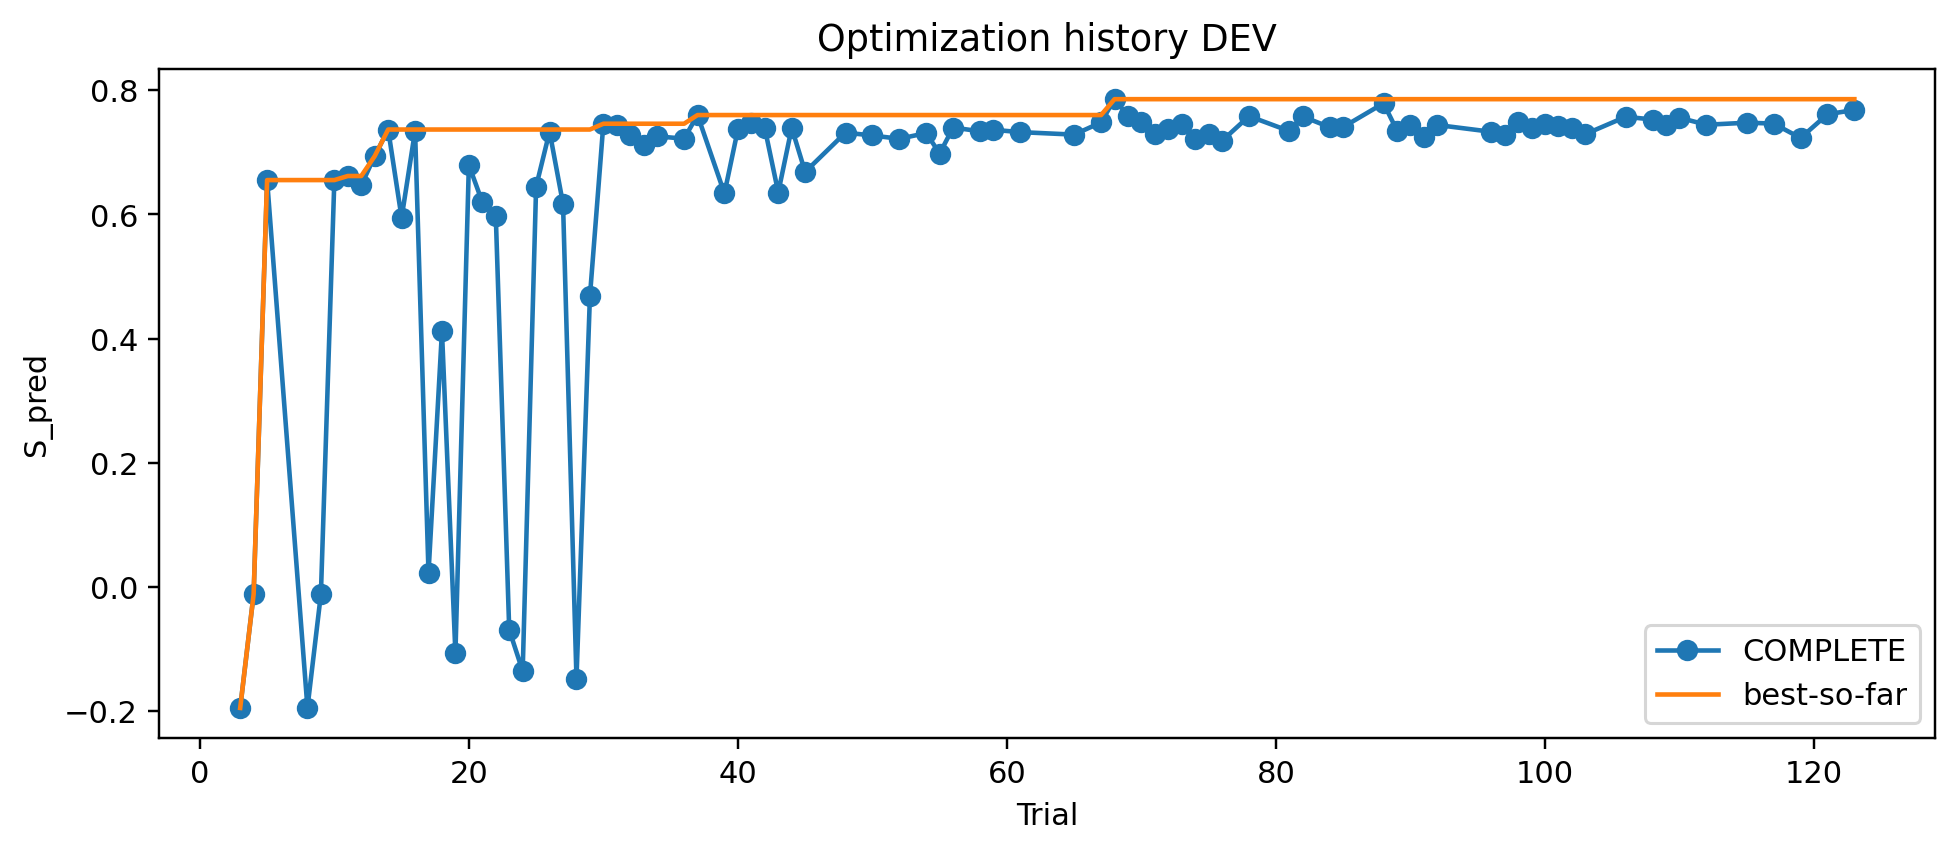

### OPT-02_adaptive_convergence

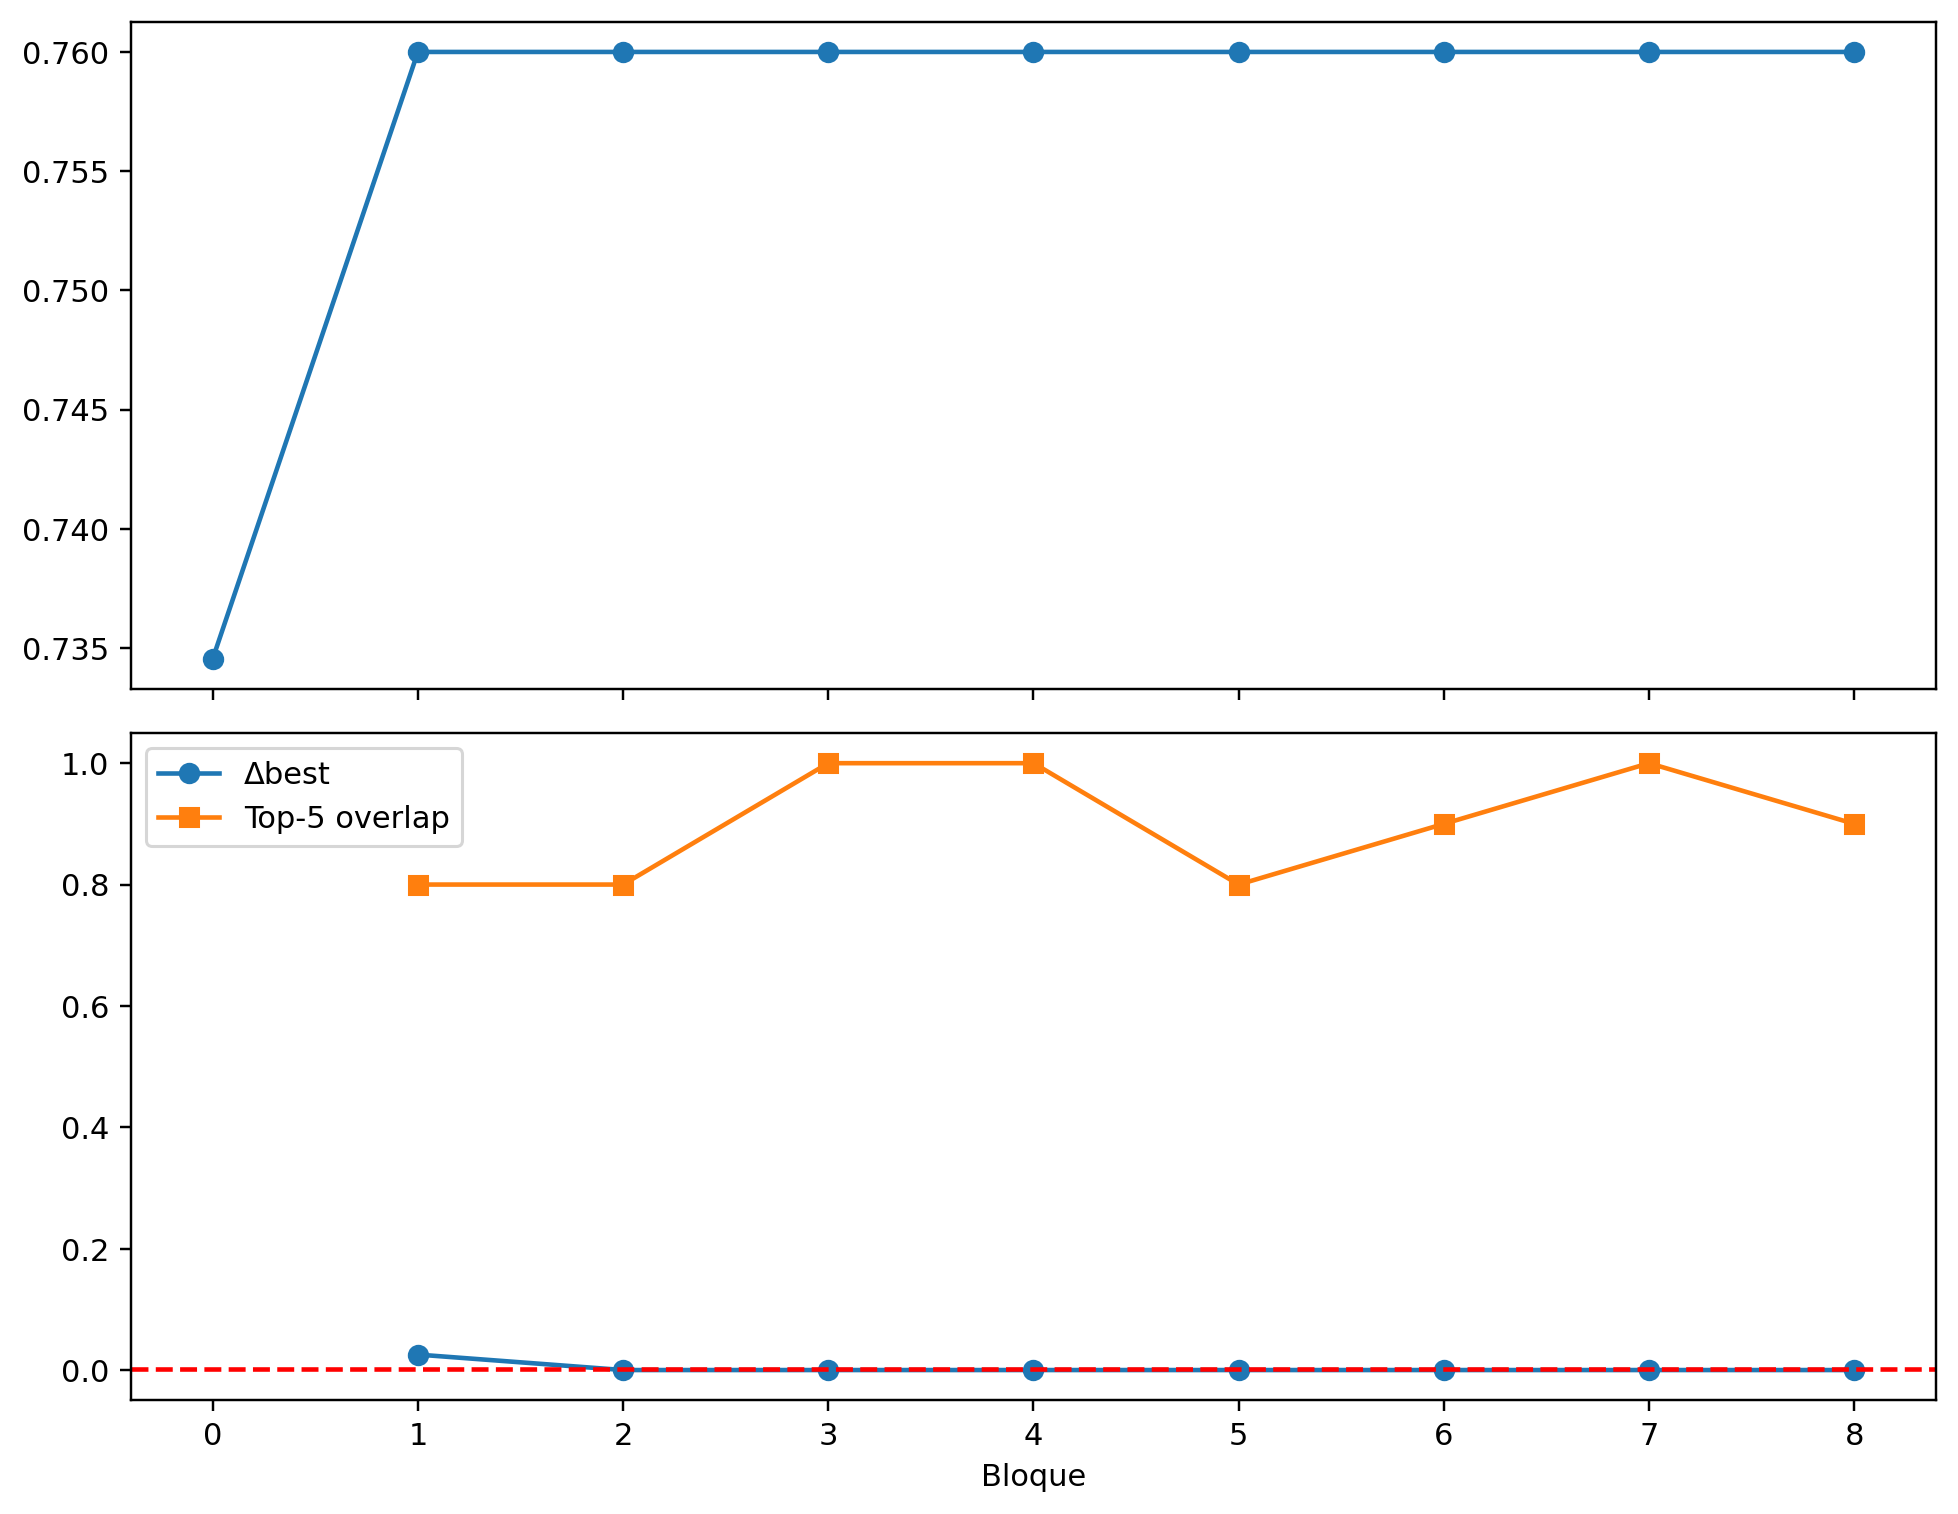

### OPT-03_hyperparameter_importance

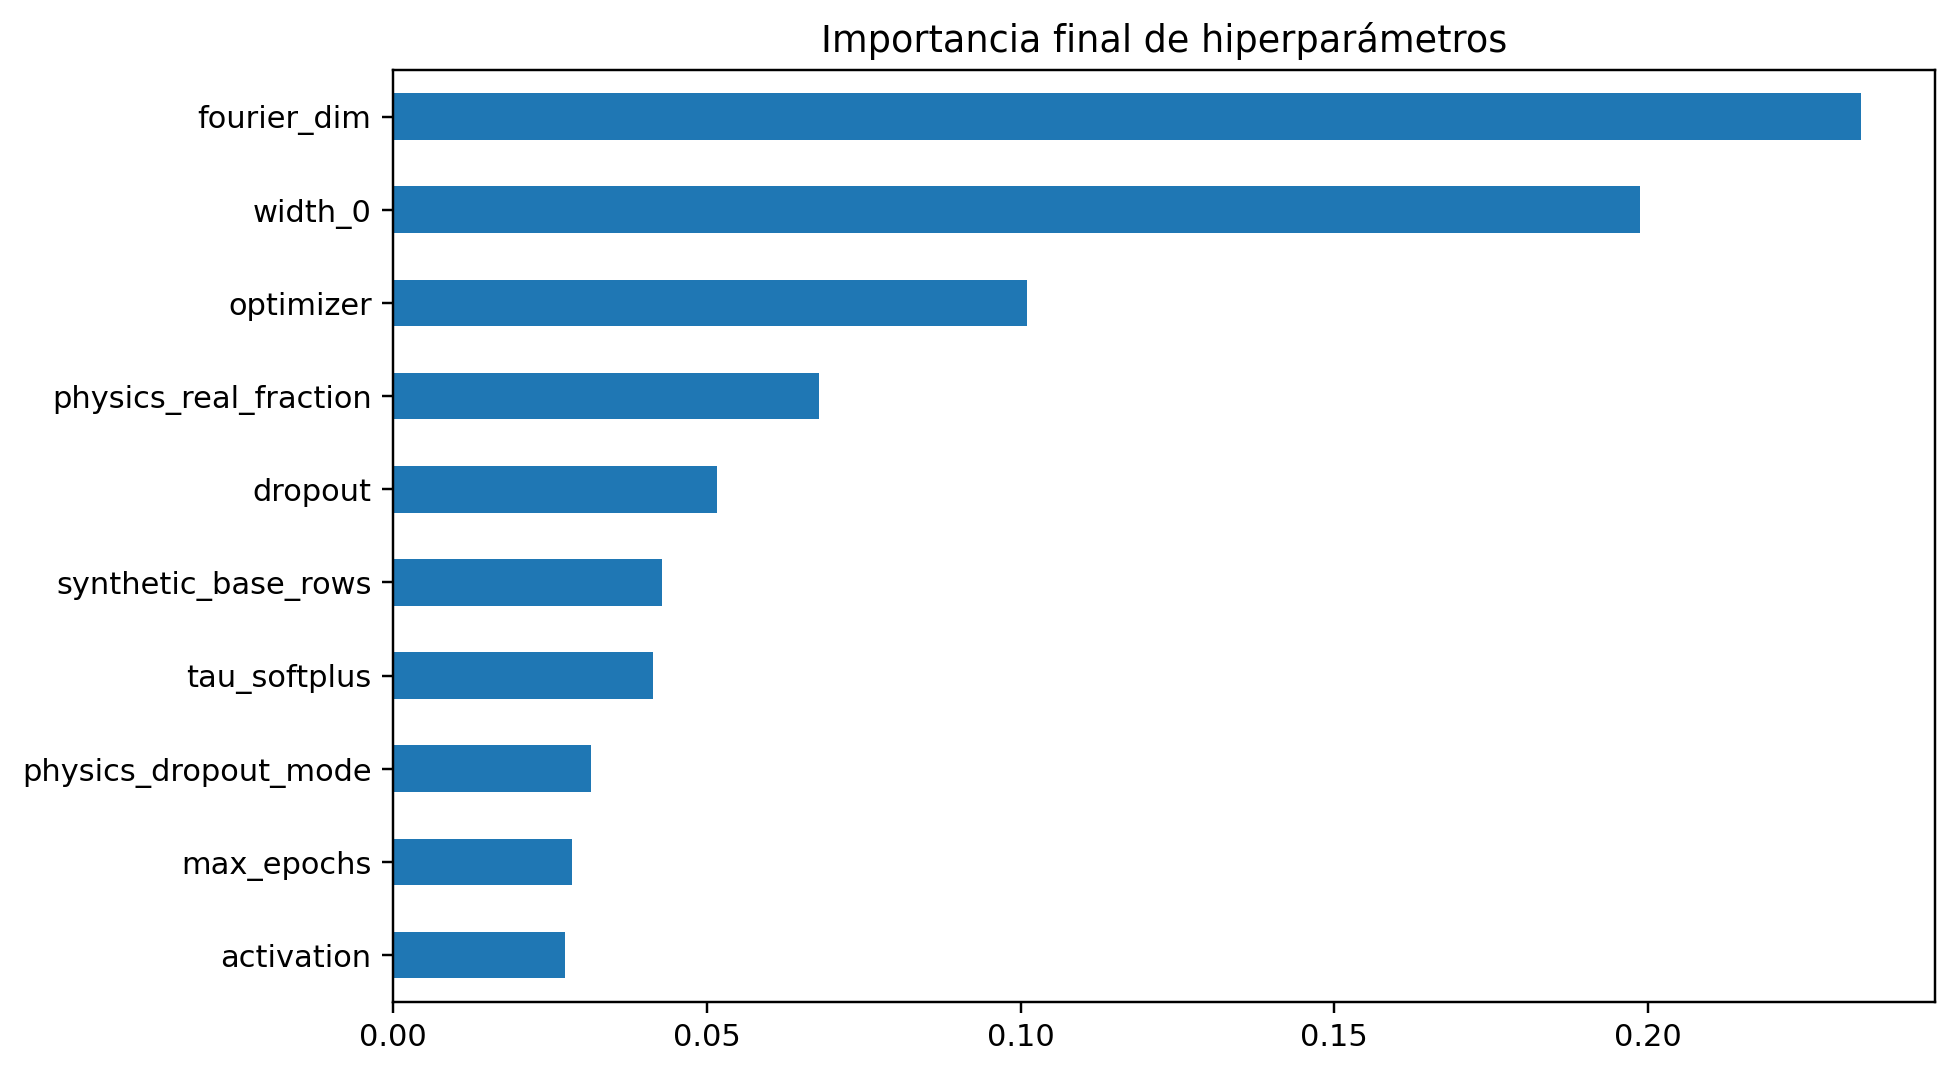

### OPT-04_pruning_status_efficiency

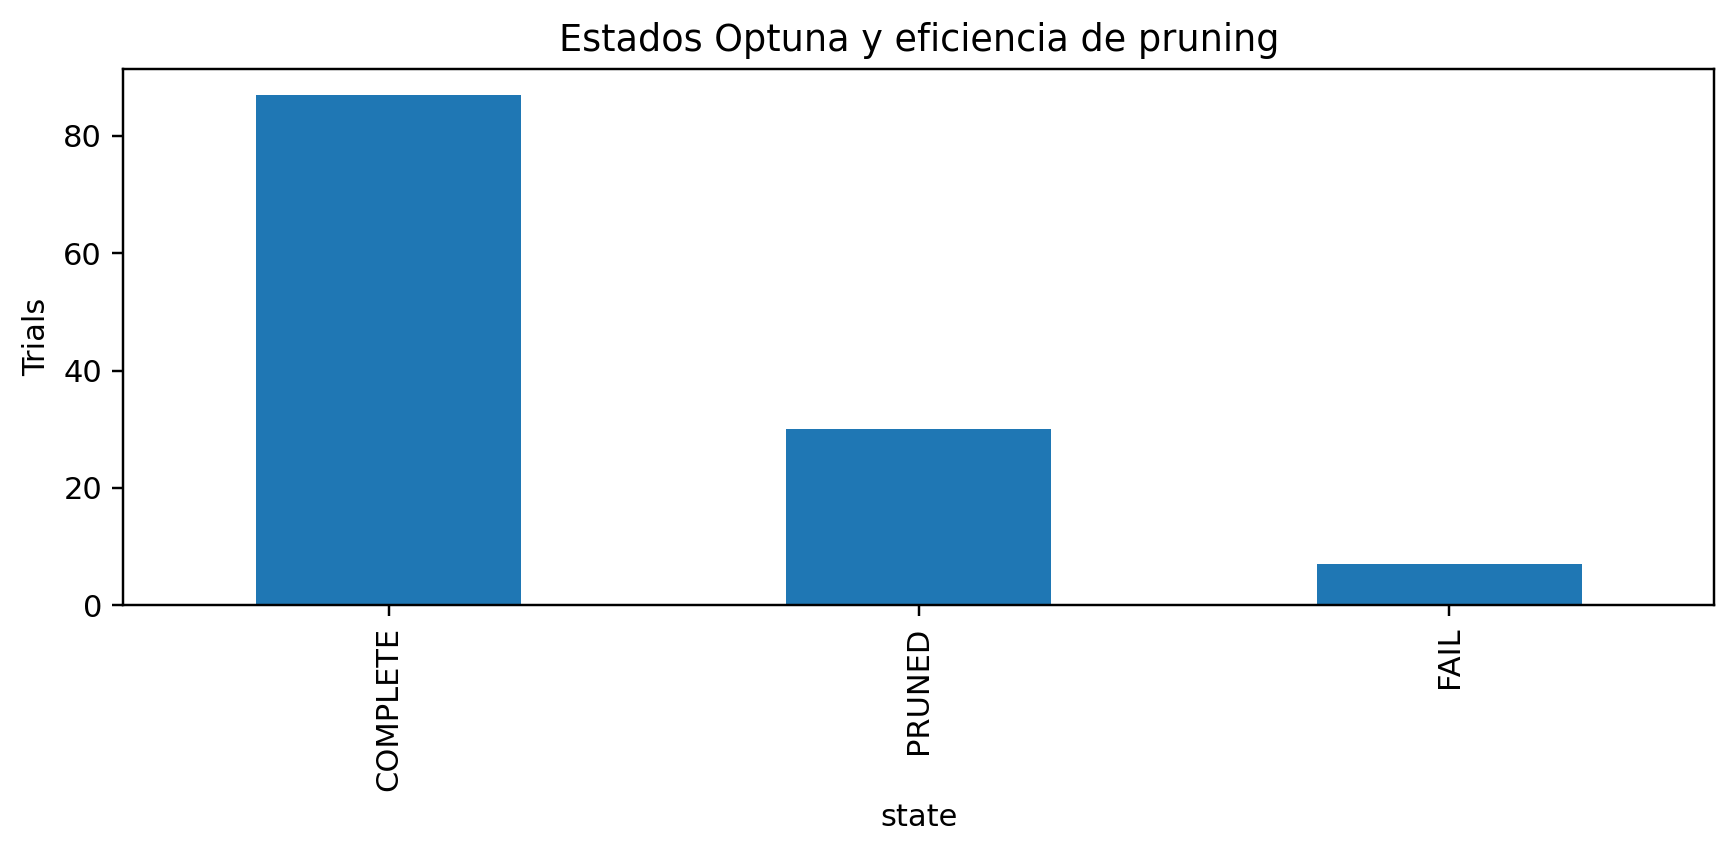

### OPT-05_top10_multiseed_R2

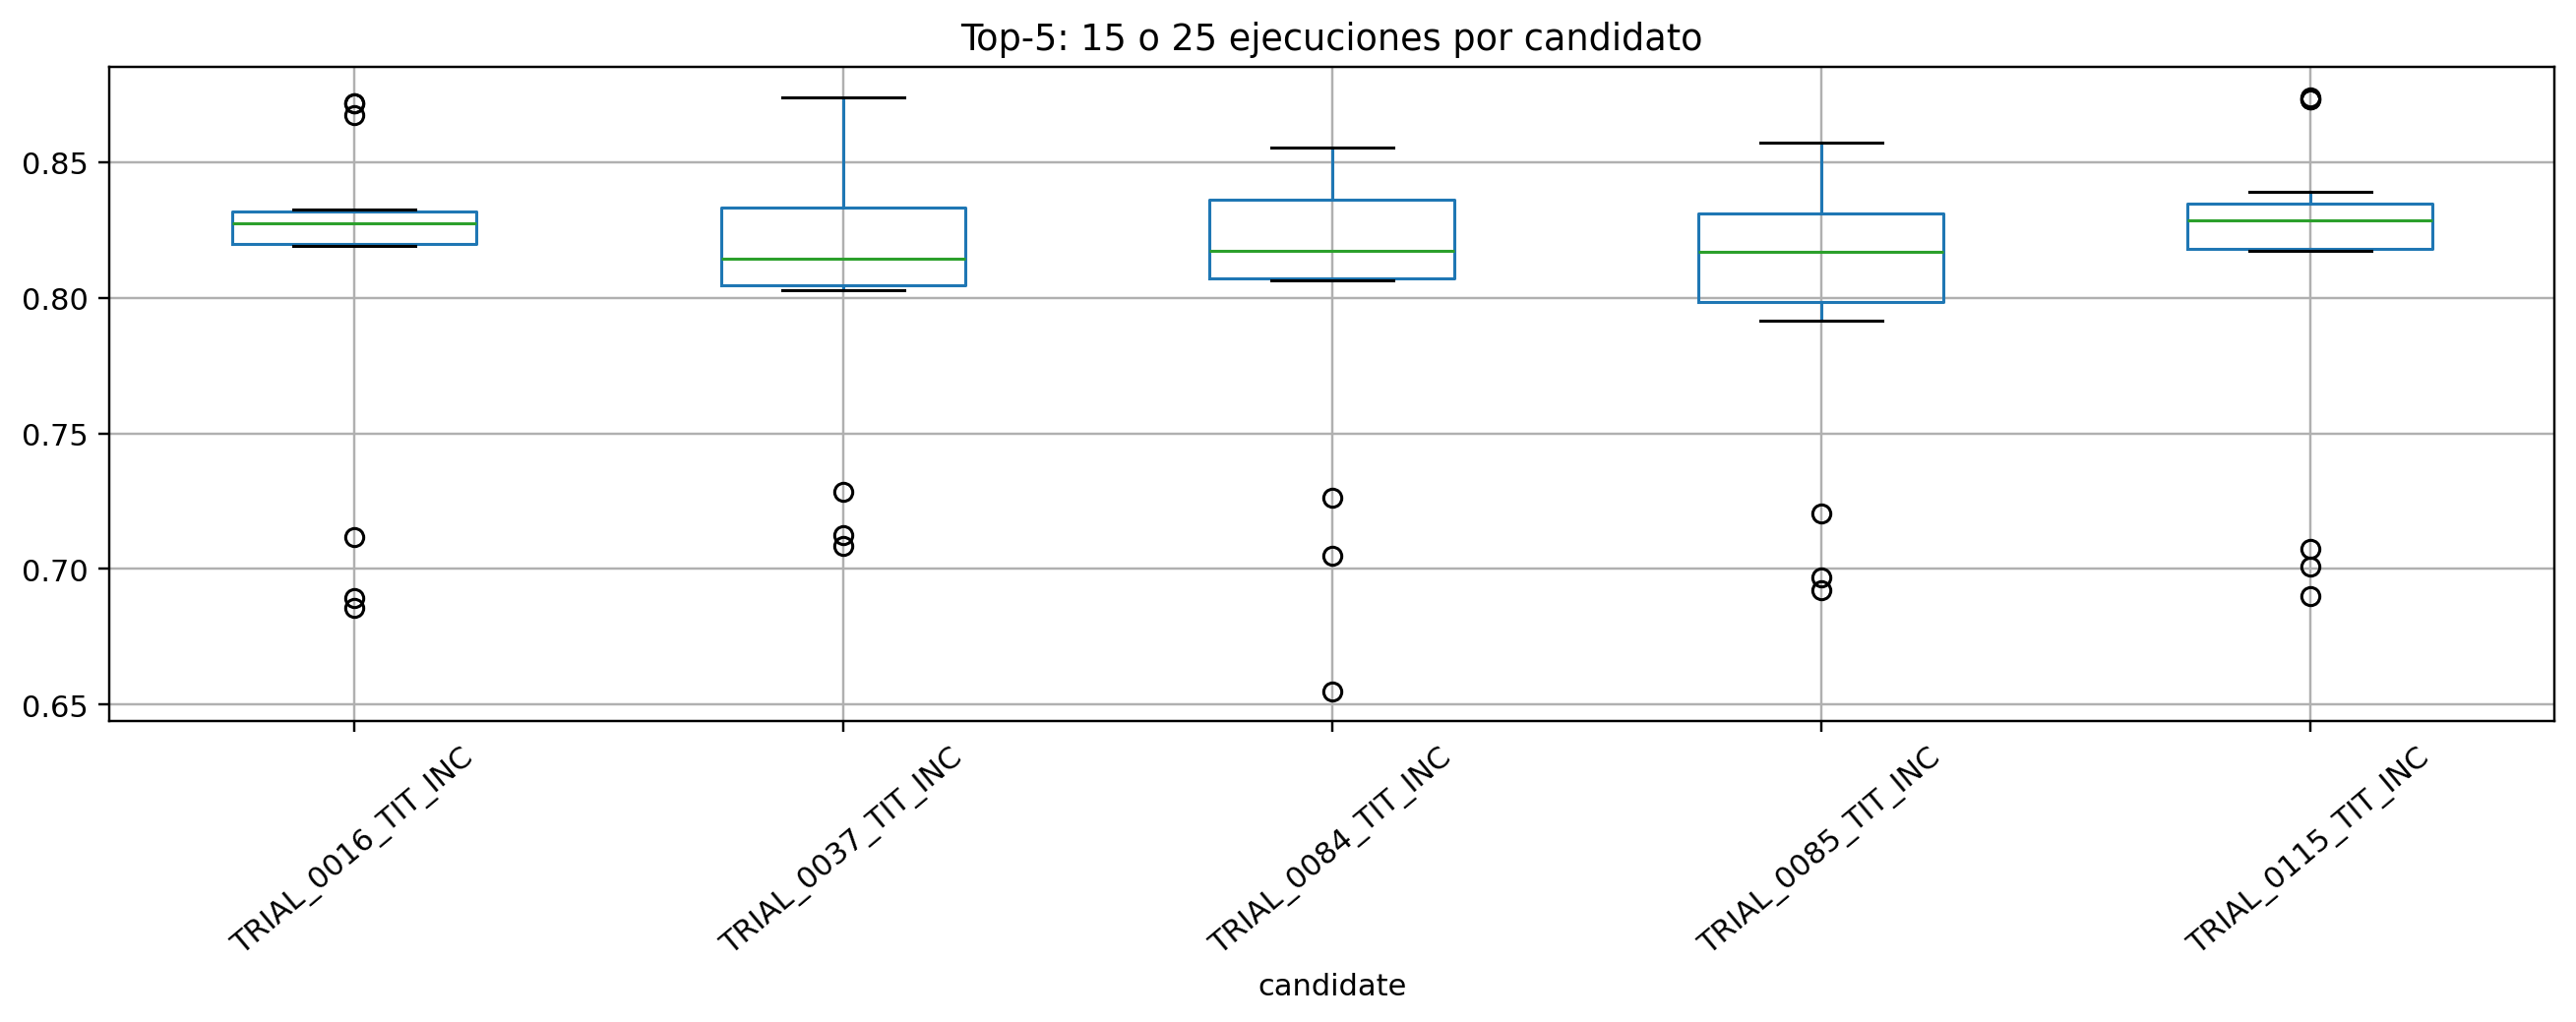

### OPT-06_precision_vs_PCD

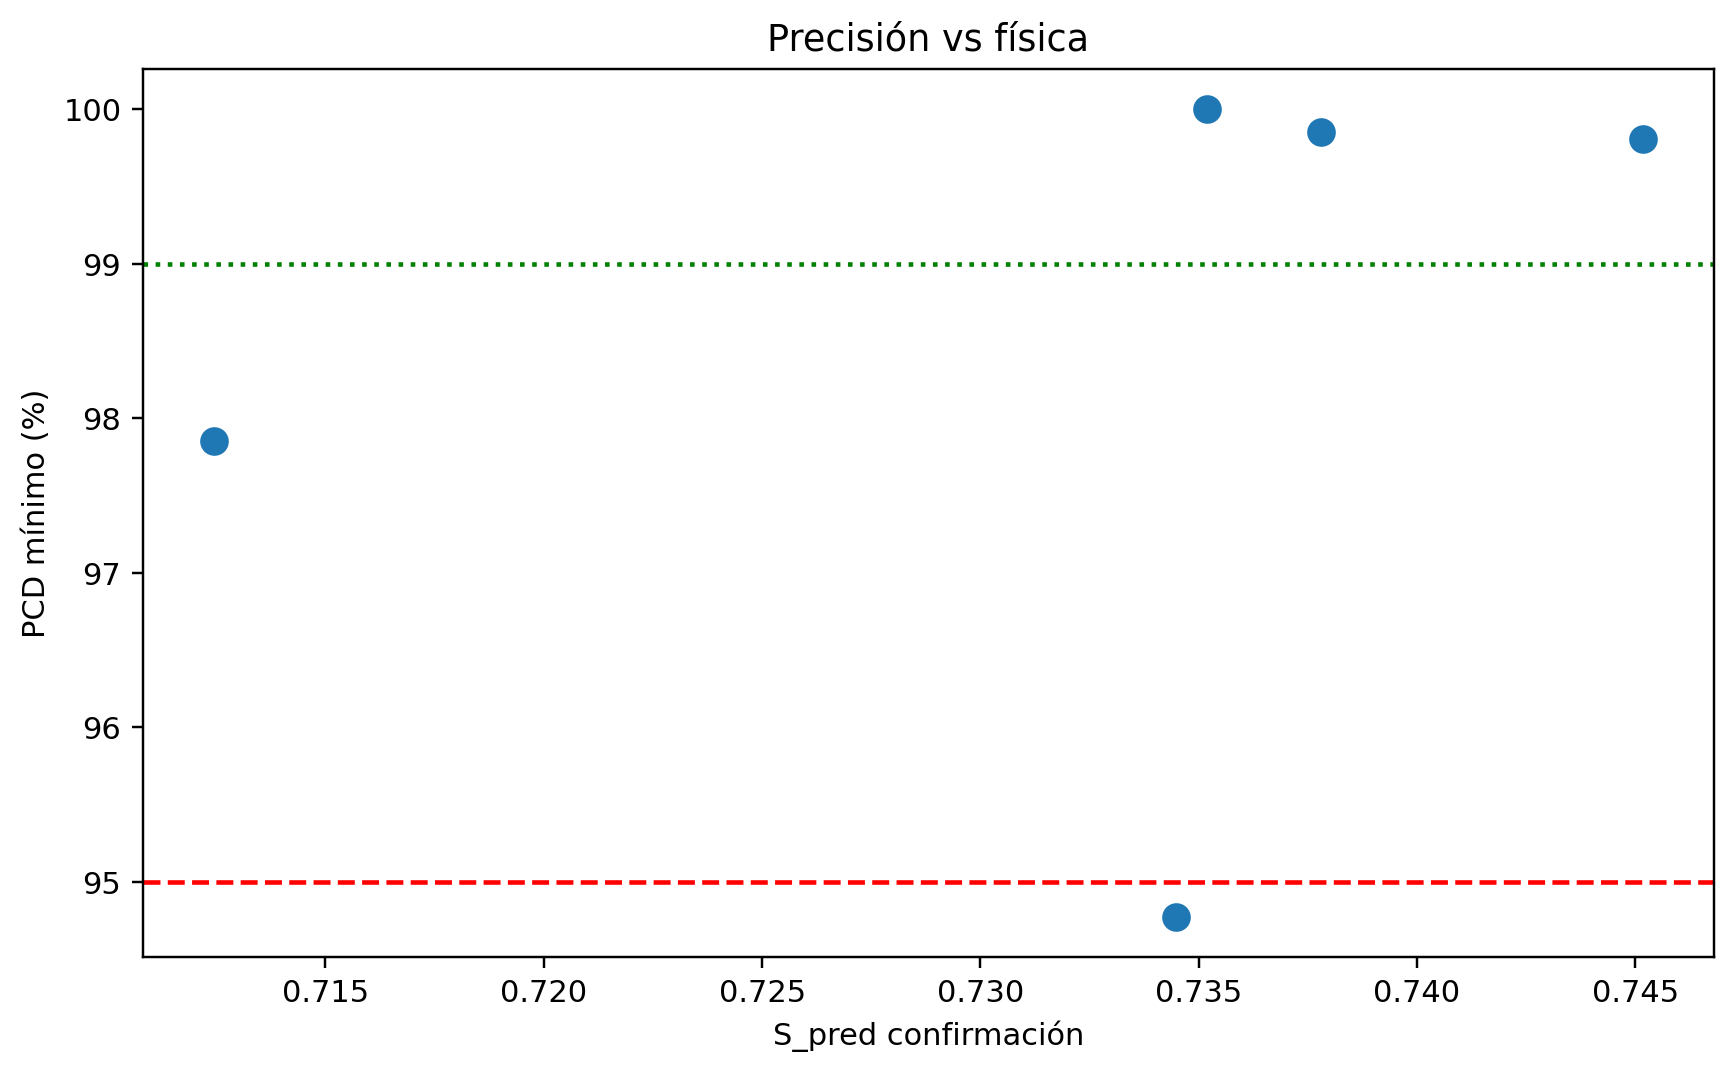

### OPT-07_lbfgs_paired

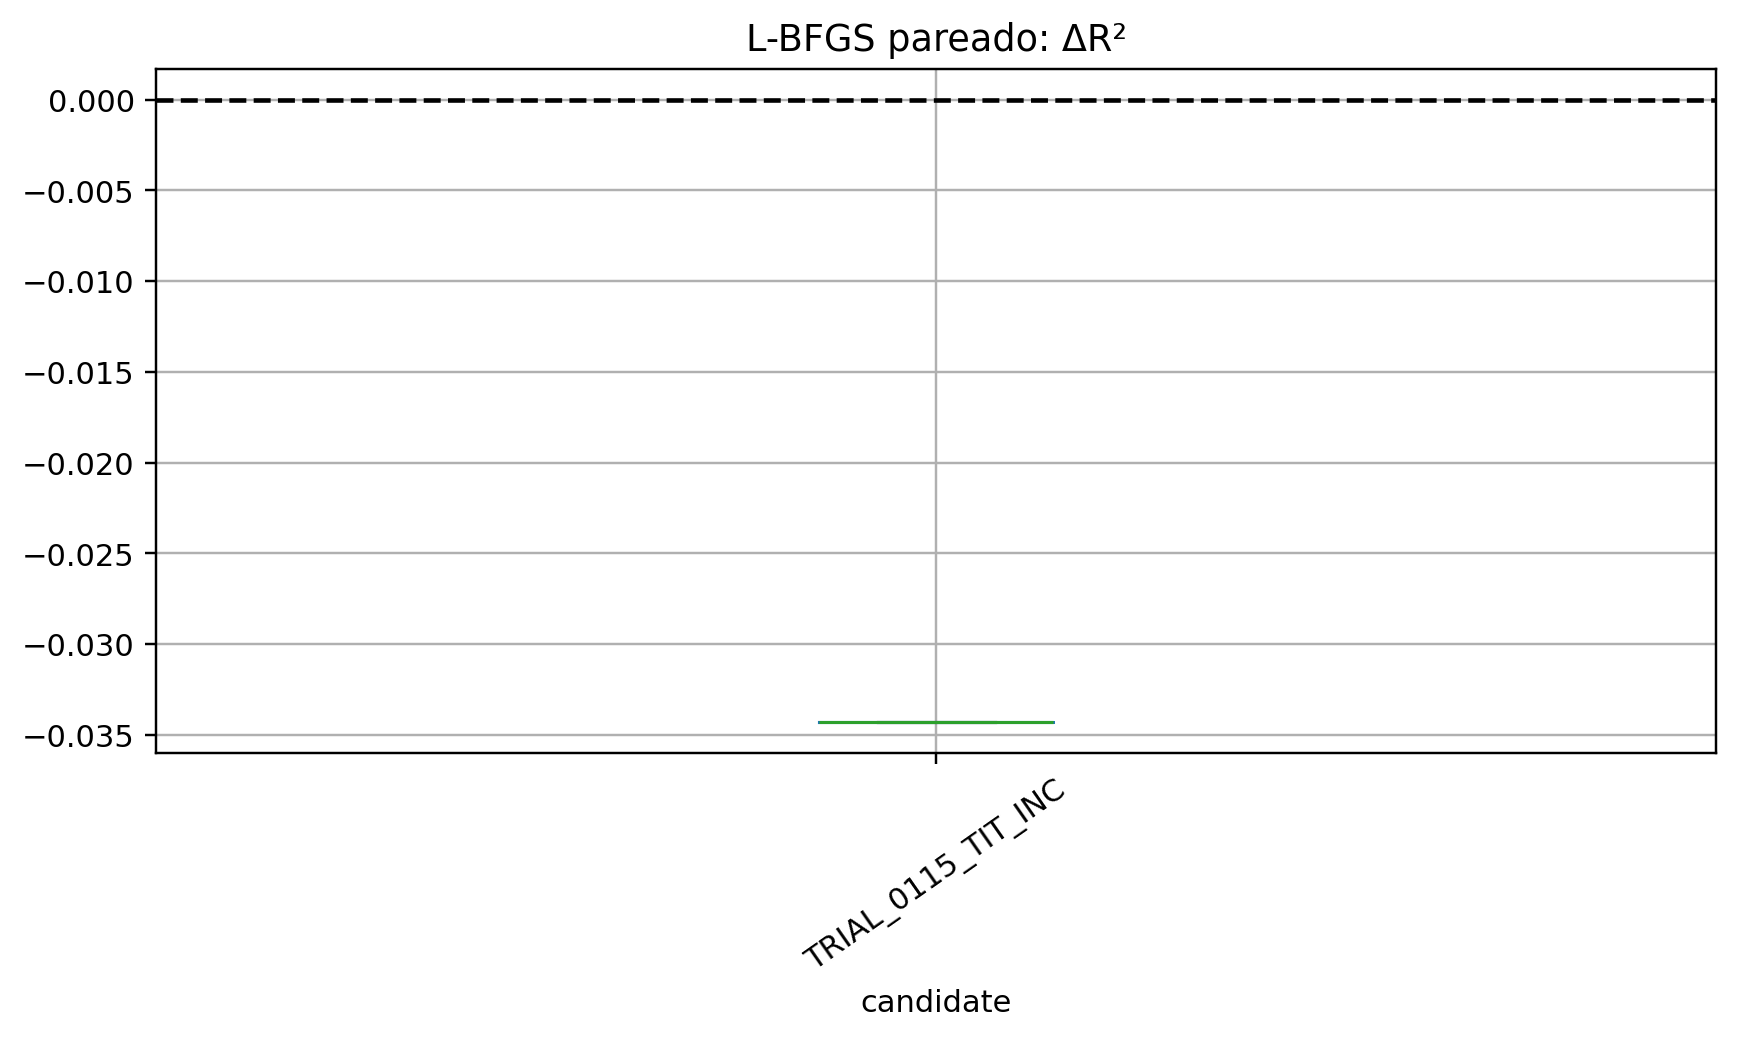

### OPT-08_matched_ablation

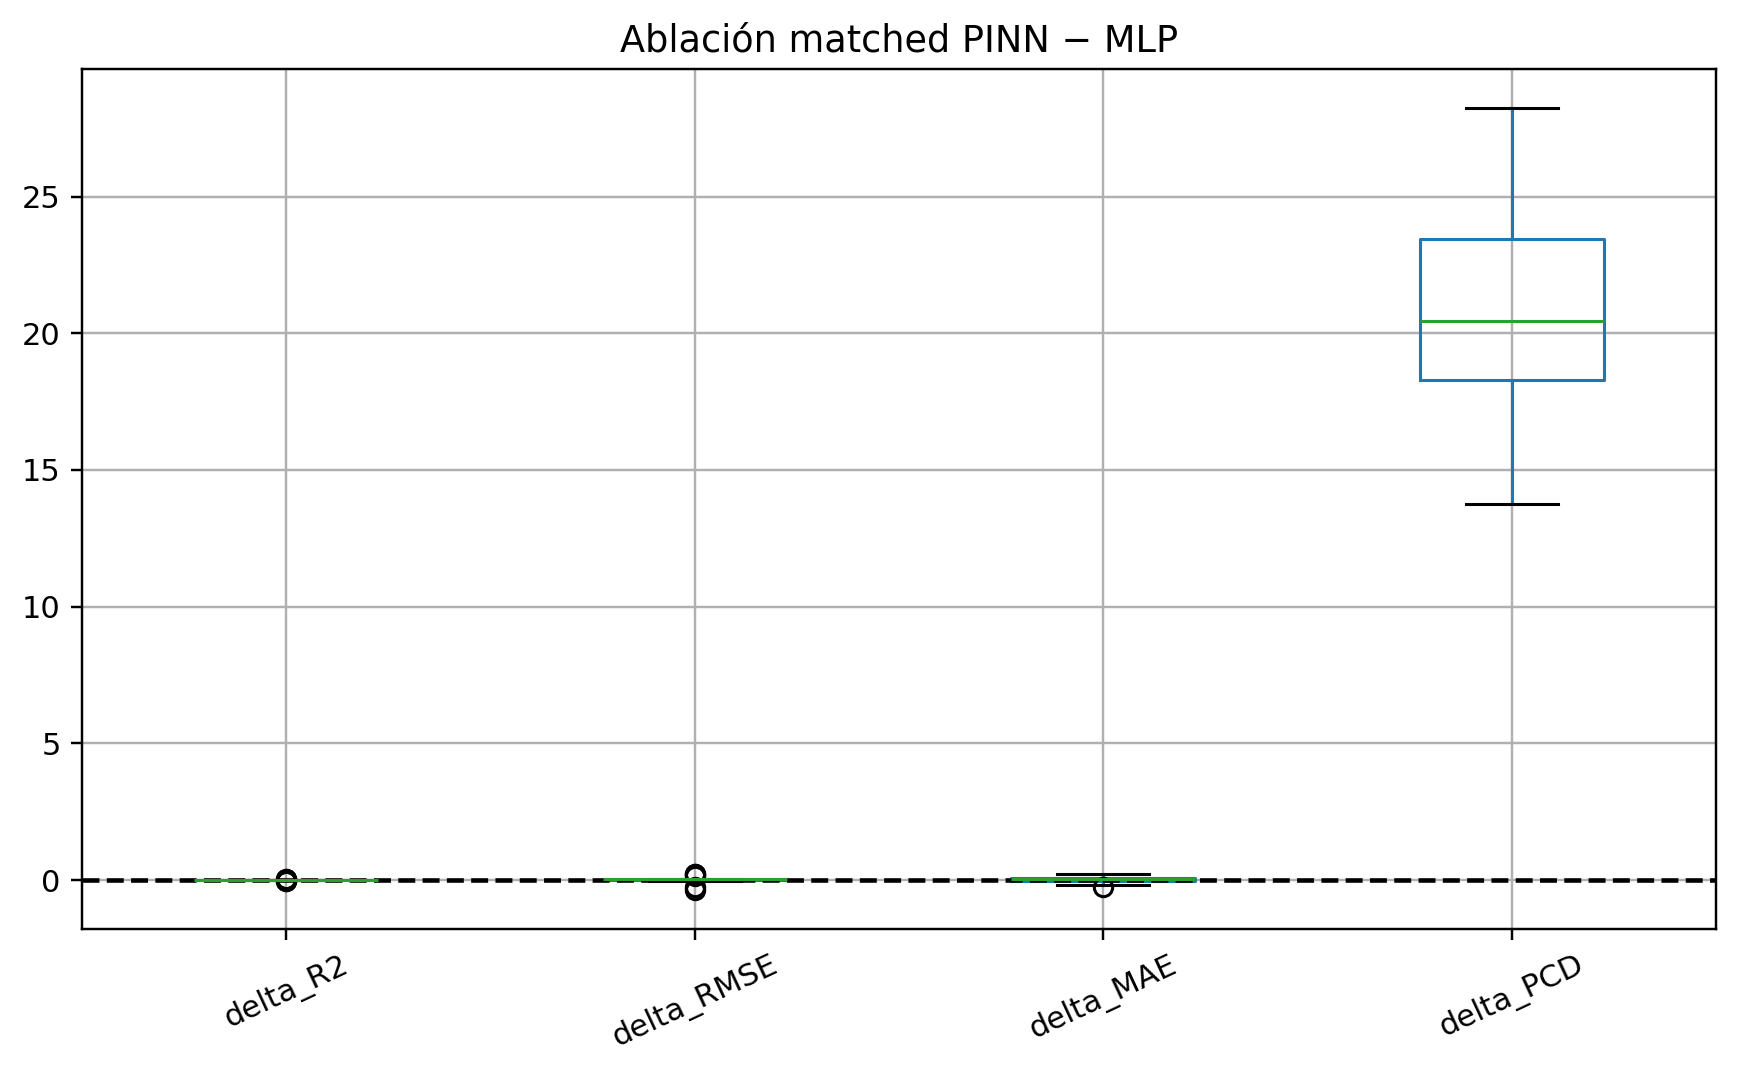

### OPT-09_precision_vs_parameters

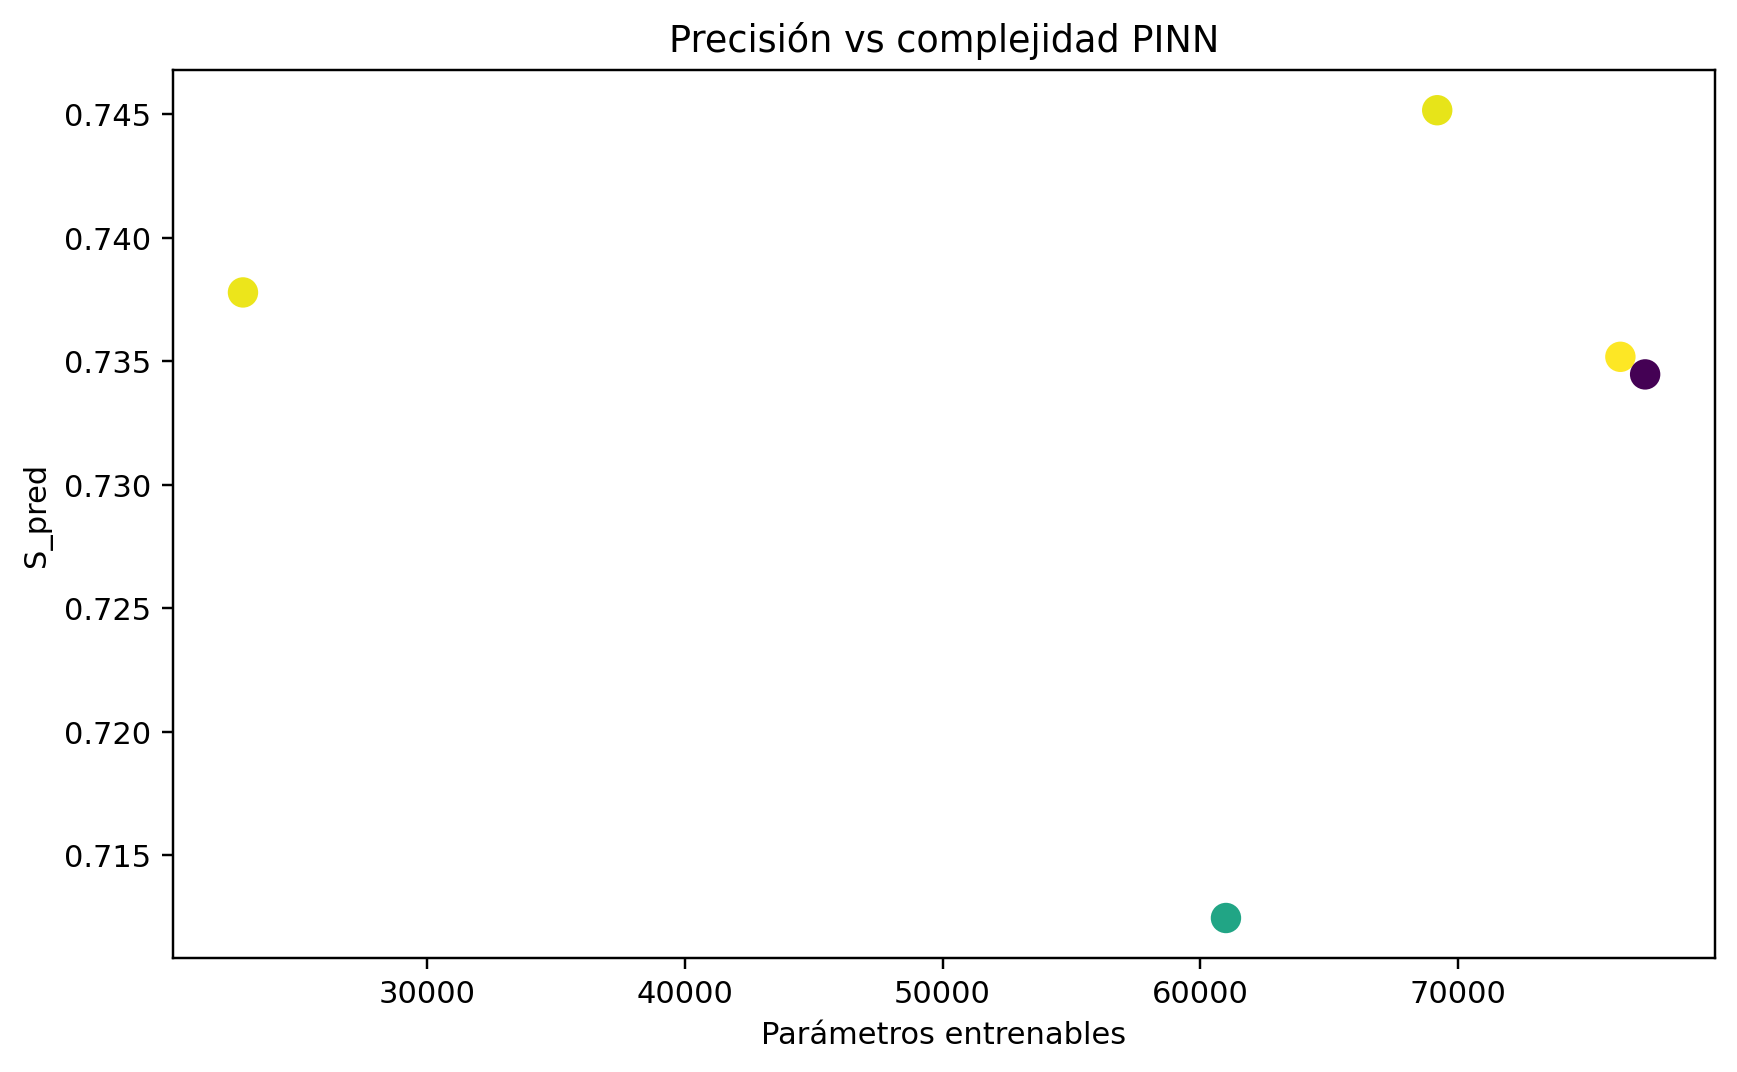

In [57]:
# [POST-RUN VIEW] Figuras incrustadas de la campaña completada
from pathlib import Path
from IPython.display import Image, Markdown, display

figure_dir = Path(r"C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_nox_interp_opt_r6\figures")
for figure_path in sorted(figure_dir.glob("OPT-*.png")):
    display(Markdown(f"### {figure_path.stem}"))
    display(Image(filename=str(figure_path)))